In [24]:
import re
from glob import glob
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import os
from glob import glob
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D


sys.path.insert(0, "/scratch/elena/9Li/scripts")

import geometry_wcte
import functions_multilateration

# -----------------------------------------
# Plot style
# -----------------------------------------

rcParams["mathtext.fontset"] = "stix"
rcParams["font.family"] = "STIXGeneral"

rcParams["figure.figsize"] = [16, 6]

rcParams["font.size"] = 22
rcParams["axes.labelsize"] = 20
rcParams["axes.titlesize"] = 20
rcParams["legend.fontsize"] = 16
rcParams["xtick.labelsize"] = 12
rcParams["ytick.labelsize"] = 16


# ==============================================================================
# Choose run
# ==============================================================================

run_number = 1848
processed_folder = f"/scratch/elena/9Li/results/run{run_number}/processed"

print(f"Run {run_number}")
print(f"Folder: {processed_folder}")

# ==============================================================================
# Read all pickle files
# ==============================================================================

all_files = sorted(glob(f"{processed_folder}/*.pkl"))

# ==============================================================================
# Helper function
# ==============================================================================

def load_dataframe(file_list, label):

    if len(file_list) == 0:
        print(f"{label:<15}:   0 files")
        return pd.DataFrame()

    df = pd.concat(
        [pd.read_pickle(f) for f in file_list],
        ignore_index=True
    )

    print(f"{label:<15}: {len(file_list):2d} files   ({len(df):8,d} clusters)")

    return df


# ==============================================================================
# STAGE 1
# Sliding windows
# ==============================================================================

stage1_sig_files = sorted([
    f for f in all_files
    if "Li9_clusters_chunk_" in f
    and "_multilat" not in f
    and "Refine_" not in f
    and "Final_FV_" not in f
    and "_BKG" not in f
])

stage1_bkg_files = sorted([
    f for f in all_files
    if "Li9_clusters_chunk_" in f
    and "_multilat" not in f
    and "Refine_" not in f
    and "Final_FV_" not in f
    and "_BKG" in f
])


# ==============================================================================
# STAGE 2
# Multilateration
# ==============================================================================

stage2_sig_files = sorted([
    f for f in all_files
    if "_multilat.pkl" in f
    and "_BKG" not in f
])

stage2_bkg_files = sorted([
    f for f in all_files
    if "_BKG_multilat.pkl" in f
])


# ==============================================================================
# STAGE 4
# Refinement
# ==============================================================================

stage4_sig_files = sorted([
    f for f in all_files
    if "Refine_Li9_clusters" in f
    and "_BKG" not in f
])

stage4_bkg_files = sorted([
    f for f in all_files
    if "Refine_Li9_clusters" in f
    and "_BKG" in f
])


# ==============================================================================
# STAGE 5
# Final FV
# ==============================================================================

# Definimos la ruta específica a la subcarpeta FV_1
stage5_folder = os.path.join(processed_folder, "FV_1")
stage5_files = sorted(glob(f"{stage5_folder}/*.pkl"))

stage5_sig_files = sorted([
    f for f in stage5_files
    if "Final_FV_" in f
    and "_BKG" not in f
])

stage5_bkg_files = sorted([
    f for f in stage5_files
    if "Final_FV_" in f
    and "_BKG" in f
])


# ==============================================================================
# Load all DataFrames
# ==============================================================================

df_stage1_sig = load_dataframe(stage1_sig_files, "Stage 1 SIG")
df_stage1_bkg = load_dataframe(stage1_bkg_files, "Stage 1 BKG")

df_stage2_sig = load_dataframe(stage2_sig_files, "Stage 2 SIG")
df_stage2_bkg = load_dataframe(stage2_bkg_files, "Stage 2 BKG")

df_stage4_sig = load_dataframe(stage4_sig_files, "Stage 4 SIG")
df_stage4_bkg = load_dataframe(stage4_bkg_files, "Stage 4 BKG")

df_stage5_sig = load_dataframe(stage5_sig_files, "Stage 5 SIG")
df_stage5_bkg = load_dataframe(stage5_bkg_files, "Stage 5 BKG")

print(f"\nAll DataFrames loaded successfully for run{run_number}")

Run 1848
Folder: /scratch/elena/9Li/results/run1848/processed
Stage 1 SIG    : 31 files   ( 171,894 clusters)
Stage 1 BKG    : 16 files   (  86,449 clusters)
Stage 2 SIG    : 31 files   ( 171,894 clusters)
Stage 2 BKG    : 16 files   (  86,449 clusters)
Stage 4 SIG    : 31 files   (  49,908 clusters)
Stage 4 BKG    : 16 files   (  25,484 clusters)
Stage 5 SIG    :  1 files   (     555 clusters)
Stage 5 BKG    :  1 files   (     251 clusters)

All DataFrames loaded successfully for run1848


In [25]:
df_stage1_sig.columns

Index(['t_window_start_ns', 't_window_start_rel_ns', 'nHits', 't_rms_ns',
       'spill_id', 'nCLusters_in_spill', 'hit_slot_ids', 'hit_position_ids',
       'hit_times_ns', 'hit_charges'],
      dtype='object')

In [26]:
df_stage2_bkg[["vertex_x","vertex_y","vertex_z"]].describe()

,vertex_x,vertex_y,vertex_z
count,86445.000000,86445.000000,86445.000000
mean,-0.131787,61.143153,-18.901033
std,86.513604,91.241197,93.979279
min,-300.000000,-300.000000,-300.000000
25%,-40.287309,10.028076,-62.786095
50%,0.089785,57.850587,-13.474561
75%,40.699252,112.008468,31.540571
max,300.000000,300.000000,300.000000


Stage 2: Multilateration - Signal: 8622 clusters
Stage 2: Multilateration - Background: 4455 clusters


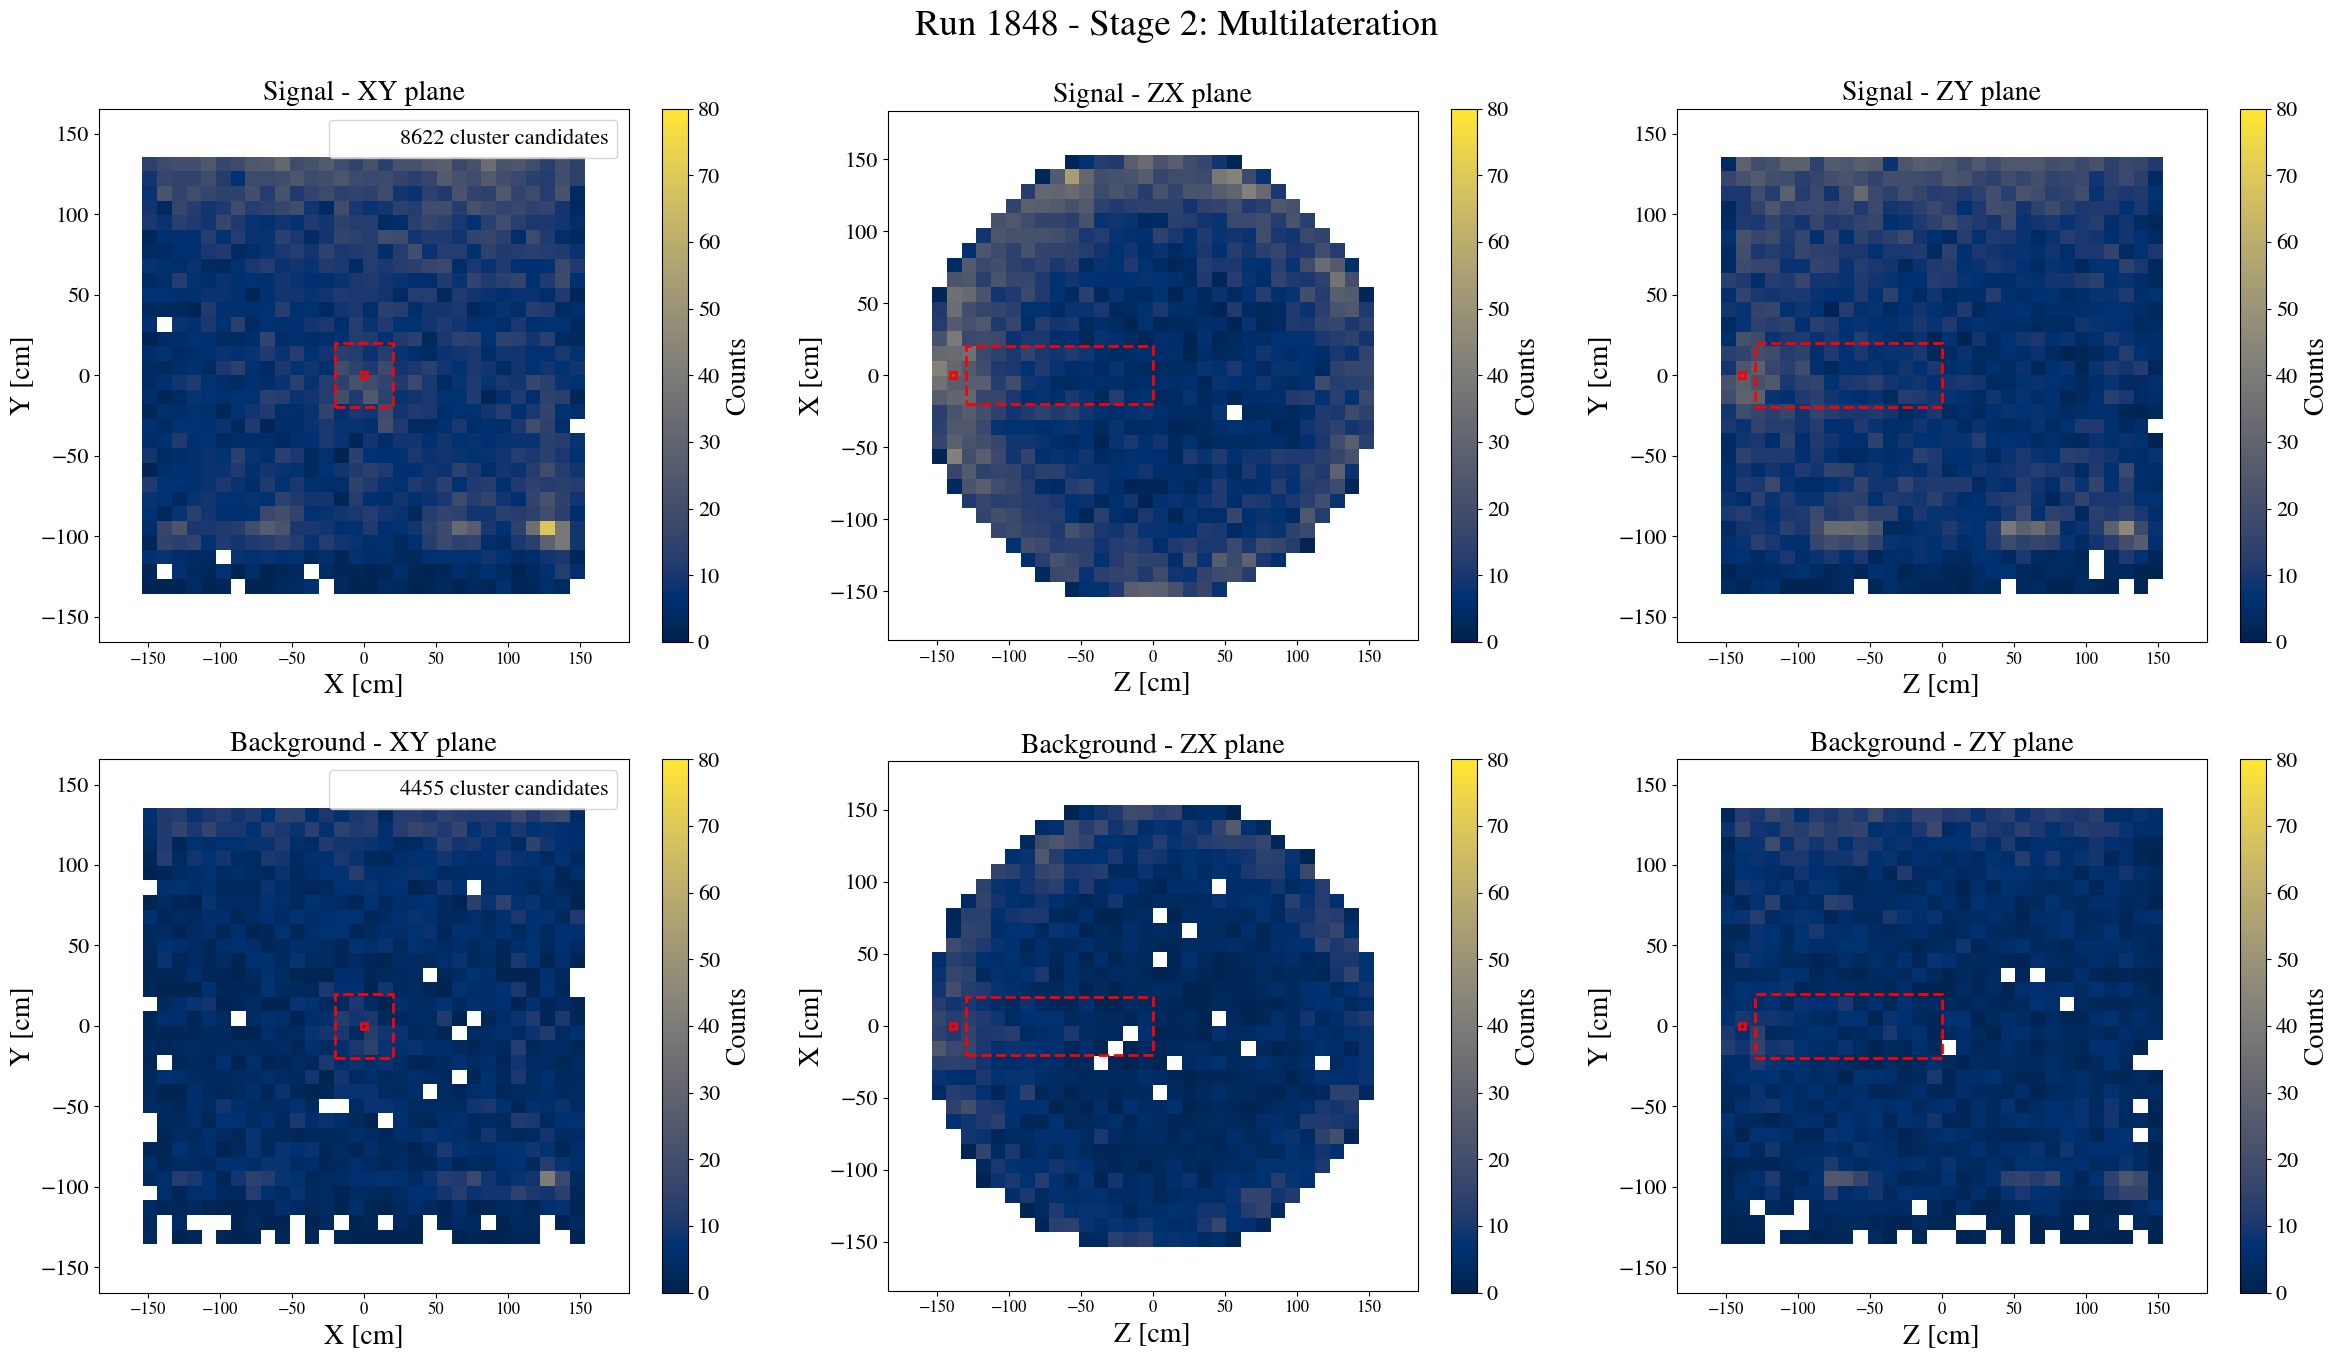

Stage 3: Refinement - Signal: 7923 clusters
Stage 3: Refinement - Background: 4057 clusters


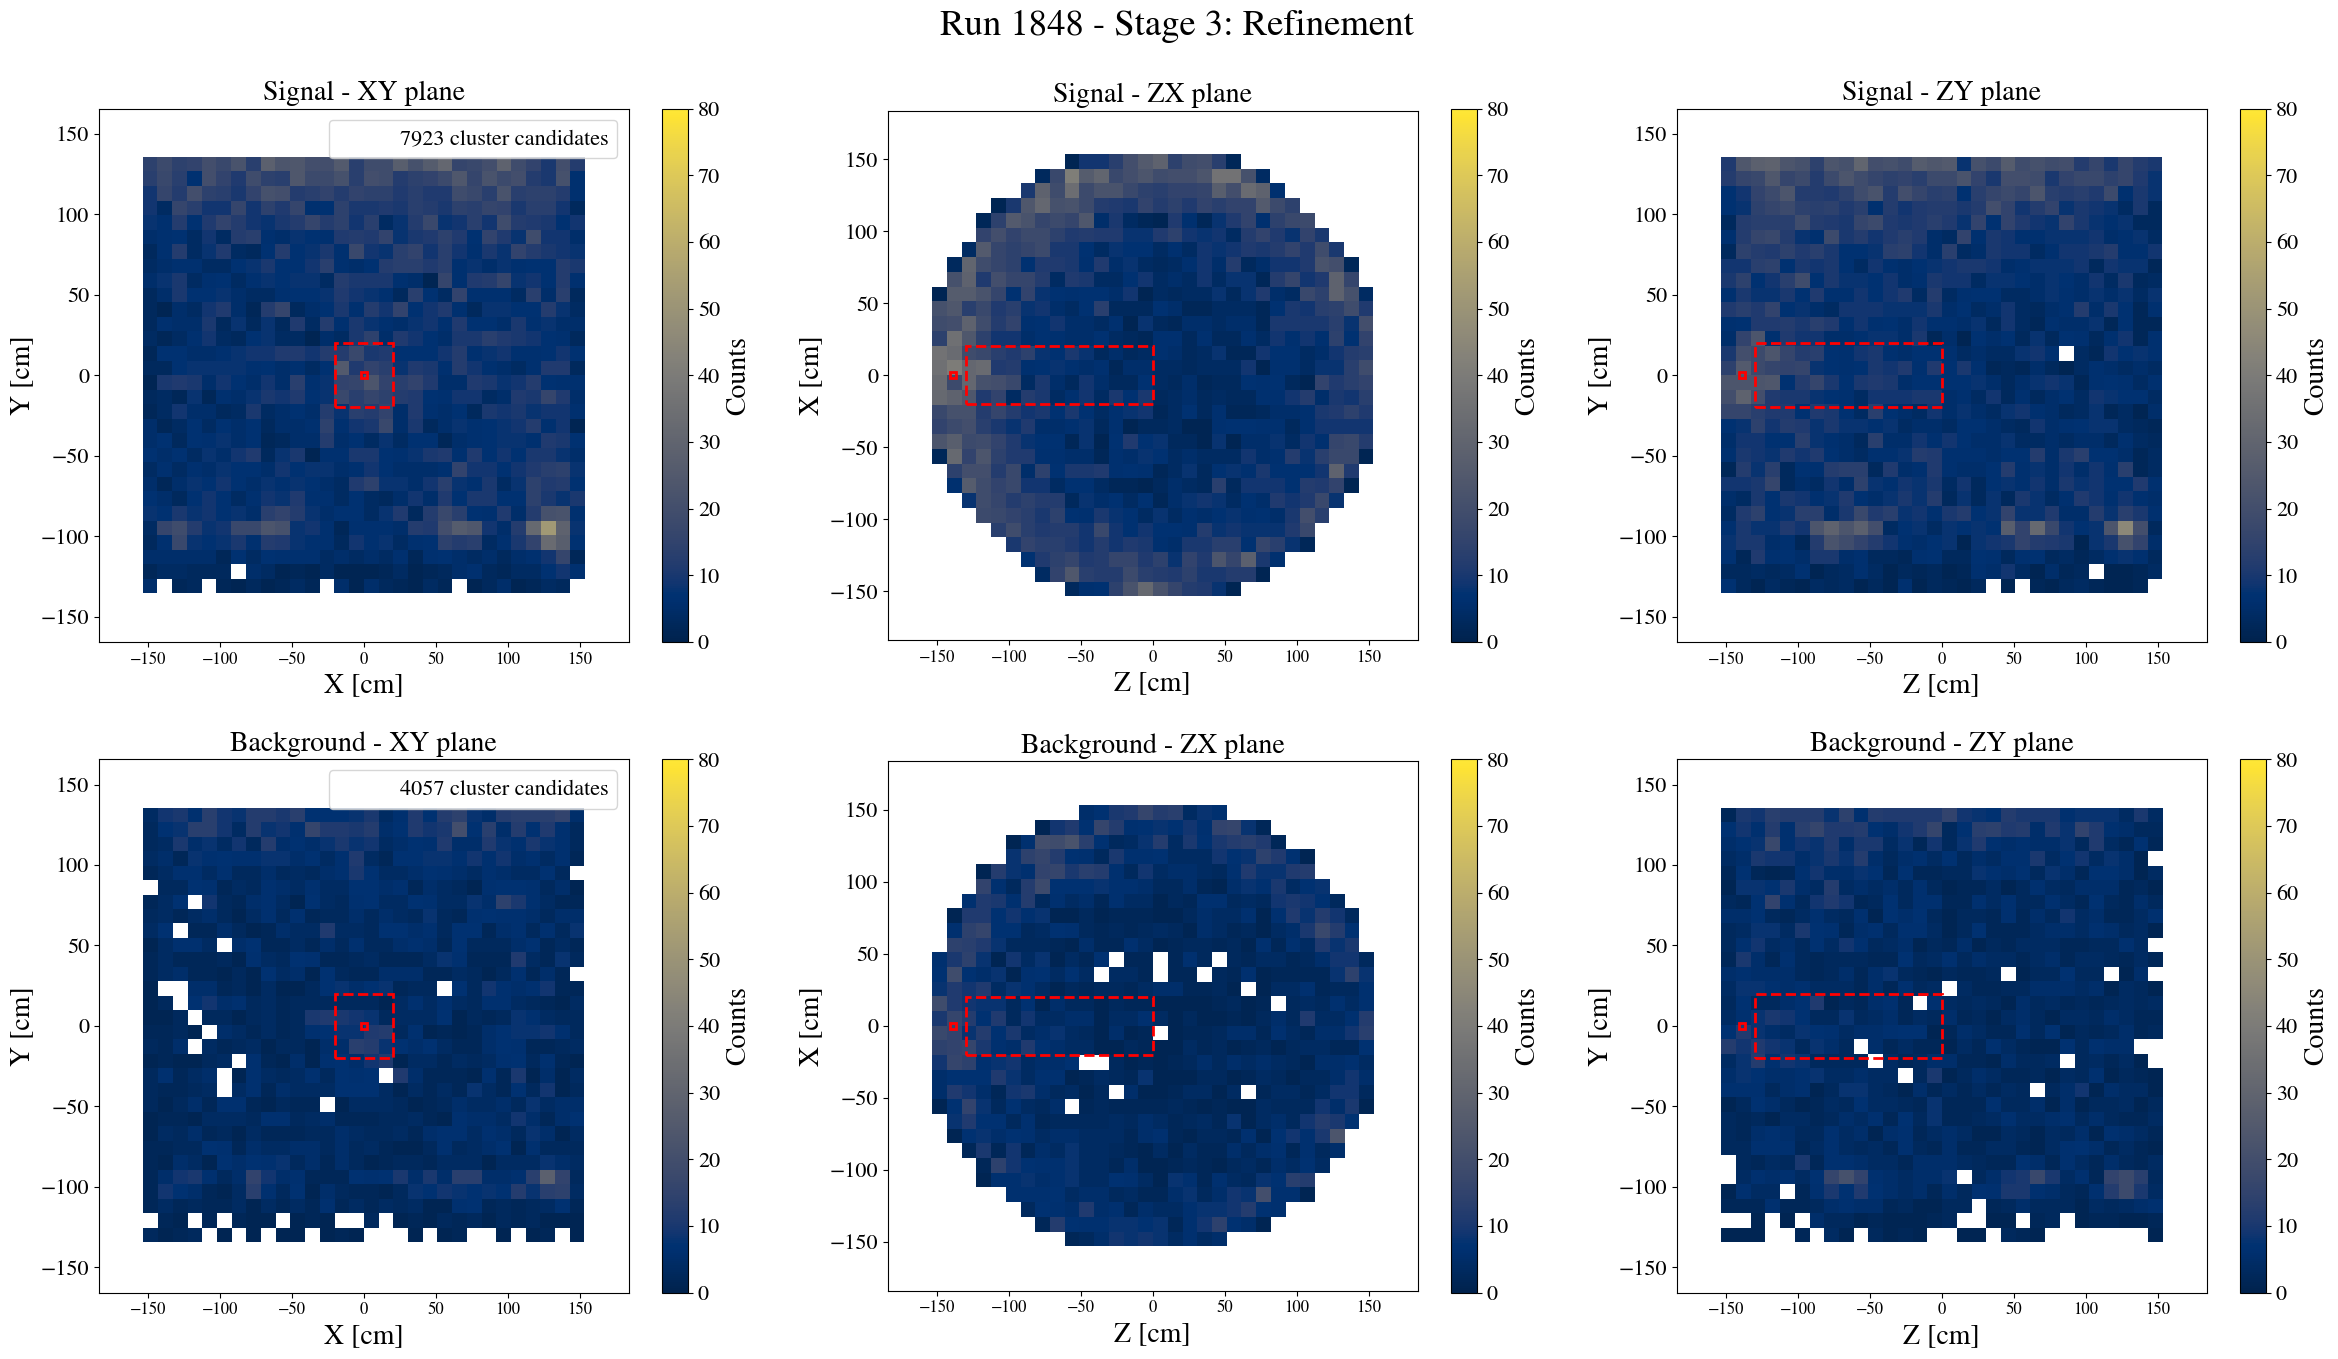

Stage 4: Final FV - Signal: 125 clusters
Stage 4: Final FV - Background: 63 clusters


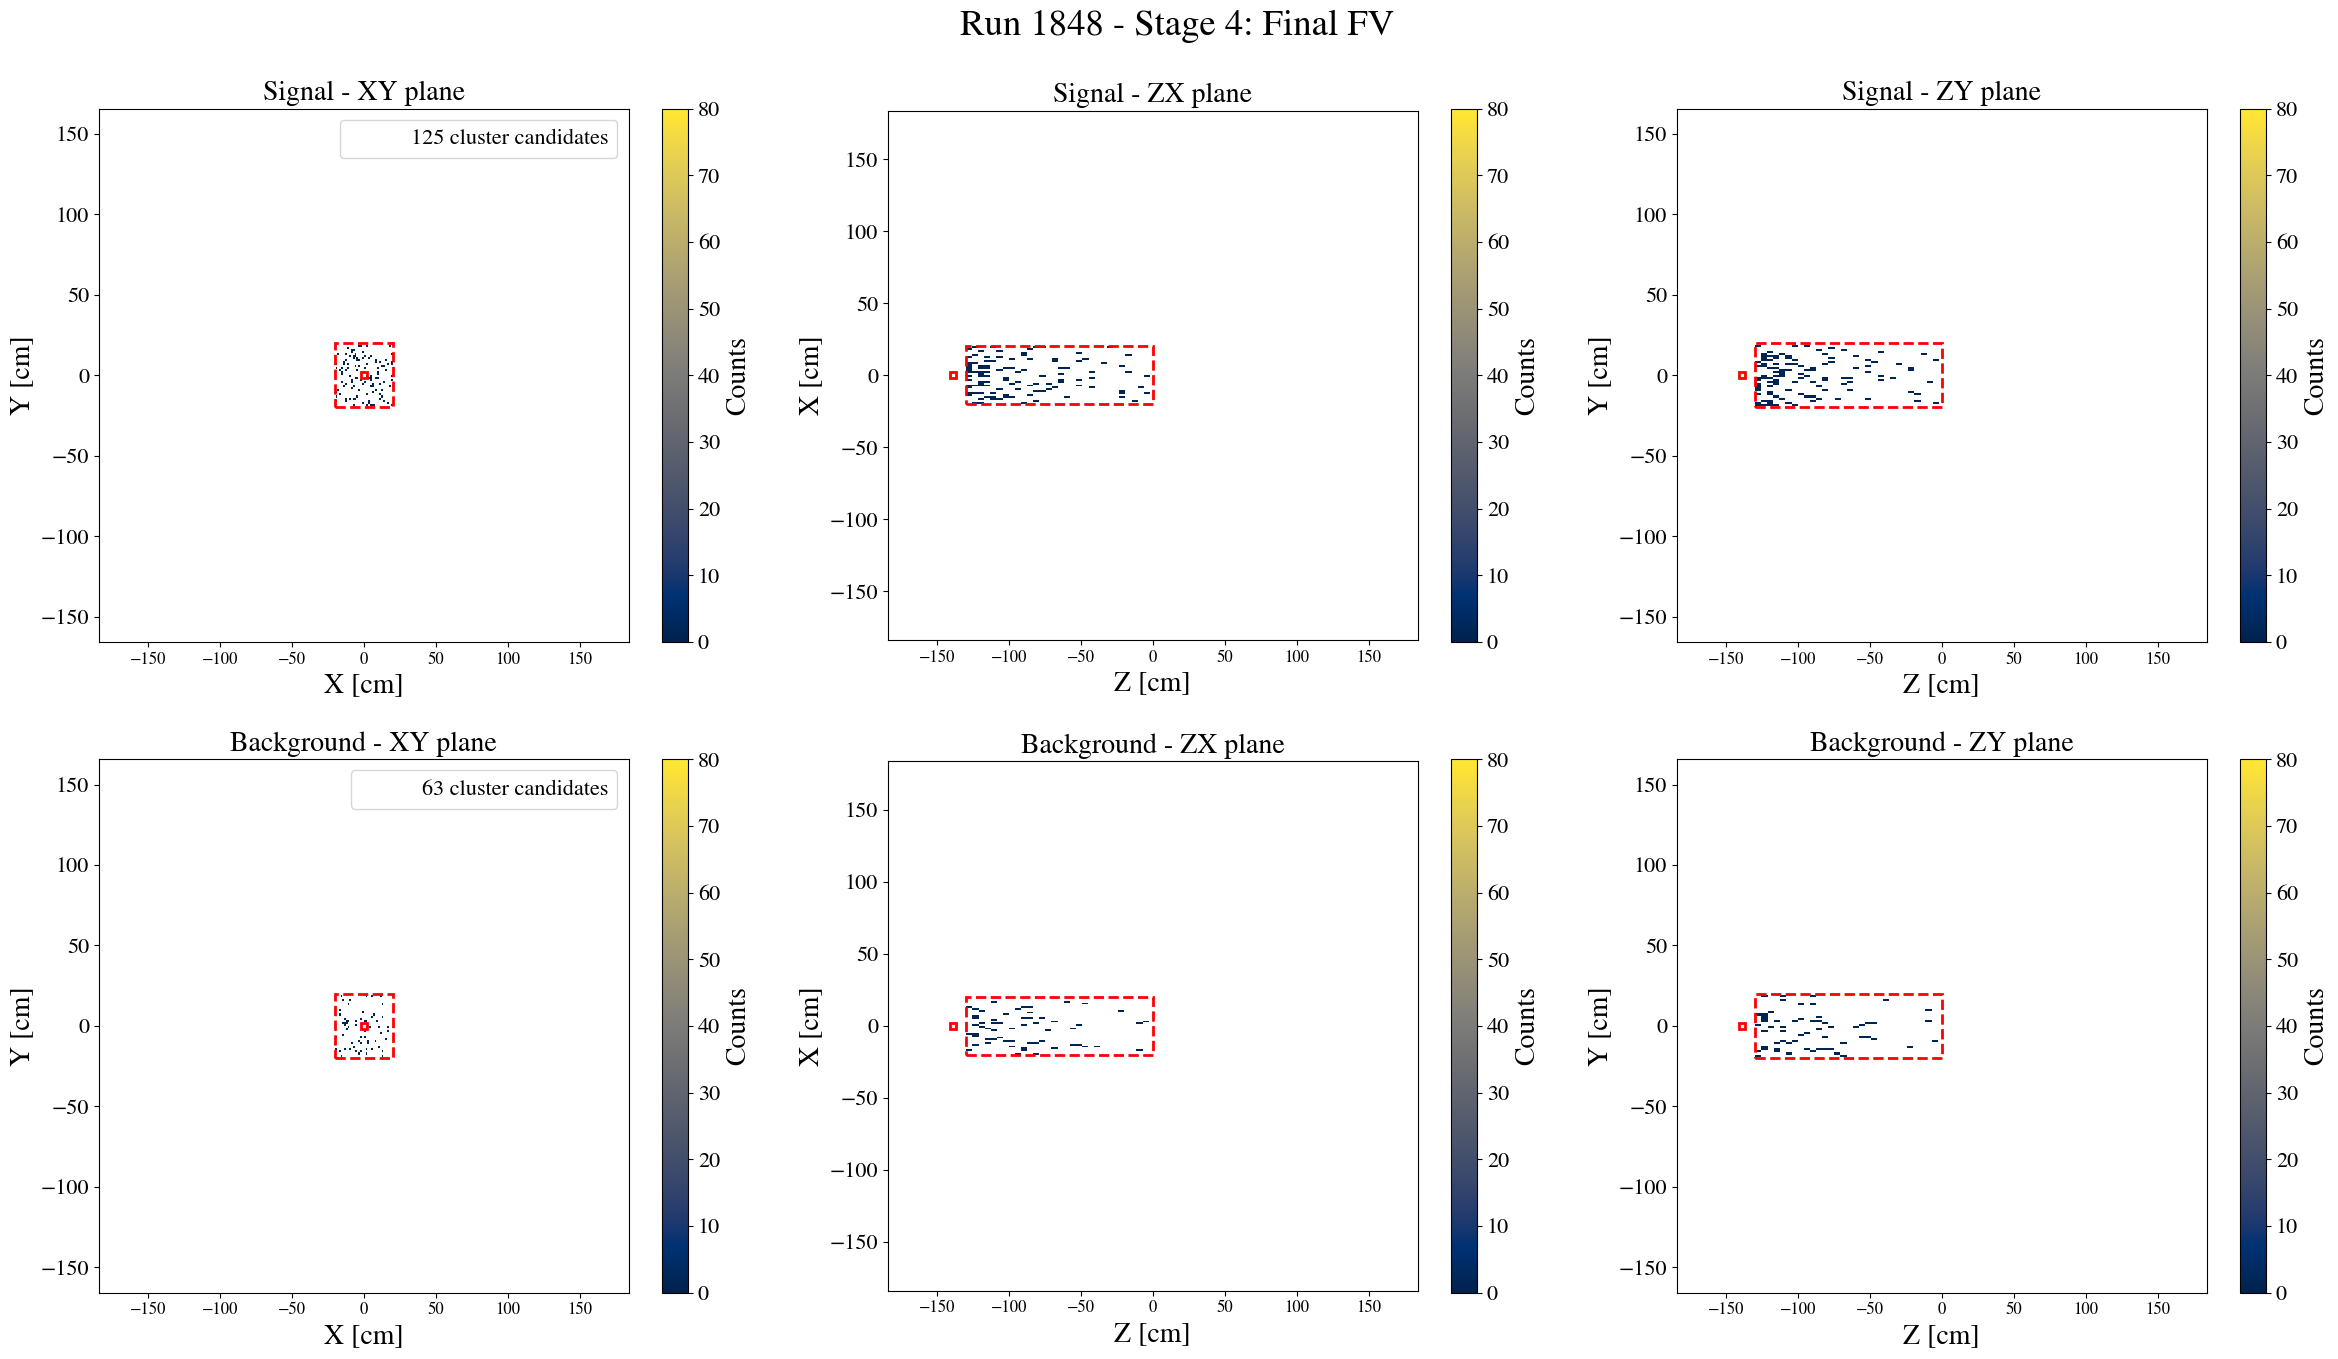

In [27]:
def plot_vertex_maps(df_sig, df_bkg, stage_name):

    if {"v_x_fine", "v_y_fine", "v_z_fine"}.issubset(df_sig.columns):
        xcol = "v_x_fine"
        ycol = "v_y_fine"
        zcol = "v_z_fine"
    else:
        xcol = "vertex_x"
        ycol = "vertex_y"
        zcol = "vertex_z"

    beam_pipe = [0.0, 0.0, -138.7963]
    beam_halfwidth = 2.0      # cm -> beam window = 4 cm diameter

    #beam spot size is not clear. Estimates suggest a transverse spread of approximately 3.5-4 cm sigma

    bins = 30
    vmax = 80

    R = 153.7963 #cm
    H = 271.4235 #cm

    # Fiducial Volume
    x_lims = [-20.0, 20.0]
    y_lims = [-20.0, 20.0]
    z_lims = [-130.0, 0.0]

    fig, axs = plt.subplots(2, 3, figsize=(24, 14))

    datasets = [
        ("Signal", df_sig),
        ("Background", df_bkg),
    ]

    for row, (label, df) in enumerate(datasets):

        mask = (
            df.fit_success
            & (df.chi2_ndof < 3)
            & (df[xcol]**2 + df[zcol]**2 <= R**2)
            & (np.abs(df[ycol]) <= H / 2)
        )

        df_clean = df.loc[mask]
        n_clusters = len(df_clean)

        print(f"{stage_name} - {label}: {n_clusters} clusters")

        # =====================================================
        # XY
        # =====================================================

        im = axs[row, 0].hist2d(
            df_clean[xcol],
            df_clean[ycol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row, 0].set_xlim(-R - 30, R + 30)
        axs[row, 0].set_ylim(-H / 2 - 30, H / 2 + 30)
        axs[row, 0].set_aspect("auto")

        # Beam pipe
        axs[row, 0].add_patch(
            Rectangle(
                (beam_pipe[0] - beam_halfwidth,
                 beam_pipe[1] - beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        # Fiducial Volume
        axs[row, 0].add_patch(
            Rectangle(
                (x_lims[0], y_lims[0]),
                x_lims[1] - x_lims[0],
                y_lims[1] - y_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row, 0].set_title(f"{label} - XY plane")
        axs[row, 0].set_xlabel("X [cm]")
        axs[row, 0].set_ylabel("Y [cm]")

        # Legend with number of cluster candidates (ONLY in XY)
        dummy = Line2D([], [], linestyle="", label=f"{n_clusters} cluster candidates")
        axs[row, 0].legend(handles=[dummy], loc="upper right", frameon=True)

        plt.colorbar(im[3], ax=axs[row, 0], label="Counts")

        # =====================================================
        # ZX
        # =====================================================

        im = axs[row, 1].hist2d(
            df_clean[zcol],
            df_clean[xcol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row, 1].set_xlim(-R - 30, R + 30)
        axs[row, 1].set_ylim(-R - 30, R + 30)
        axs[row, 1].set_aspect("equal")

        # Beam pipe
        axs[row, 1].add_patch(
            Rectangle(
                (beam_pipe[2] - beam_halfwidth,
                 beam_pipe[0] - beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        # Fiducial Volume
        axs[row, 1].add_patch(
            Rectangle(
                (z_lims[0], x_lims[0]),
                z_lims[1] - z_lims[0],
                x_lims[1] - x_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row, 1].set_title(f"{label} - ZX plane")
        axs[row, 1].set_xlabel("Z [cm]")
        axs[row, 1].set_ylabel("X [cm]")

        plt.colorbar(im[3], ax=axs[row, 1], label="Counts")

        # =====================================================
        # ZY
        # =====================================================

        im = axs[row, 2].hist2d(
            df_clean[zcol],
            df_clean[ycol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row, 2].set_xlim(-R - 30, R + 30)
        axs[row, 2].set_ylim(-H / 2 - 30, H / 2 + 30)
        axs[row, 2].set_aspect("auto")

        # Beam pipe
        axs[row, 2].add_patch(
            Rectangle(
                (beam_pipe[2] - beam_halfwidth,
                 beam_pipe[1] - beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        # Fiducial Volume
        axs[row, 2].add_patch(
            Rectangle(
                (z_lims[0], y_lims[0]),
                z_lims[1] - z_lims[0],
                y_lims[1] - y_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row, 2].set_title(f"{label} - ZY plane")
        axs[row, 2].set_xlabel("Z [cm]")
        axs[row, 2].set_ylabel("Y [cm]")

        plt.colorbar(im[3], ax=axs[row, 2], label="Counts")

    plt.suptitle(f"Run {run_number} - {stage_name}")
    plt.tight_layout()
    plt.show()


plot_vertex_maps(df_stage2_sig, df_stage2_bkg, "Stage 2: Multilateration")
plot_vertex_maps(df_stage4_sig, df_stage4_bkg, "Stage 3: Refinement")
plot_vertex_maps(df_stage5_sig, df_stage5_bkg, "Stage 4: Final FV")

##### check that the refinement vertex coordinates (v_x_fine) are different from the ones of the 1st iteration of the vertex reconstruction with the Multilaterator and the new geometry (WCTE convention)

In [28]:
print((df_stage4_sig["vertex_x"] == df_stage4_sig["v_x_fine"]).all())
print((df_stage4_sig["vertex_y"] == df_stage4_sig["v_y_fine"]).all())
print((df_stage4_sig["vertex_z"] == df_stage4_sig["v_z_fine"]).all())

False
False
False


Text(0, 0.5, 'Refined z [cm]')

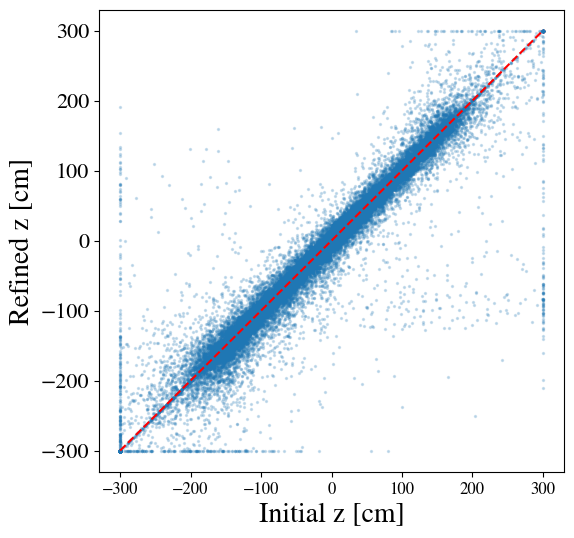

In [29]:
plt.figure(figsize=(6,6))

plt.scatter(df_stage4_sig["vertex_z"],df_stage4_sig["v_z_fine"],s=2,alpha=0.2)
plt.plot([-300,300],[-300,300],"r--")

plt.xlabel("Initial z [cm]")
plt.ylabel("Refined z [cm]")

### pasamos a los global plots (por beam momenta)

In [30]:
import os
import glob
import numpy as np
import pandas as pd
from glob import glob

# ============================================
#==============
# Configuración general y Volúmenes Fiduciales
# ==========================================================
runs = [1846, 1848, 1928, 1930, 1932, 1934, 1935, 1936, 1937, 1938, 1939, 1941]
base_dir = "/scratch/elena/9Li/results"

fv_tags = ["FV_1", "FV_2", "FV_3", "FV_4"]

def get_beam_momentum(run):
    return "-340 MeV/c" if run in [1846, 1848] else "-260 MeV/c"

# ==========================================================
# Selección de calidad geométrica general
# ==========================================================
R = 153.7963    # Radio WCTE [cm]
H = 271.4235      # Altura WCTE [cm]

def select_good_vertices(df):
    if df.empty:
        return df

    if {"v_x_fine", "v_y_fine", "v_z_fine"}.issubset(df.columns):
        x = df["v_x_fine"]
        y = df["v_y_fine"]
        z = df["v_z_fine"]
    else:
        x = df["vertex_x"]
        y = df["vertex_y"]
        z = df["vertex_z"]

    mask = (
        df["fit_success"]
        & (df["chi2_ndof"] < 3)
        & (x**2 + z**2 <= R**2)
        & (np.abs(y) <= H/2)
    )

    return df.loc[mask].copy()

# ==========================================================
# Estructura de contenedores para los 4 FVs
# ==========================================================
# Estructura: datasets[fv_tag][beam][mode]["before"/"after"]
datasets = {
    fv: {
        "-340 MeV/c": {
            "signal": {"before": [], "after": []},
            "background (bkg)": {"before": [], "after": []},
        },
        "-260 MeV/c": {
            "signal": {"before": [], "after": []},
            "background (bkg)": {"before": [], "after": []},
        },
    }
    for fv in fv_tags
}

# ==========================================================
# Lectura de todos los runs y volúmenes fiduciales
# ==========================================================
for run in runs:
    beam = get_beam_momentum(run)
    processed_dir = os.path.join(base_dir, f"run{run}", "processed")

    for mode in ["signal", "background (bkg)"]:
        is_bkg = mode == "background (bkg)"
        suffix = "_BKG" if is_bkg else ""

        # --------------------------------------------------
        # Stage 4 (Before FV) - Se carga una sola vez por run
        # --------------------------------------------------
        refine_files = sorted(
            glob(os.path.join(processed_dir, f"Refine_Li9_clusters_chunk*{suffix}.pkl"))
        )

        df_before = pd.DataFrame()
        if refine_files:
            df_before = pd.concat(
                [pd.read_pickle(f) for f in refine_files],
                ignore_index=True
            )
            df_before = select_good_vertices(df_before)

        # --------------------------------------------------
        # Stage 5 (After FV) - Se carga para cada FV
        # --------------------------------------------------
        for fv in fv_tags:
            fv_dir = os.path.join(processed_dir, fv)
            
            # Guardamos el "before" (es el mismo para todos los FV)
            if not df_before.empty:
                datasets[fv][beam][mode]["before"].append(df_before)

            final_file = os.path.join(
                fv_dir,
                f"Final_FV_Li9_clusters_run{run}{suffix}.pkl"
            )

            if os.path.exists(final_file):
                df_after = pd.read_pickle(final_file)
                df_after = select_good_vertices(df_after)
                datasets[fv][beam][mode]["after"].append(df_after)
            else:
                print(f"WARNING: Missing {final_file}")

# ==========================================================
# Concatenación global
# ==========================================================
combined = {fv: {} for fv in fv_tags}

for fv in fv_tags:
    for beam in datasets[fv]:
        combined[fv][beam] = {}
        for mode in datasets[fv][beam]:
            before_list = datasets[fv][beam][mode]["before"]
            after_list = datasets[fv][beam][mode]["after"]

            combined[fv][beam][mode] = {
                "before": (
                    pd.concat(before_list, ignore_index=True)
                    if before_list else pd.DataFrame()
                ),
                "after": (
                    pd.concat(after_list, ignore_index=True)
                    if after_list else pd.DataFrame()
                ),
            }

# ==========================================================
# Resumen impreso de eficiencias
# ==========================================================
for fv in fv_tags:
    print("\n" + "=" * 90)
    print(f" FIDUCIAL VOLUME: {fv}")
    print("=" * 90)
    for beam in ["-340 MeV/c", "-260 MeV/c"]:
        print(f"\n --- Dataset: {beam} ---")
        for mode in ["signal", "background (bkg)"]:
            before = combined[fv][beam][mode]["before"]
            after = combined[fv][beam][mode]["after"]

            n_before = len(before)
            n_after = len(after)
            eff = 100 * n_after / n_before if n_before > 0 else 0

            print(f"  [{mode.upper():<16}] Before FV: {n_before:>7,} | Inside FV: {n_after:>7,} | Eff: {eff:6.2f}%")

/tmp/ipykernel_295804/551605094.py:85: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_before = pd.concat(



 FIDUCIAL VOLUME: FV_1

 --- Dataset: -340 MeV/c ---
  [SIGNAL          ] Before FV:  24,880 | Inside FV:     275 | Eff:   1.11%
  [BACKGROUND (BKG)] Before FV:   8,557 | Inside FV:     141 | Eff:   1.65%

 --- Dataset: -260 MeV/c ---
  [SIGNAL          ] Before FV: 170,401 | Inside FV:     346 | Eff:   0.20%
  [BACKGROUND (BKG)] Before FV: 120,792 | Inside FV:     852 | Eff:   0.71%

 FIDUCIAL VOLUME: FV_2

 --- Dataset: -340 MeV/c ---
  [SIGNAL          ] Before FV:  24,880 | Inside FV:     147 | Eff:   0.59%
  [BACKGROUND (BKG)] Before FV:   8,557 | Inside FV:      79 | Eff:   0.92%

 --- Dataset: -260 MeV/c ---
  [SIGNAL          ] Before FV: 170,401 | Inside FV:     238 | Eff:   0.14%
  [BACKGROUND (BKG)] Before FV: 120,792 | Inside FV:     616 | Eff:   0.51%

 FIDUCIAL VOLUME: FV_3

 --- Dataset: -340 MeV/c ---
  [SIGNAL          ] Before FV:  24,880 | Inside FV:     133 | Eff:   0.53%
  [BACKGROUND (BKG)] Before FV:   8,557 | Inside FV:      74 | Eff:   0.86%

 --- Dataset: -26

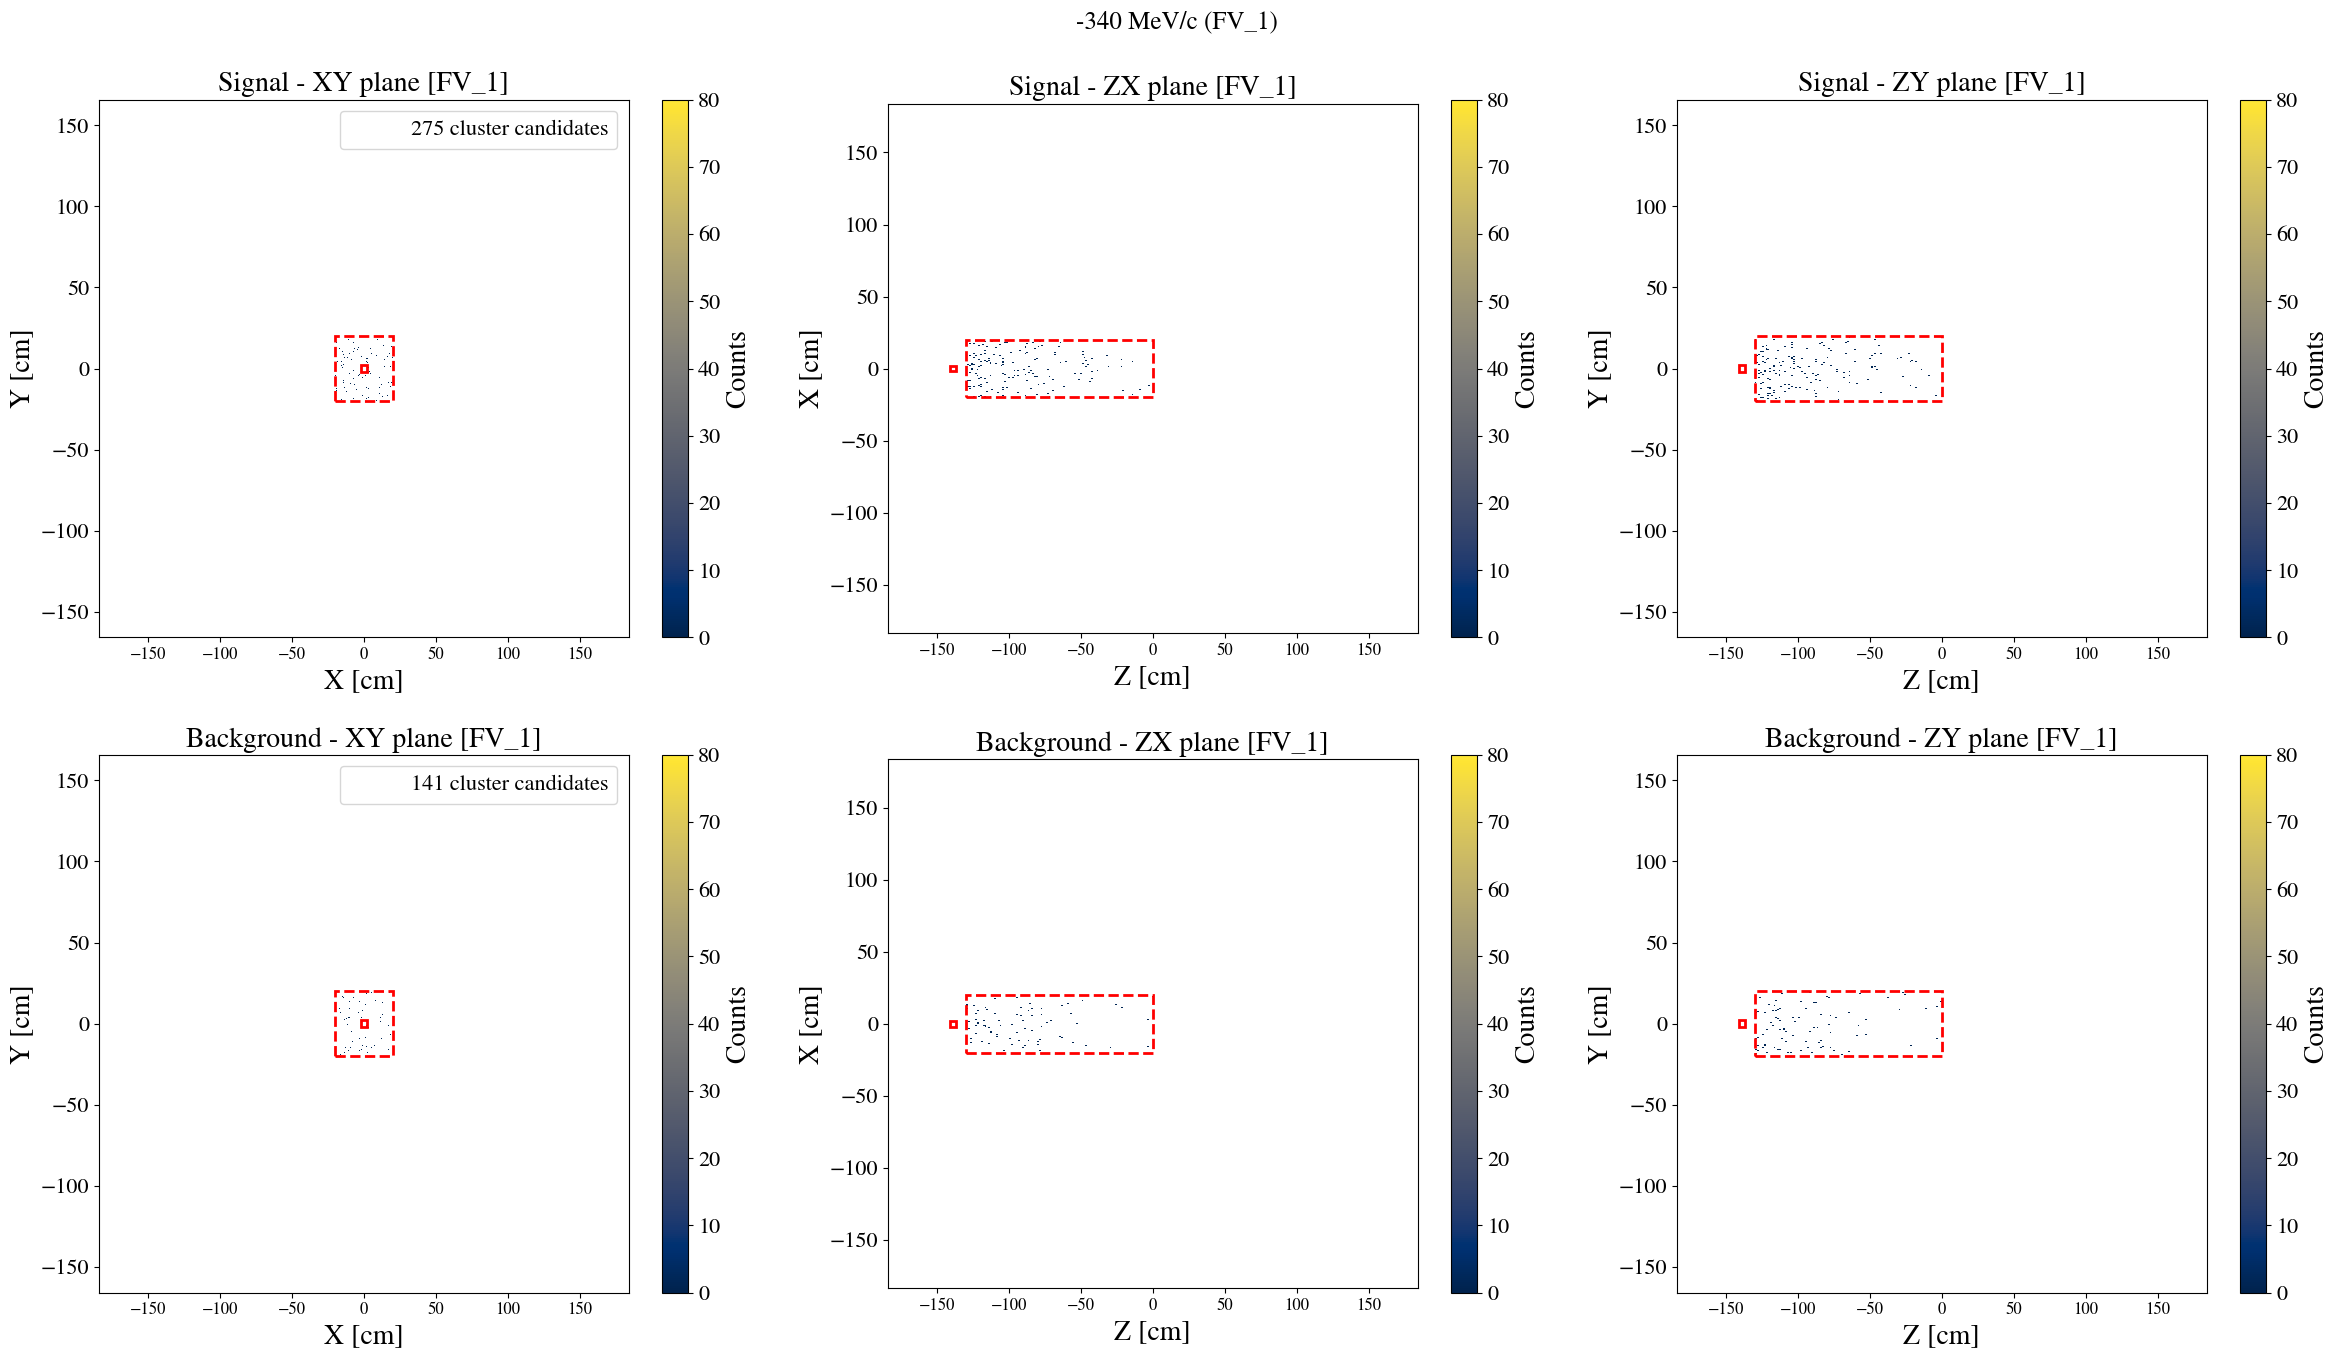

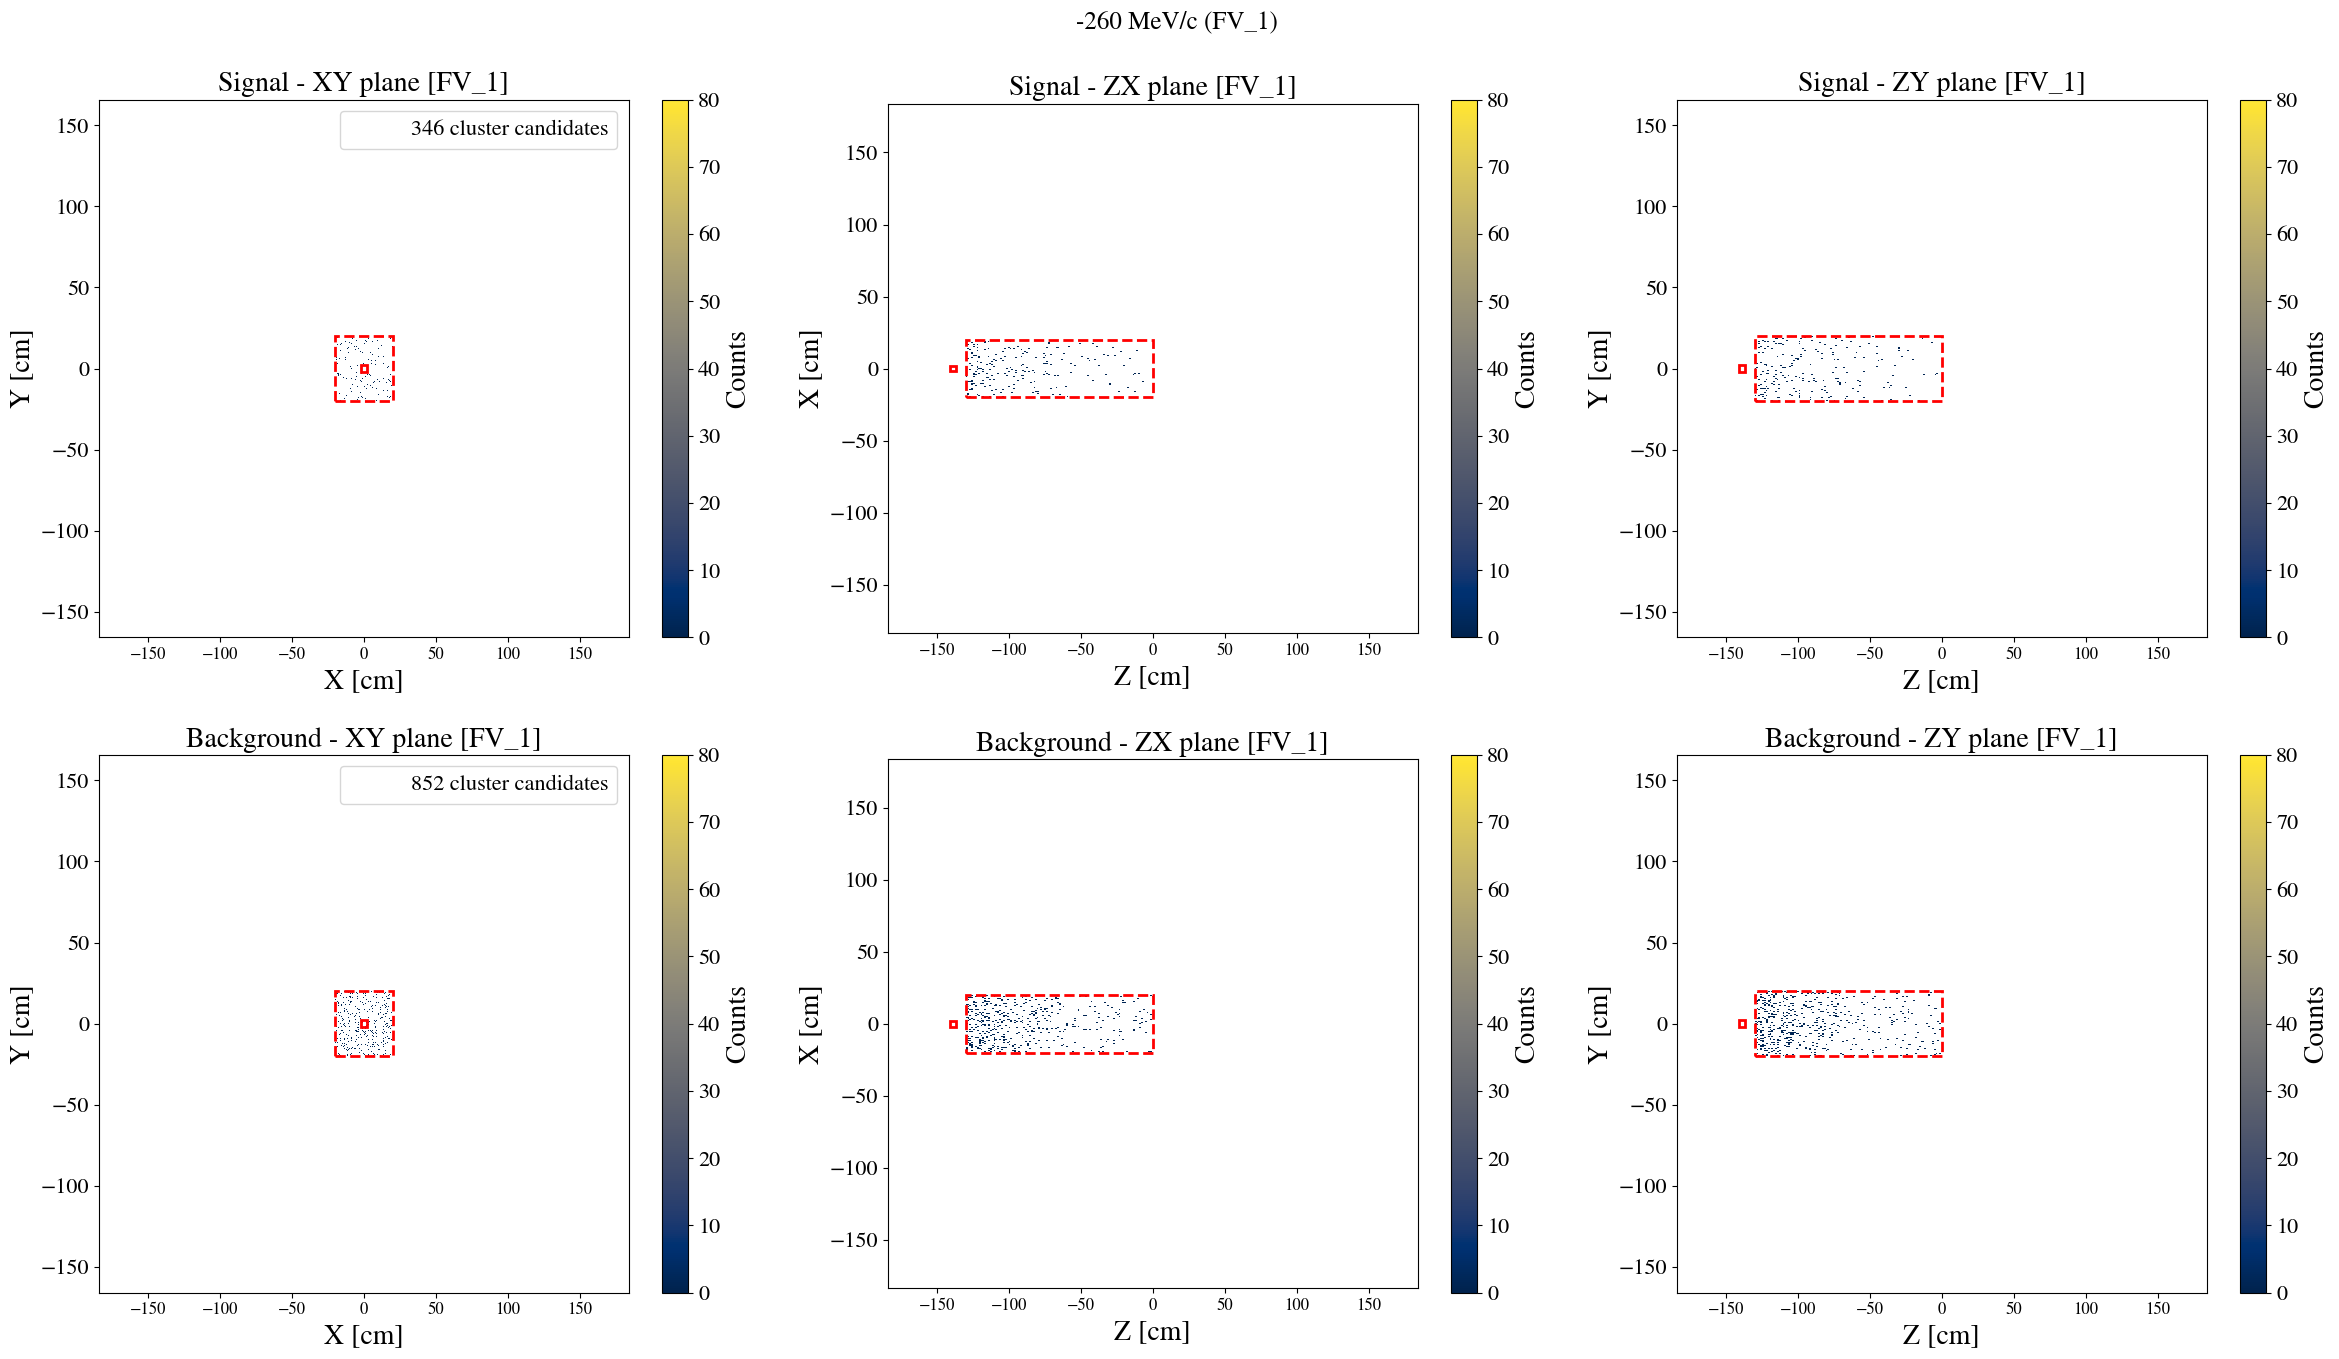

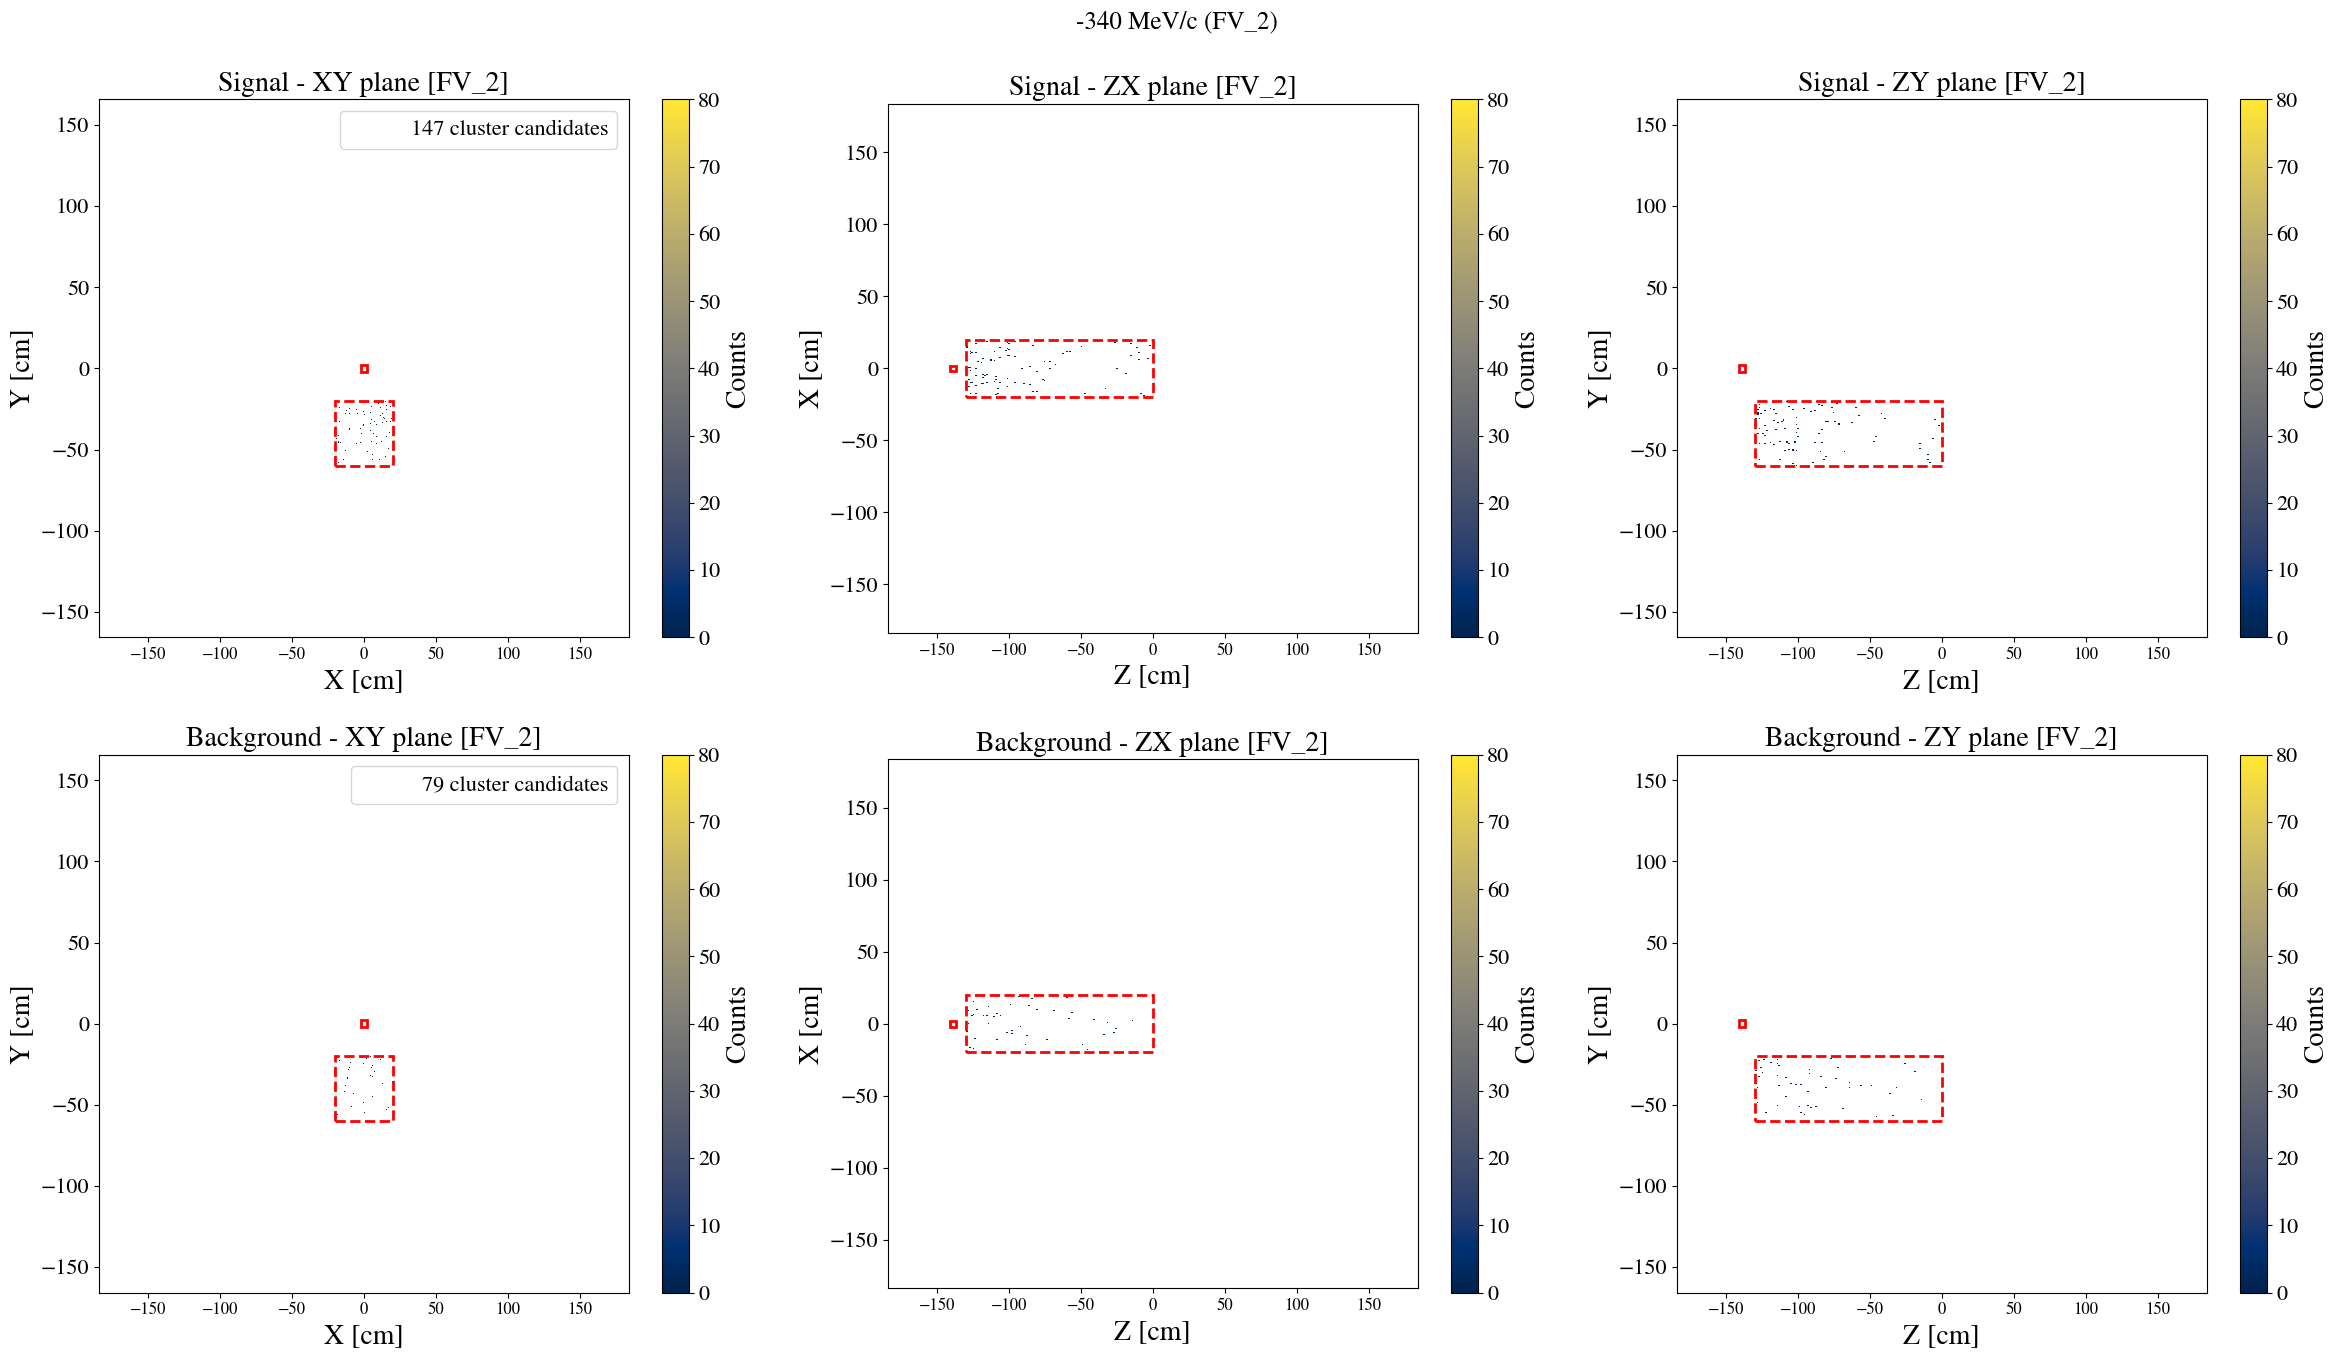

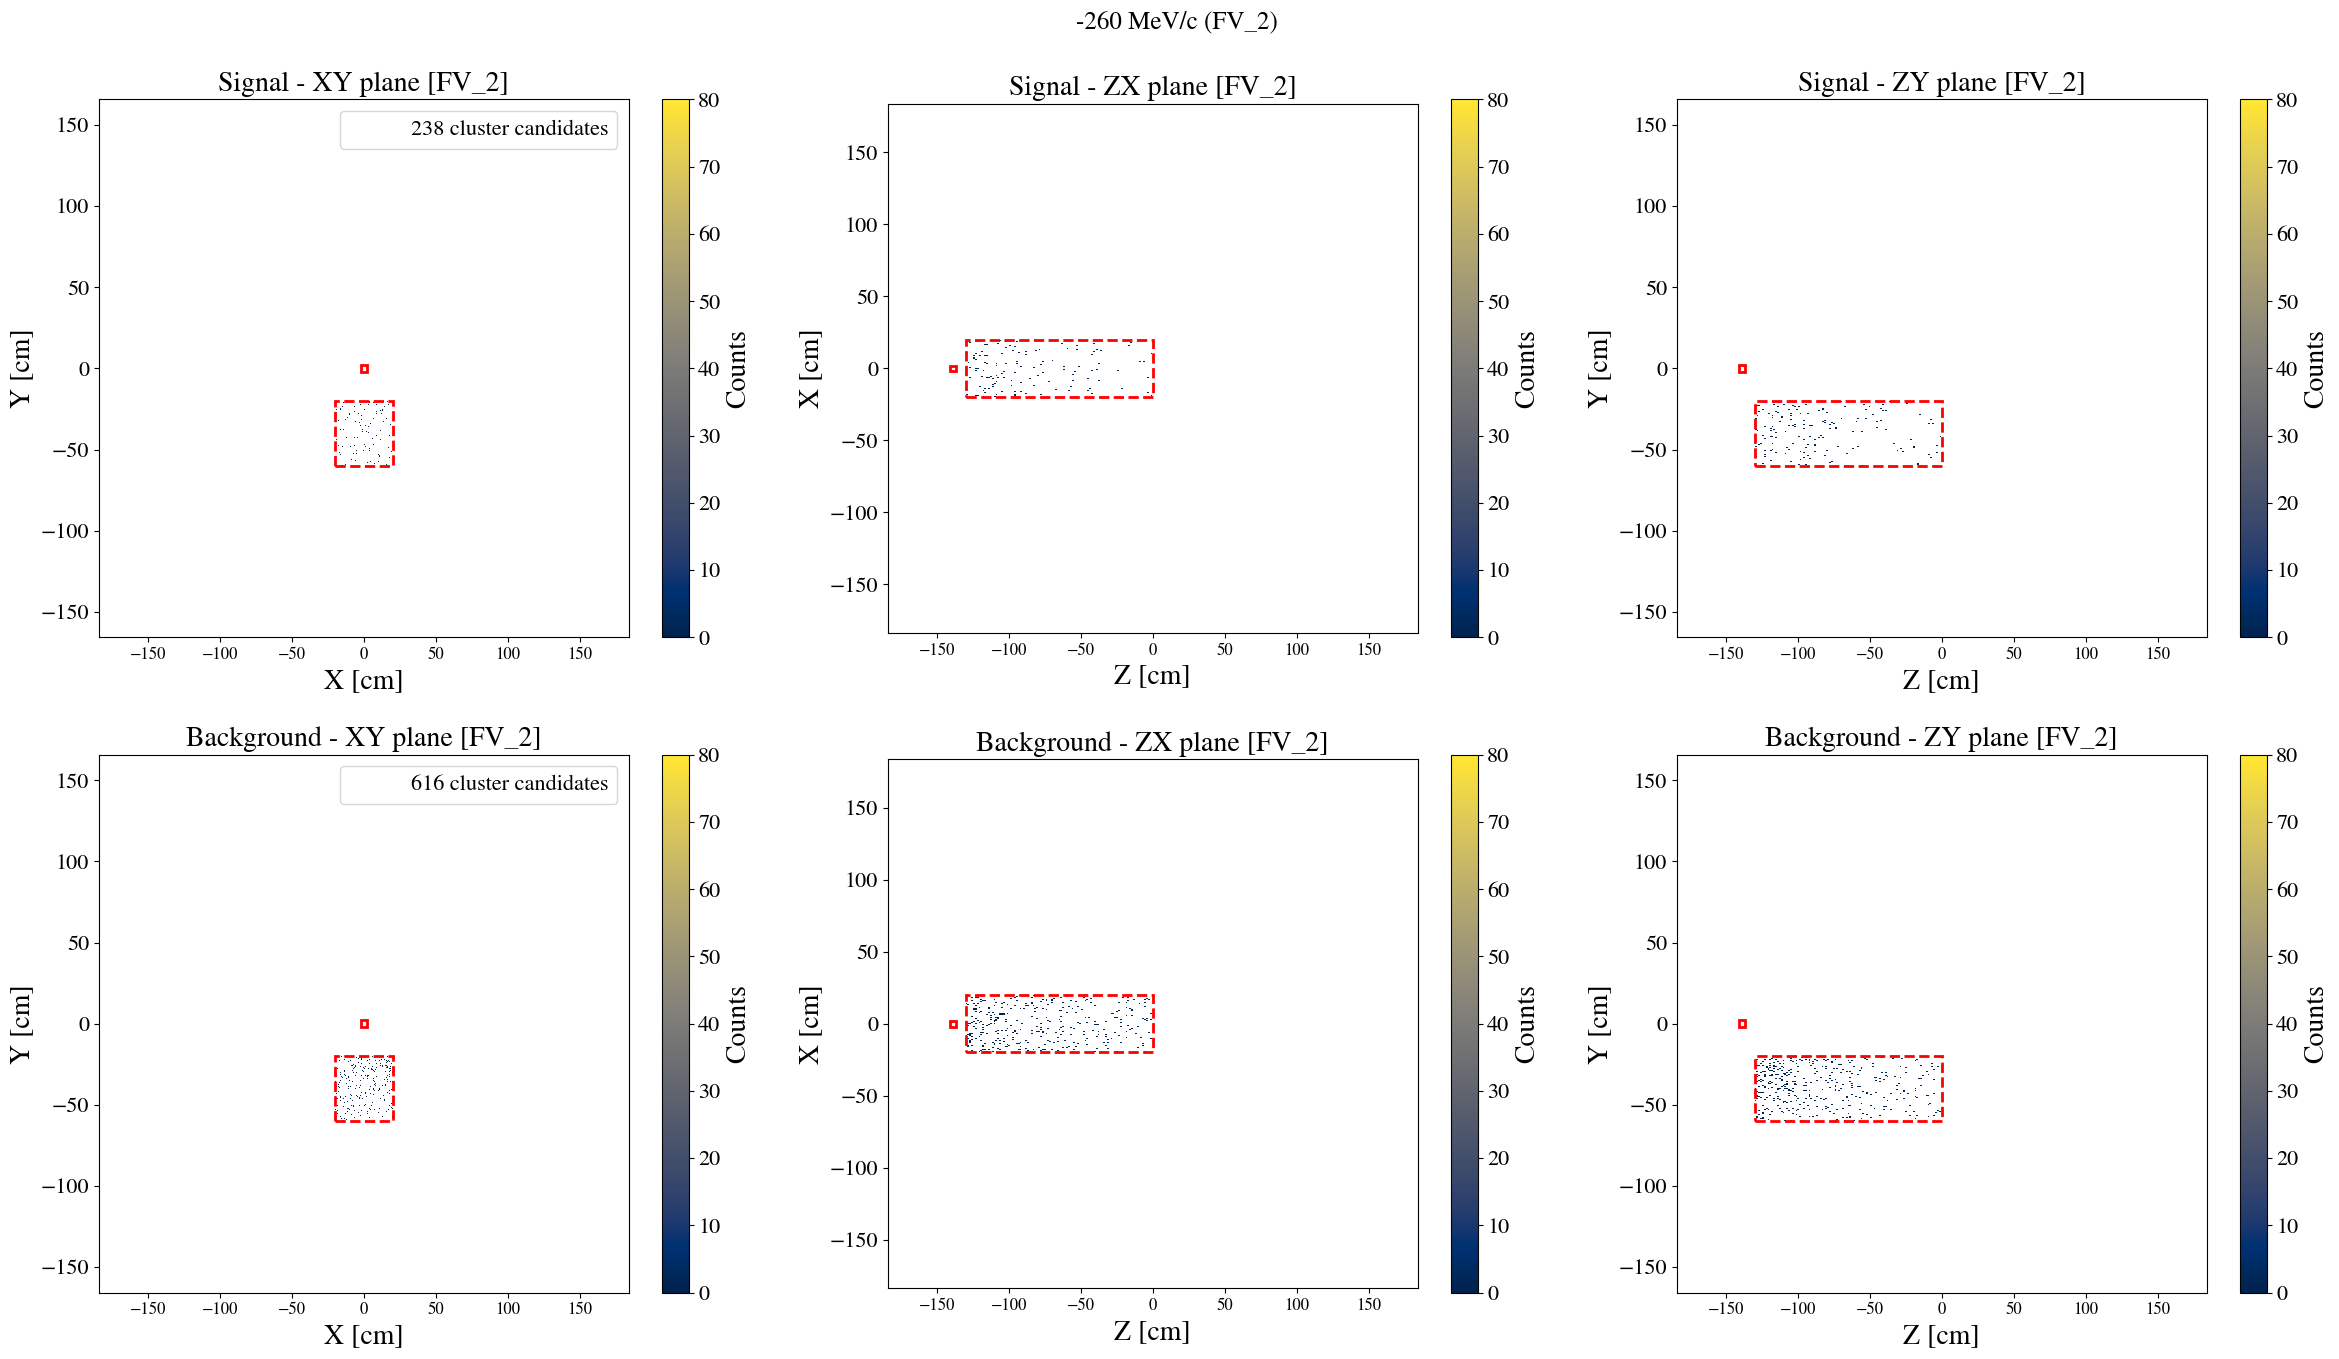

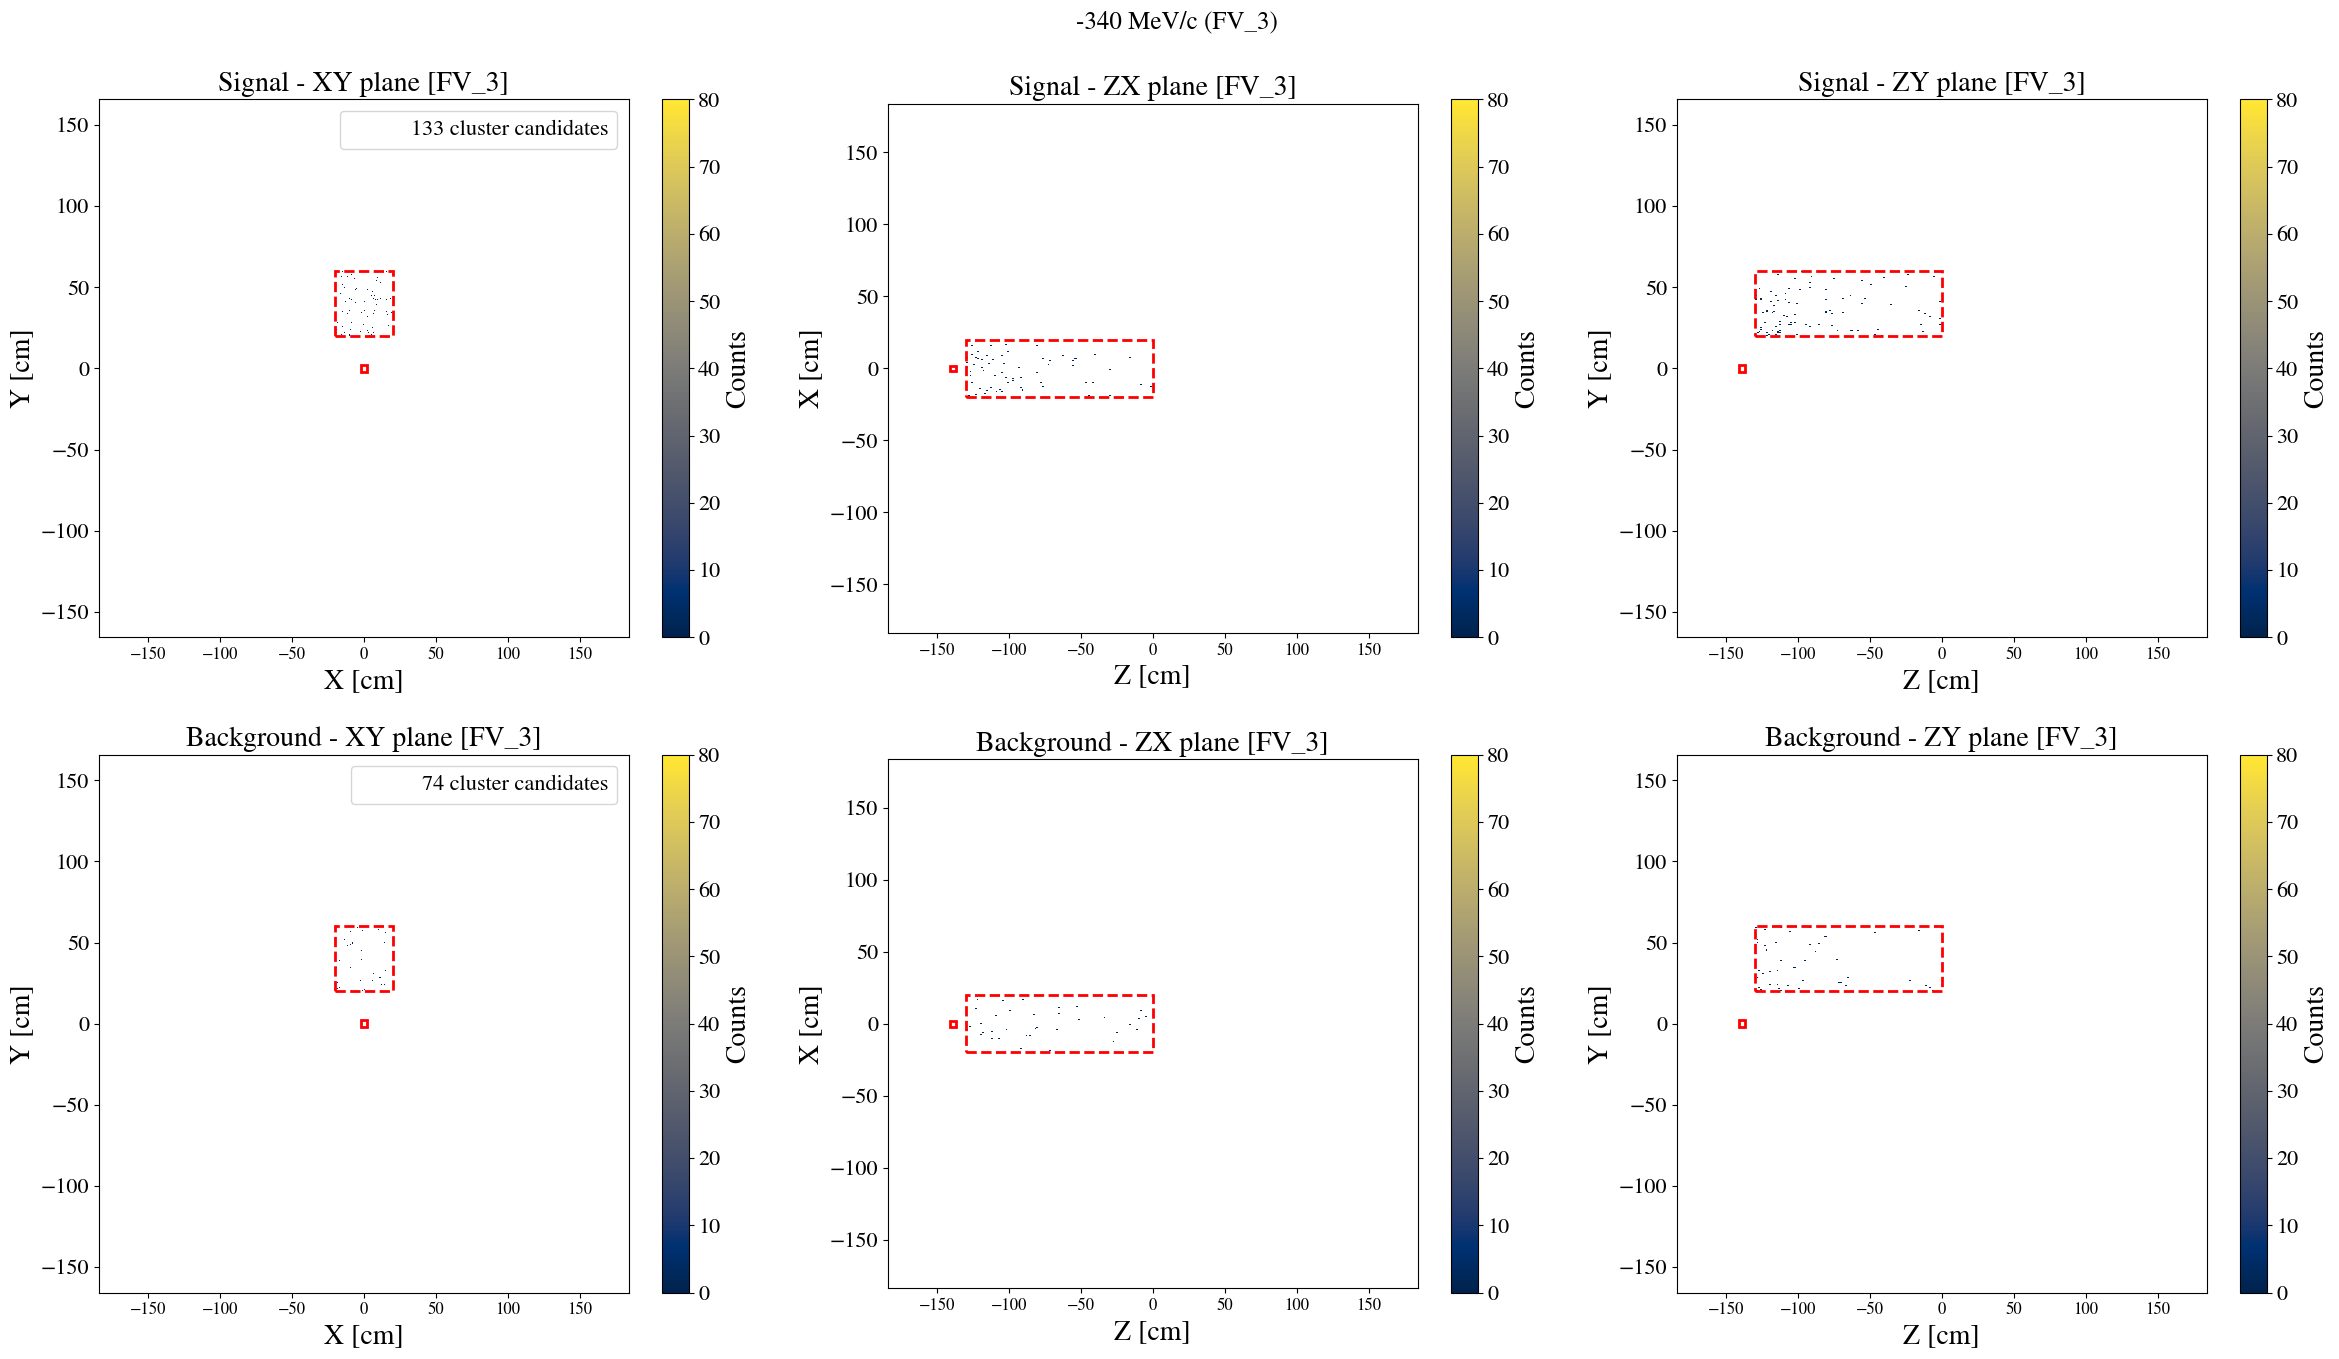

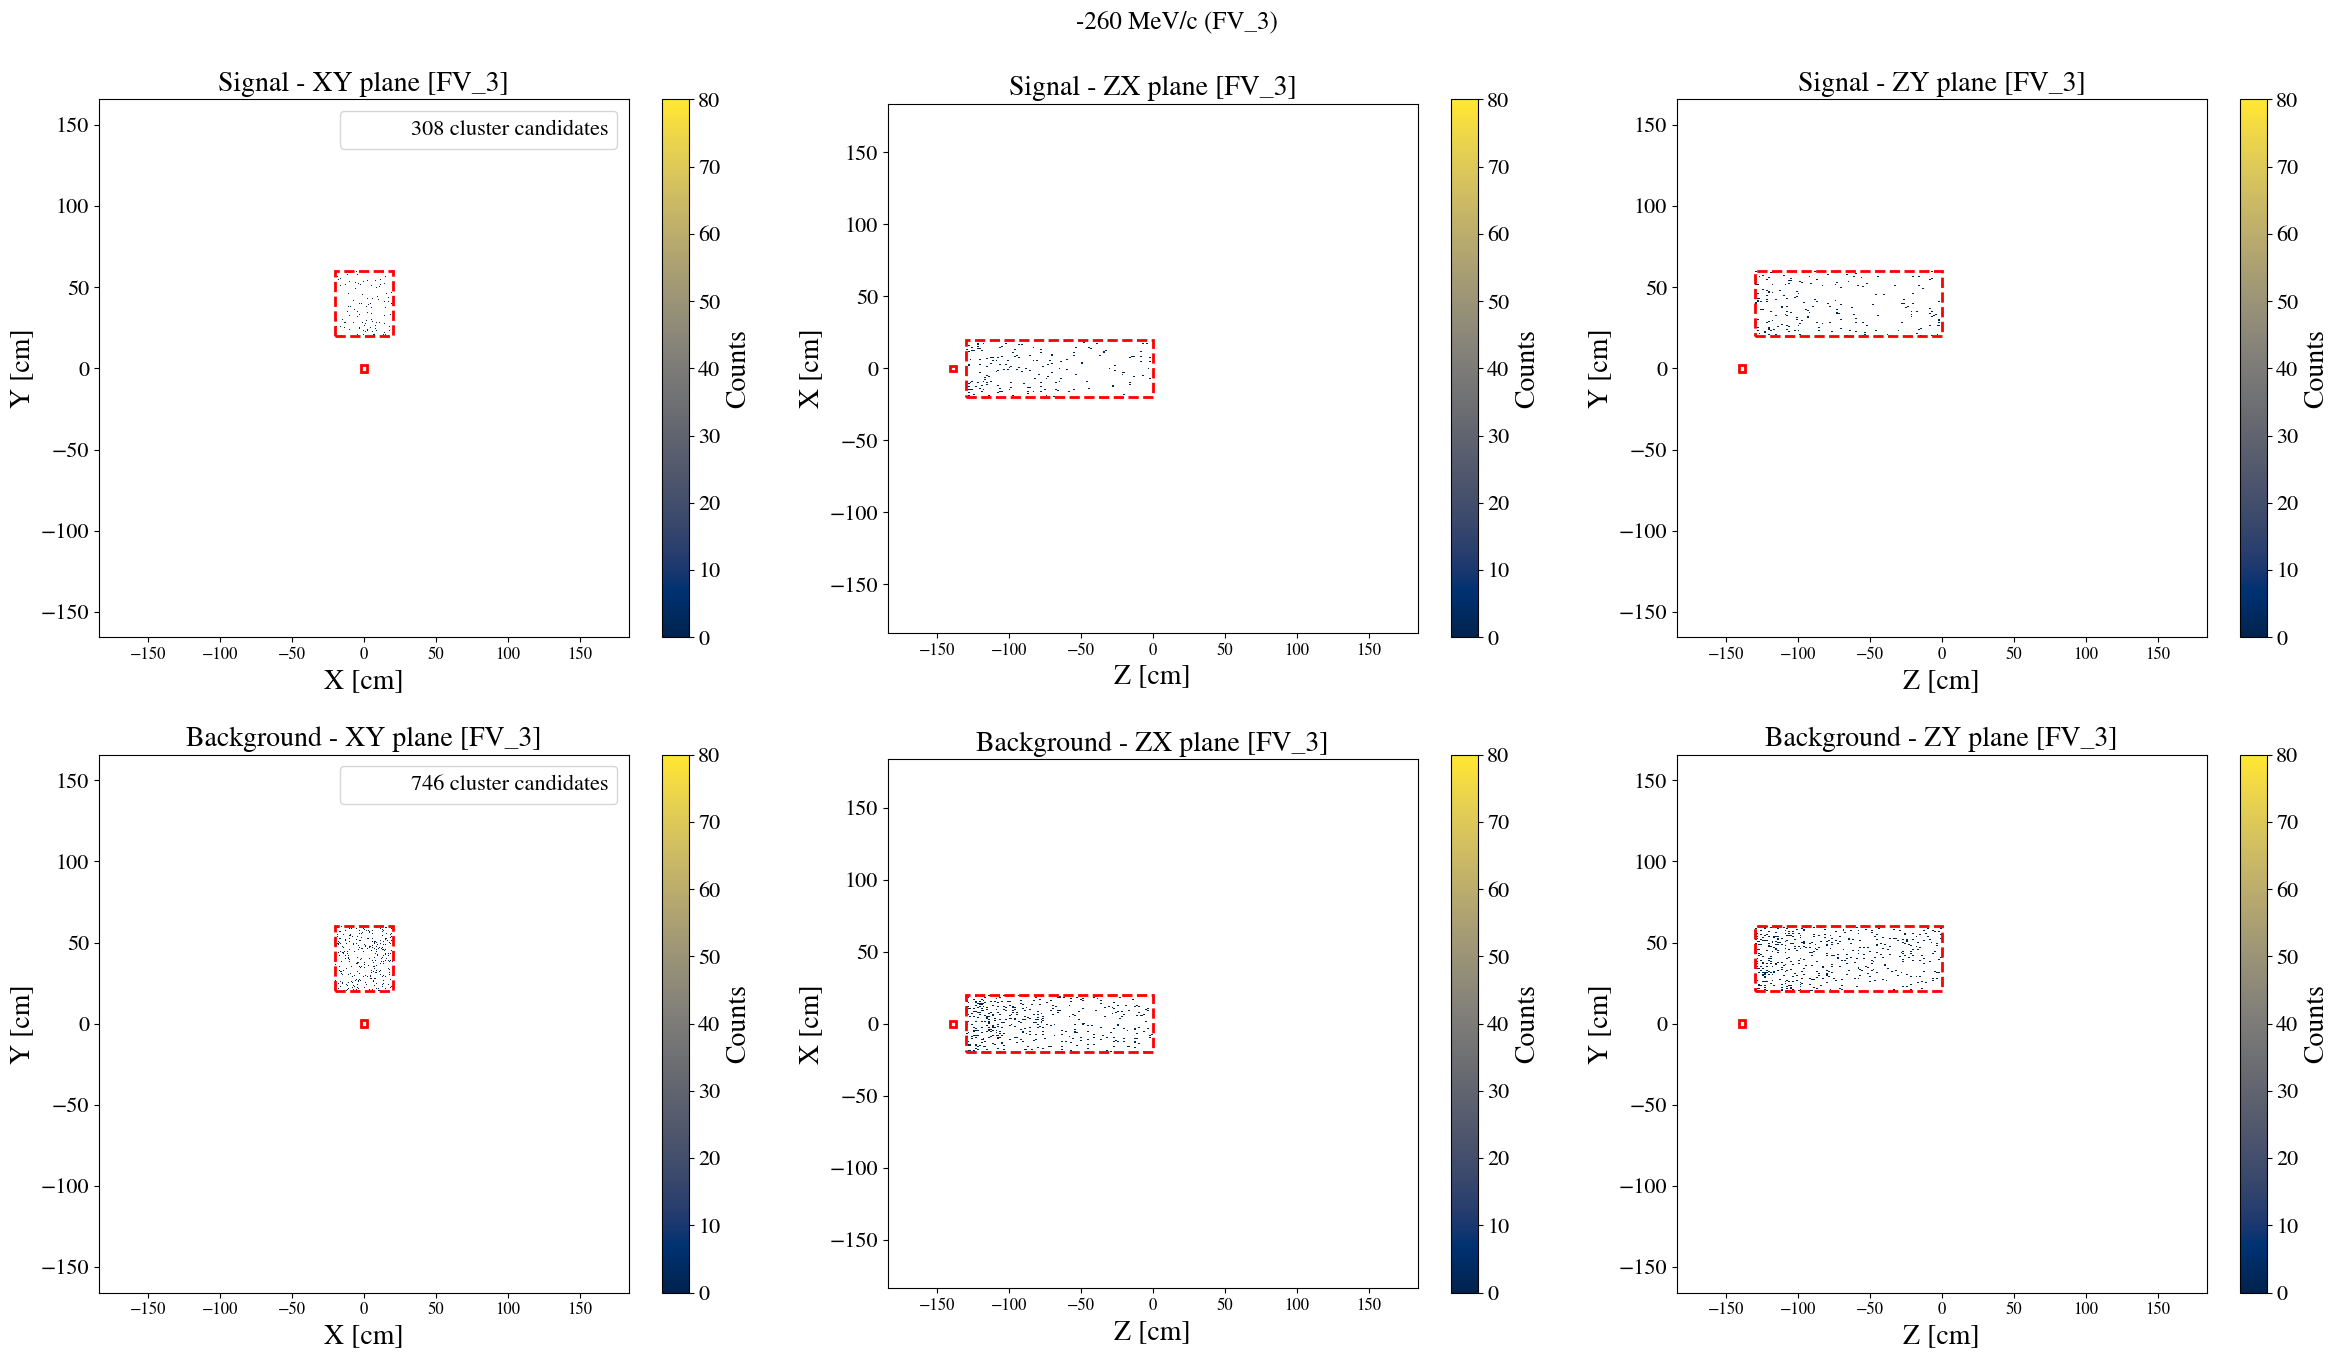

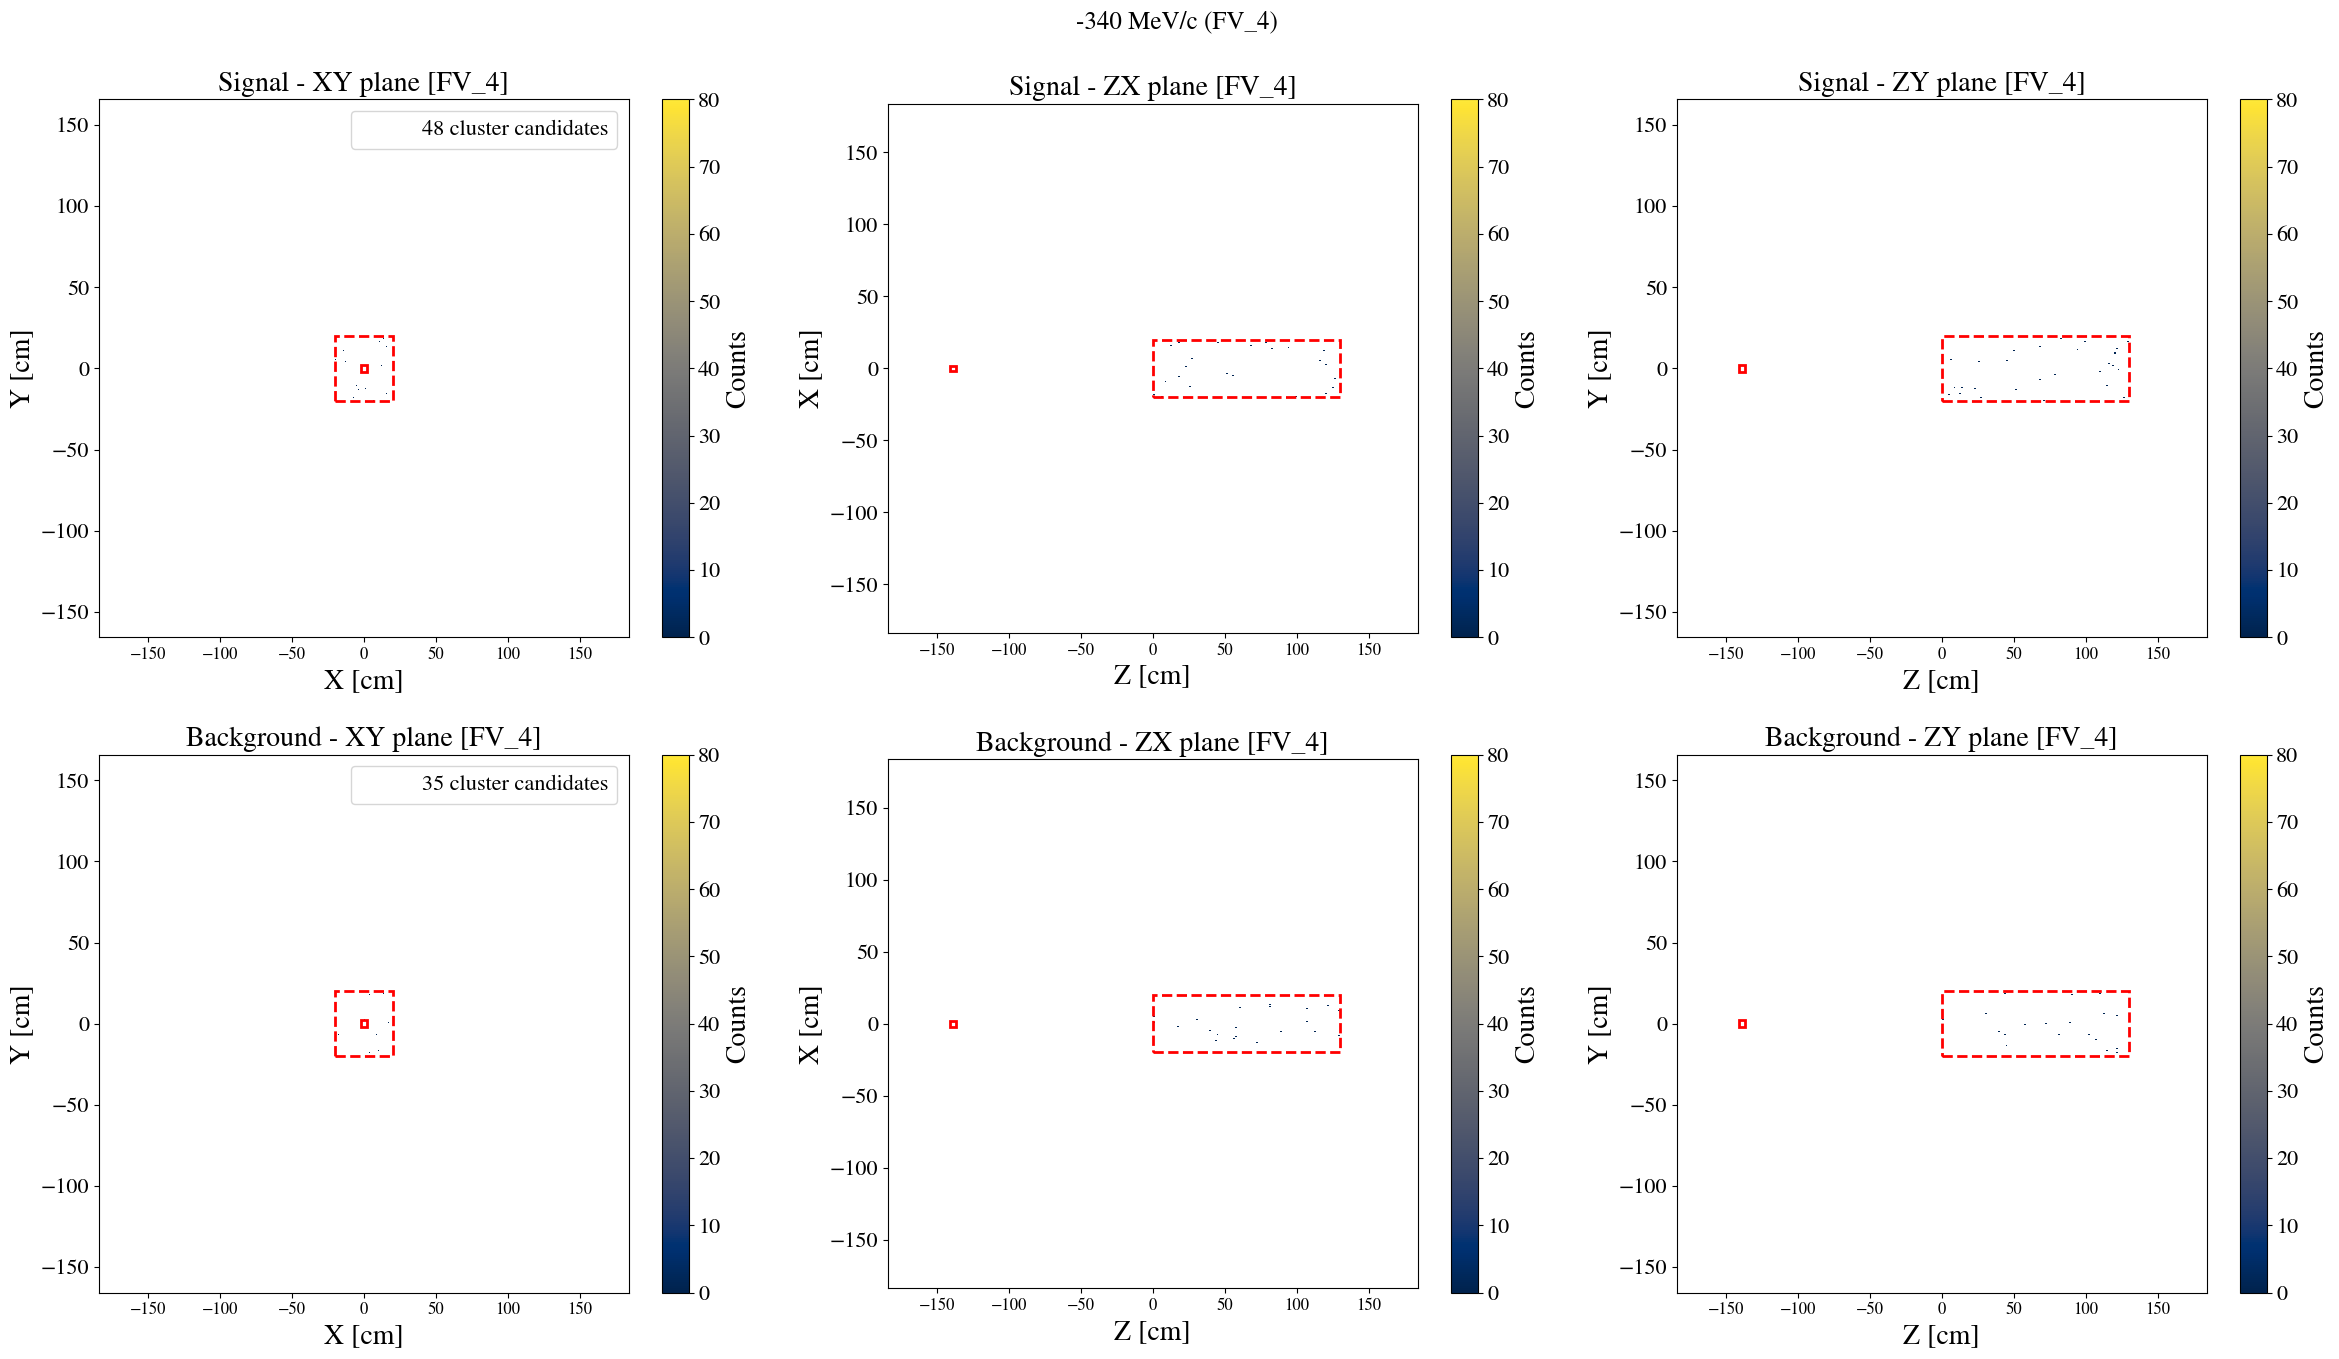

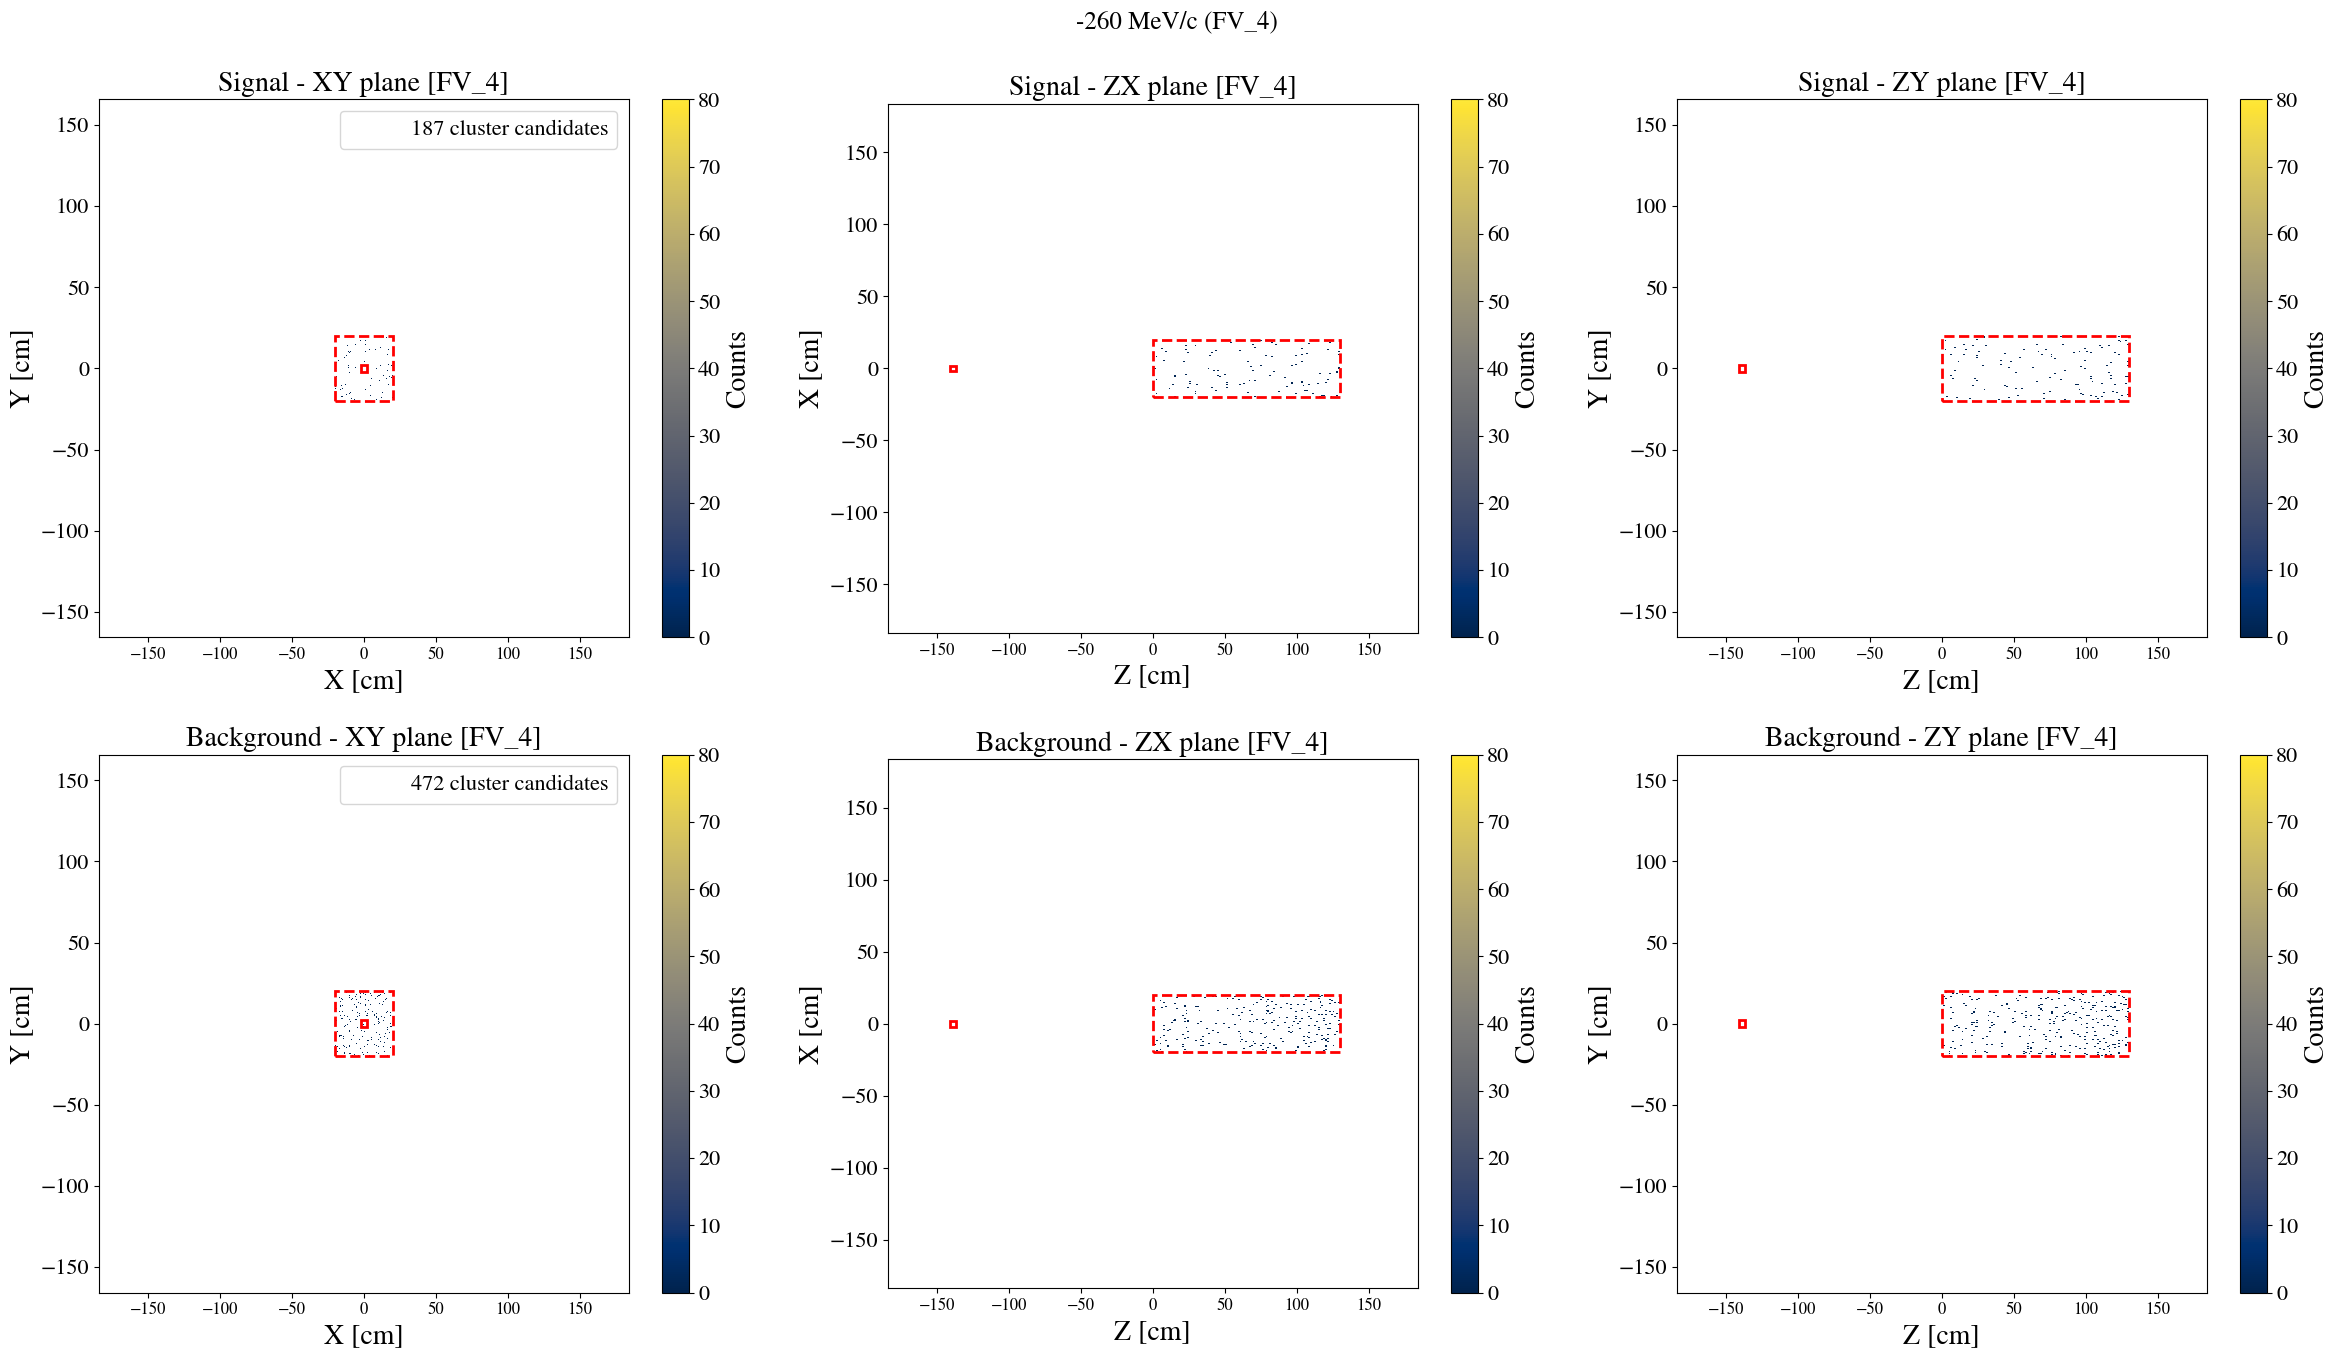

In [31]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# =====================================================
# Límites de los Volúmenes Fiduciales
# =====================================================
FV_LIMITS = {
    "FV_1": {"x": (-20.0, 20.0), "y": (-20.0, 20.0), "z": (-130.0, 0.0)},
    "FV_2": {"x": (-20.0, 20.0), "y": (-60.0, -20.0), "z": (-130.0, 0.0)},
    "FV_3": {"x": (-20.0, 20.0), "y": (20.0, 60.0), "z": (-130.0, 0.0)},
    "FV_4": {"x": (-20.0, 20.0), "y": (-20.0, 20.0), "z": (0.0, 130.0)},
}

# =====================================================
# Función para representar los mapas 2D
# =====================================================
def plot_vertex_maps_fv(df_sig, df_bkg, stage_name, fv_tag):

    x_lims = list(FV_LIMITS[fv_tag]["x"])
    y_lims = list(FV_LIMITS[fv_tag]["y"])
    z_lims = list(FV_LIMITS[fv_tag]["z"])

    if {"v_x_fine", "v_y_fine", "v_z_fine"}.issubset(df_sig.columns):
        xcol, ycol, zcol = "v_x_fine", "v_y_fine", "v_z_fine"
    else:
        xcol, ycol, zcol = "vertex_x", "vertex_y", "vertex_z"

    beam_pipe = [0.0, 0.0, -138.7963]
    beam_halfwidth = 2.0

    bins = 100
    vmax = 80
    R = 153.7963 #cm
    H = 271.4235 #cm

    fig, axs = plt.subplots(2, 3, figsize=(24, 14))

    datasets_to_plot = [
        ("Signal", df_sig),
        ("Background", df_bkg),
    ]

    for row, (label, df) in enumerate(datasets_to_plot):

        mask = (
            df.fit_success
            & (df.chi2_ndof < 3)
            & (df[xcol]**2 + df[zcol]**2 <= R**2)
            & (np.abs(df[ycol]) <= H/2)
        )

        df_clean = df.loc[mask]
        n_clusters = len(df_clean)

        # XY Plane
        im = axs[row,0].hist2d(
            df_clean[xcol], df_clean[ycol],
            bins=bins, cmap="cividis", cmin=1, vmin=0, vmax=vmax
        )
        axs[row,0].set_xlim(-R-30, R+30)
        axs[row,0].set_ylim(-H/2-30, H/2+30)
        axs[row,0].add_patch(Rectangle((beam_pipe[0]-beam_halfwidth, beam_pipe[1]-beam_halfwidth), 4, 4, facecolor="none", edgecolor="red", linewidth=2))
        axs[row,0].add_patch(Rectangle((x_lims[0], y_lims[0]), x_lims[1]-x_lims[0], y_lims[1]-y_lims[0], facecolor="none", edgecolor="red", linestyle="--", linewidth=2))
        axs[row,0].set_title(f"{label} - XY plane [{fv_tag}]")
        axs[row,0].set_xlabel("X [cm]")
        axs[row,0].set_ylabel("Y [cm]")
        dummy = Line2D([], [], linestyle="", label=f"{n_clusters} cluster candidates")
        axs[row,0].legend(handles=[dummy], loc="upper right", frameon=True)
        plt.colorbar(im[3], ax=axs[row,0], label="Counts")

        # ZX Plane
        im = axs[row,1].hist2d(
            df_clean[zcol], df_clean[xcol],
            bins=bins, cmap="cividis", cmin=1, vmin=0, vmax=vmax
        )
        axs[row,1].set_xlim(-R-30, R+30)
        axs[row,1].set_ylim(-R-30, R+30)
        axs[row,1].set_aspect("equal")
        axs[row,1].add_patch(Rectangle((beam_pipe[2]-beam_halfwidth, beam_pipe[0]-beam_halfwidth), 4, 4, facecolor="none", edgecolor="red", linewidth=2))
        axs[row,1].add_patch(Rectangle((z_lims[0], x_lims[0]), z_lims[1]-z_lims[0], x_lims[1]-x_lims[0], facecolor="none", edgecolor="red", linestyle="--", linewidth=2))
        axs[row,1].set_title(f"{label} - ZX plane [{fv_tag}]")
        axs[row,1].set_xlabel("Z [cm]")
        axs[row,1].set_ylabel("X [cm]")
        plt.colorbar(im[3], ax=axs[row,1], label="Counts")

        # ZY Plane
        im = axs[row,2].hist2d(
            df_clean[zcol], df_clean[ycol],
            bins=bins, cmap="cividis", cmin=1, vmin=0, vmax=vmax
        )
        axs[row,2].set_xlim(-R-30, R+30)
        axs[row,2].set_ylim(-H/2-30, H/2+30)
        axs[row,2].add_patch(Rectangle((beam_pipe[2]-beam_halfwidth, beam_pipe[1]-beam_halfwidth), 4, 4, facecolor="none", edgecolor="red", linewidth=2))
        axs[row,2].add_patch(Rectangle((z_lims[0], y_lims[0]), z_lims[1]-z_lims[0], y_lims[1]-y_lims[0], facecolor="none", edgecolor="red", linestyle="--", linewidth=2))
        axs[row,2].set_title(f"{label} - ZY plane [{fv_tag}]")
        axs[row,2].set_xlabel("Z [cm]")
        axs[row,2].set_ylabel("Y [cm]")
        plt.colorbar(im[3], ax=axs[row,2], label="Counts")

    plt.suptitle(f"{stage_name} ({fv_tag})", fontsize=18)
    plt.tight_layout()
    plt.show()

# =====================================================
# Bucle de representación para los 4 FVs y los 2 haces
# =====================================================
for fv in ["FV_1", "FV_2", "FV_3", "FV_4"]:
    for beam in ["-340 MeV/c", "-260 MeV/c"]:
        plot_vertex_maps_fv(
            combined[fv][beam]["signal"]["after"],
            combined[fv][beam]["background (bkg)"]["after"],
            beam,
            fv
        )

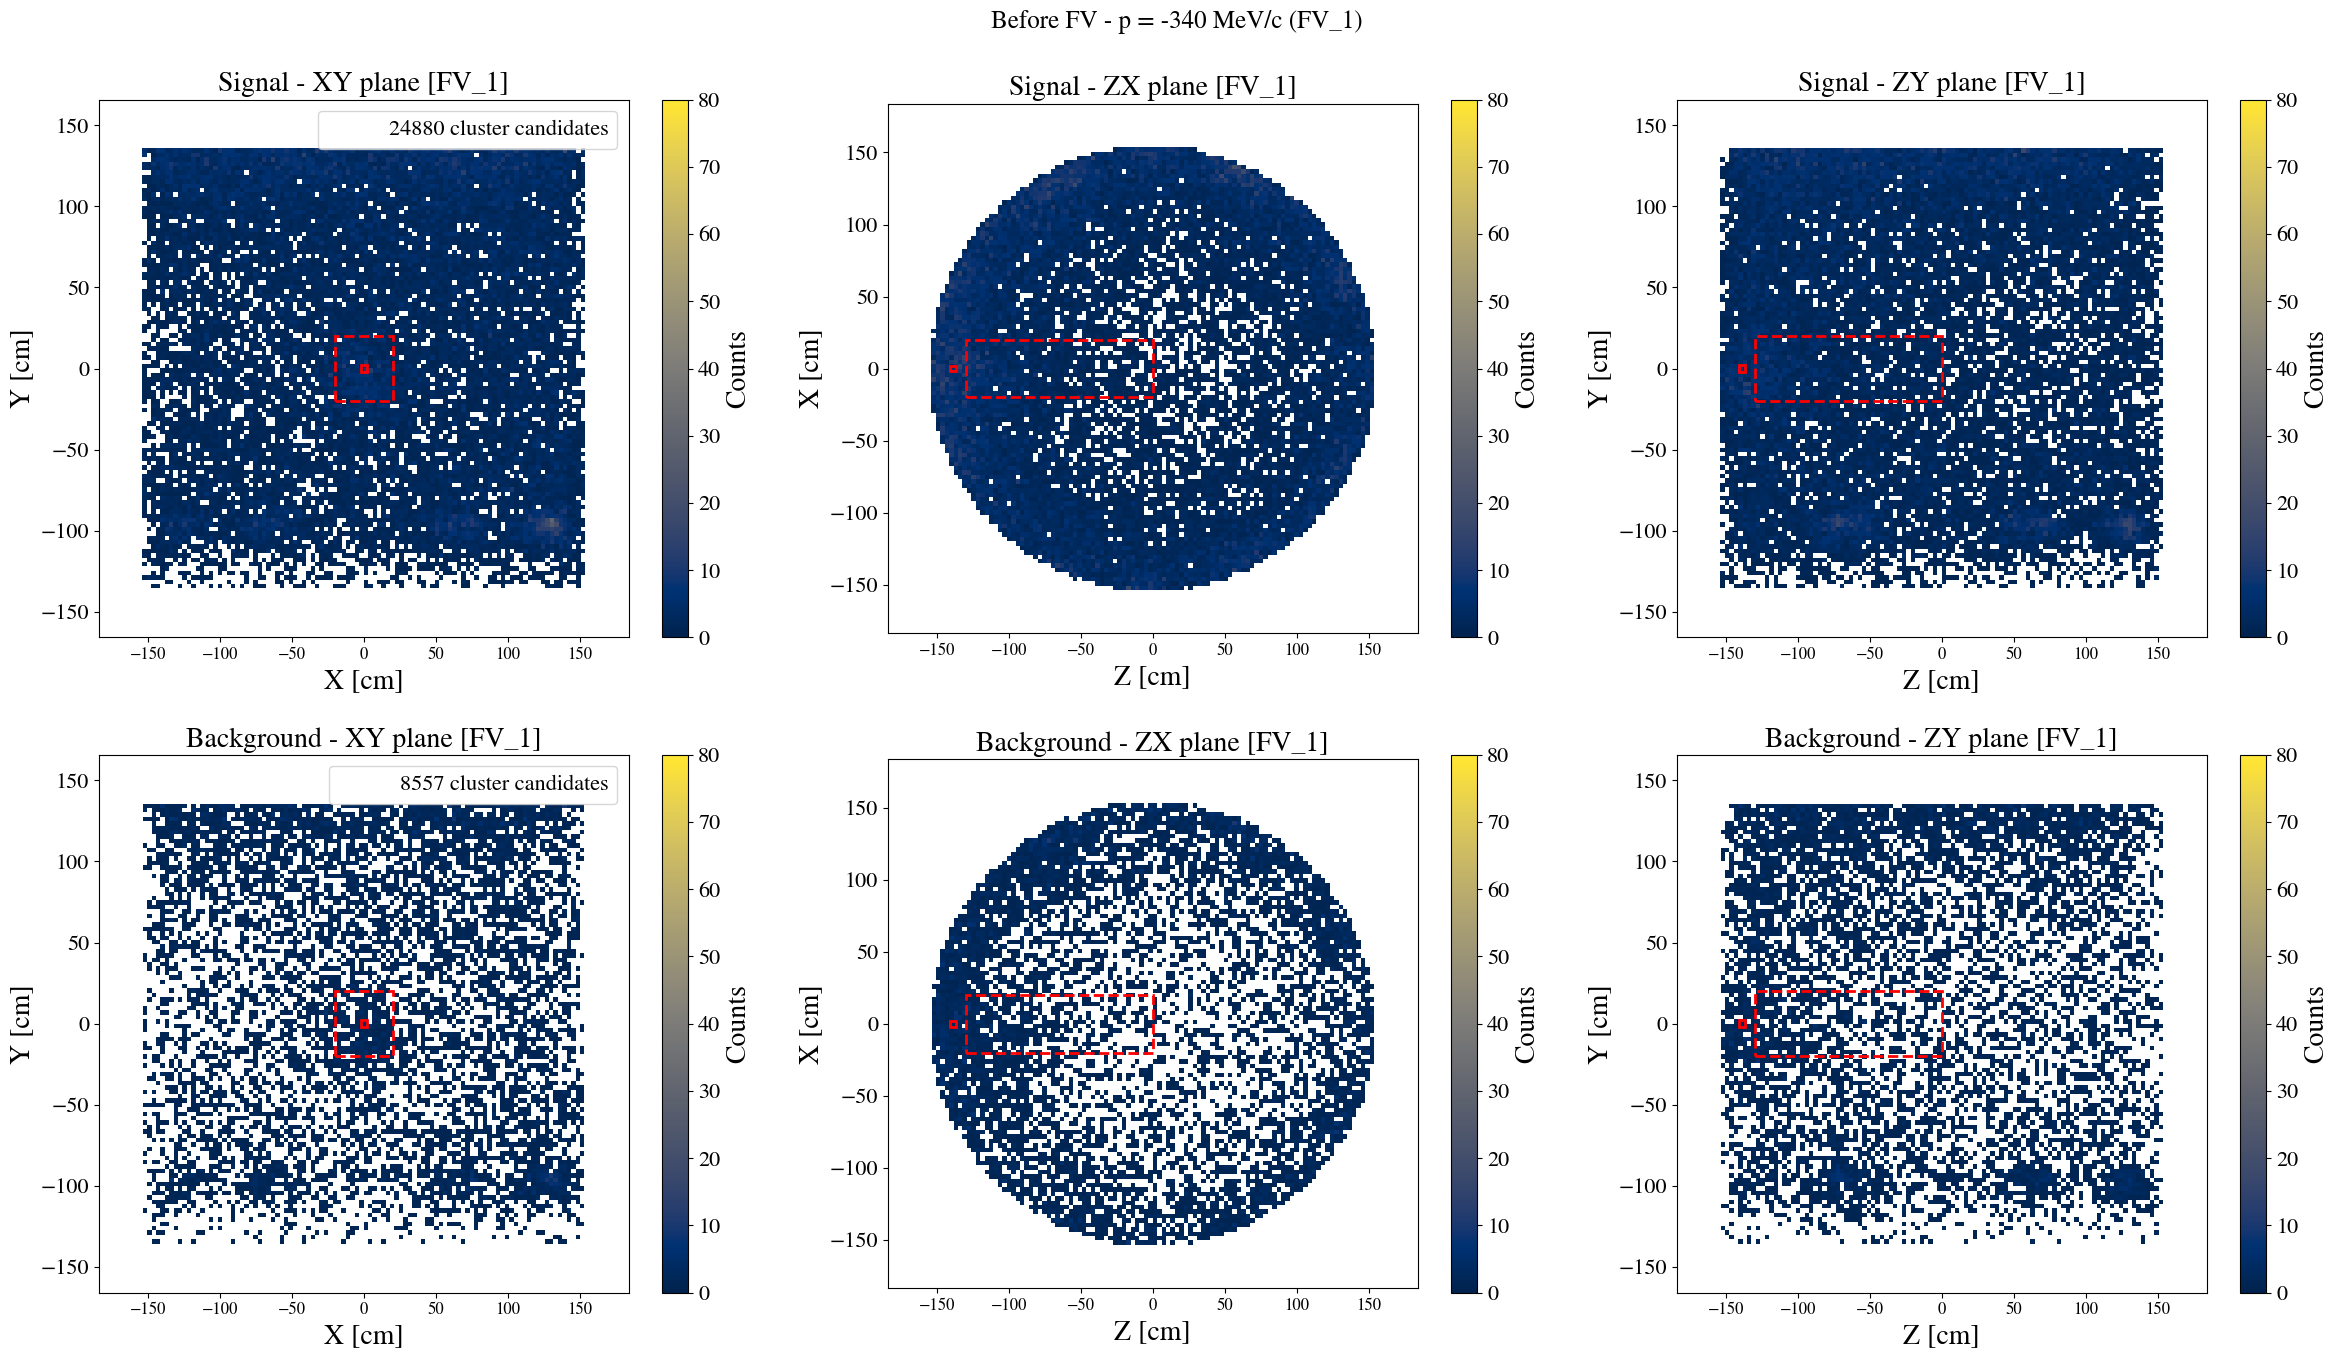

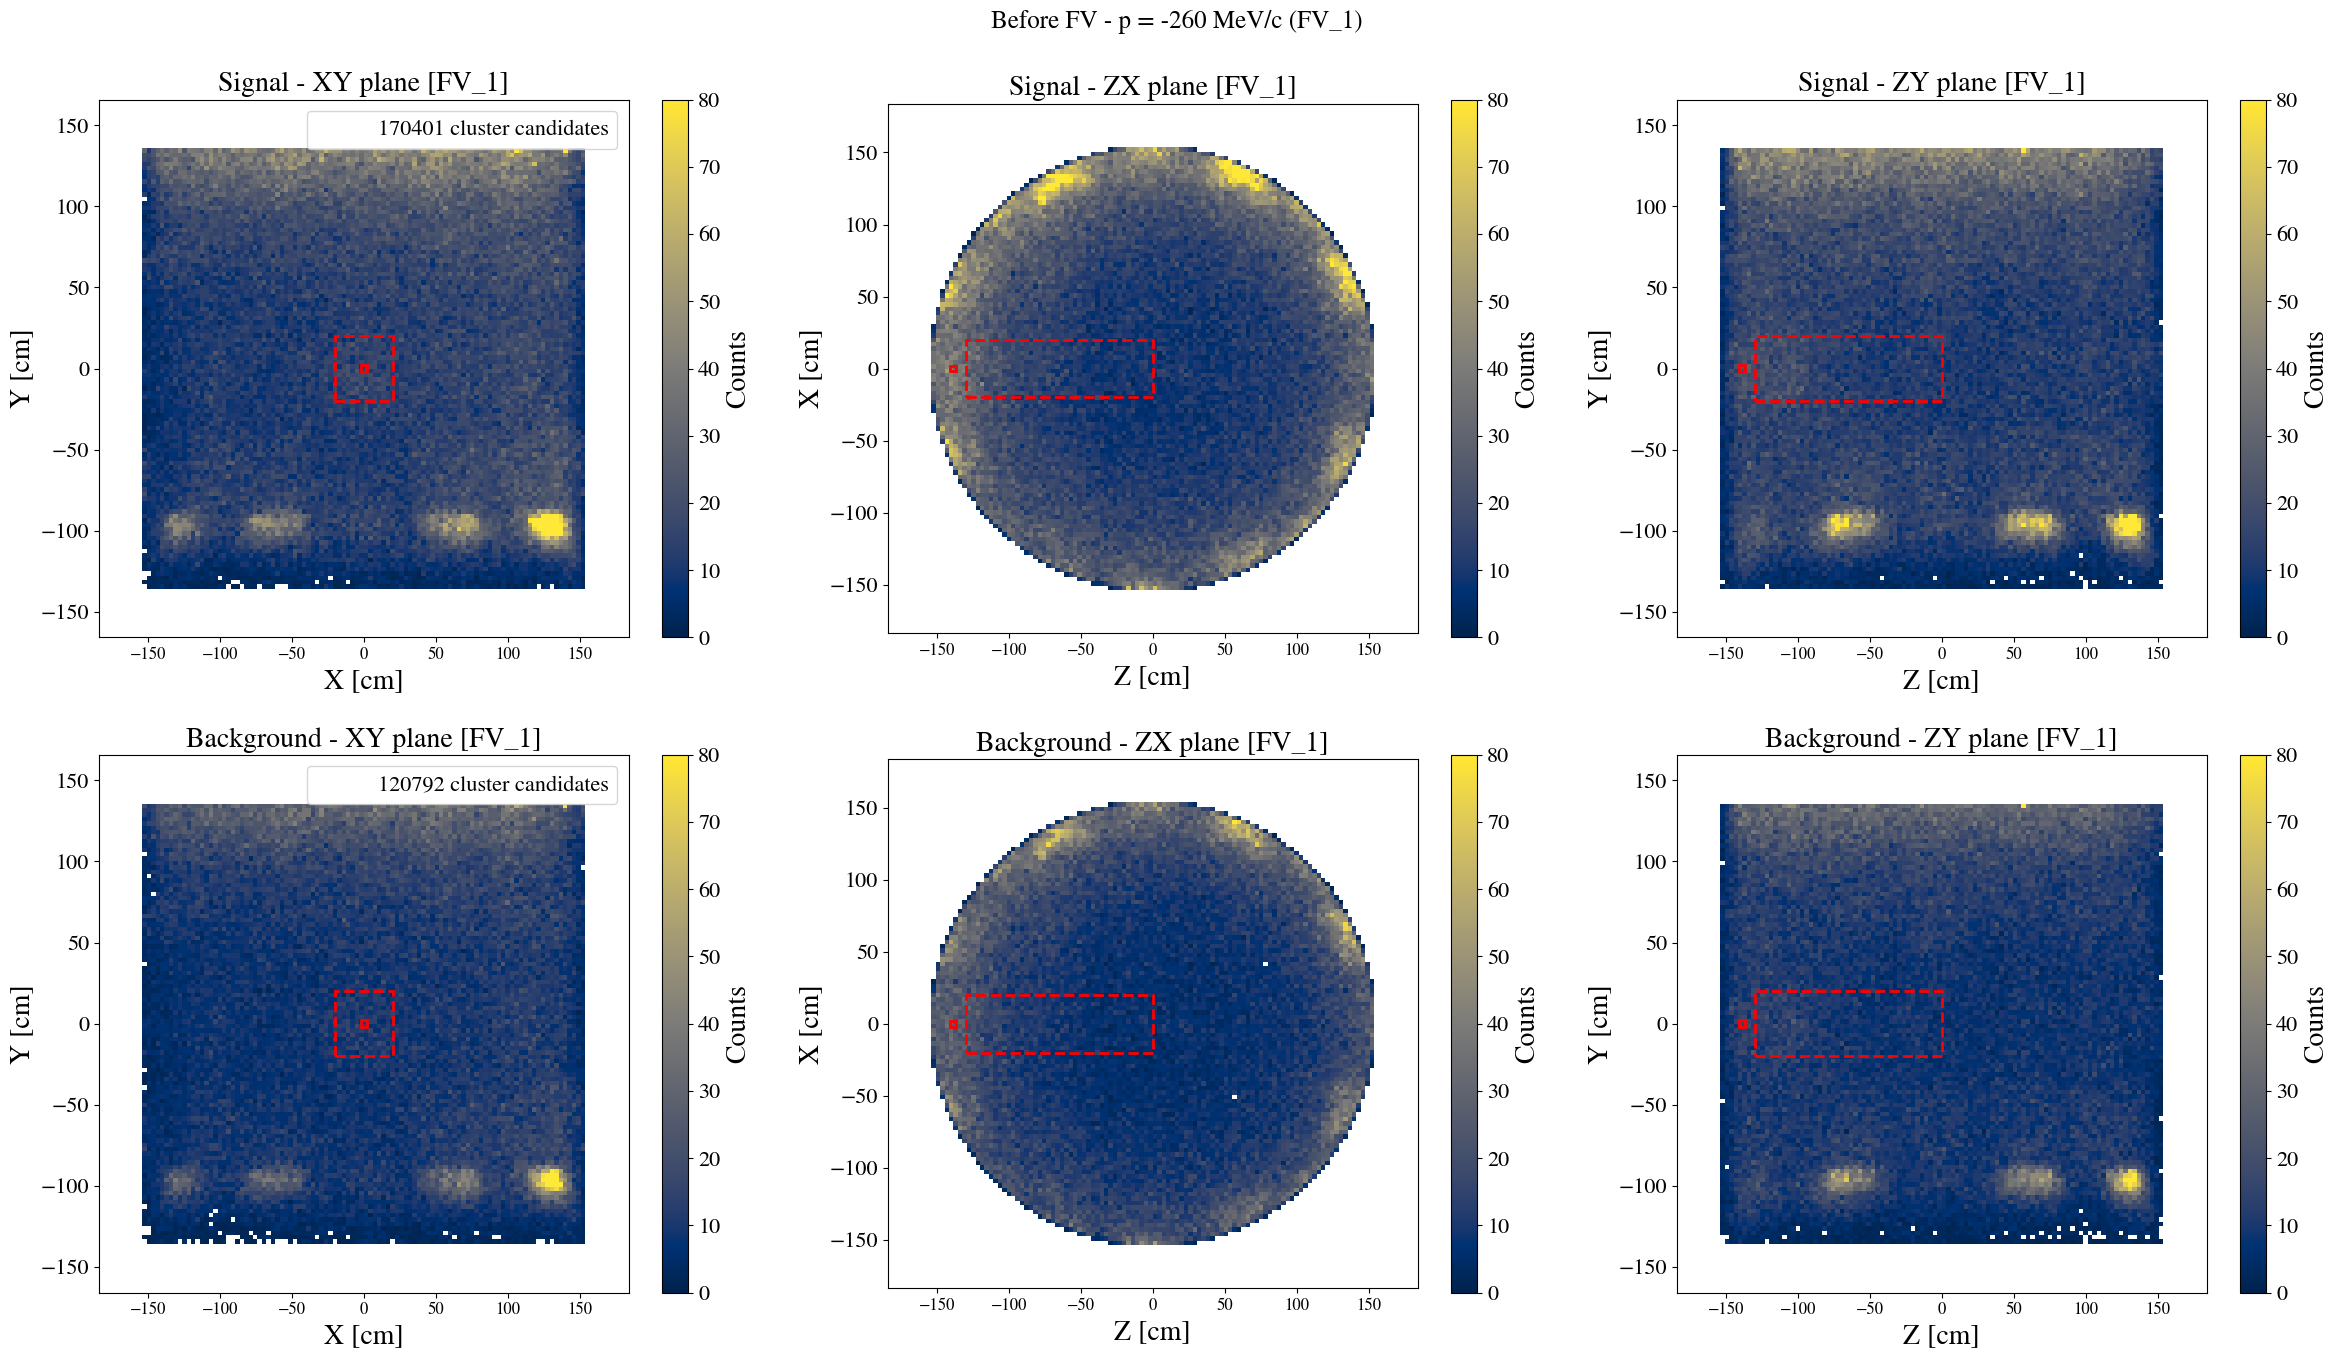

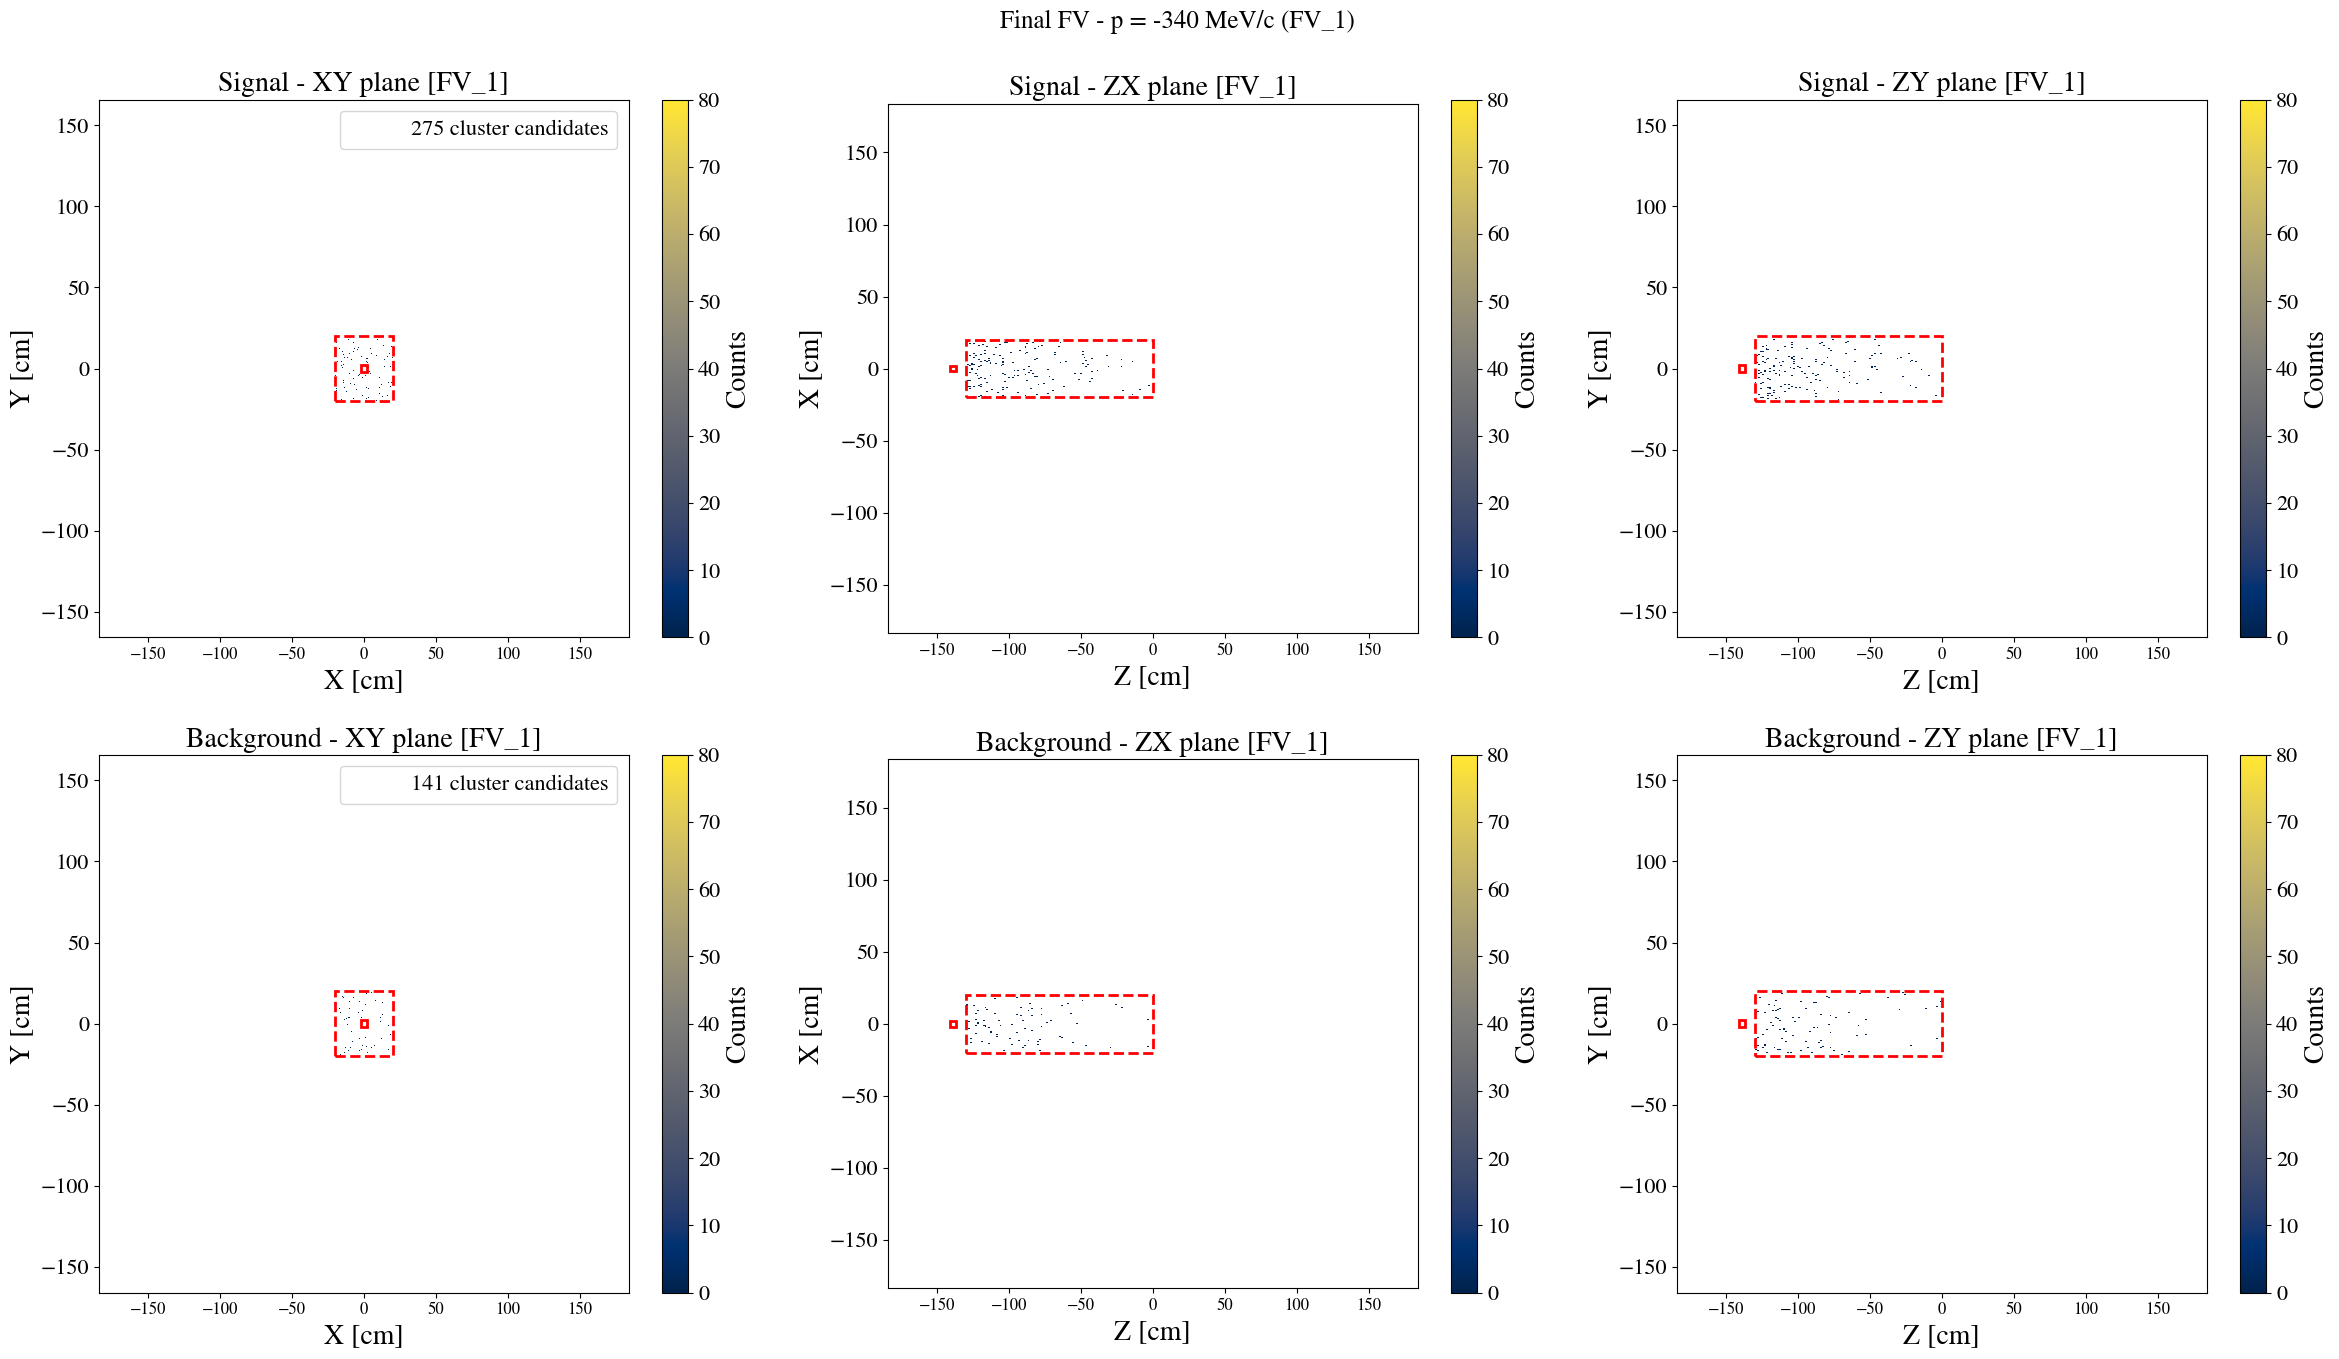

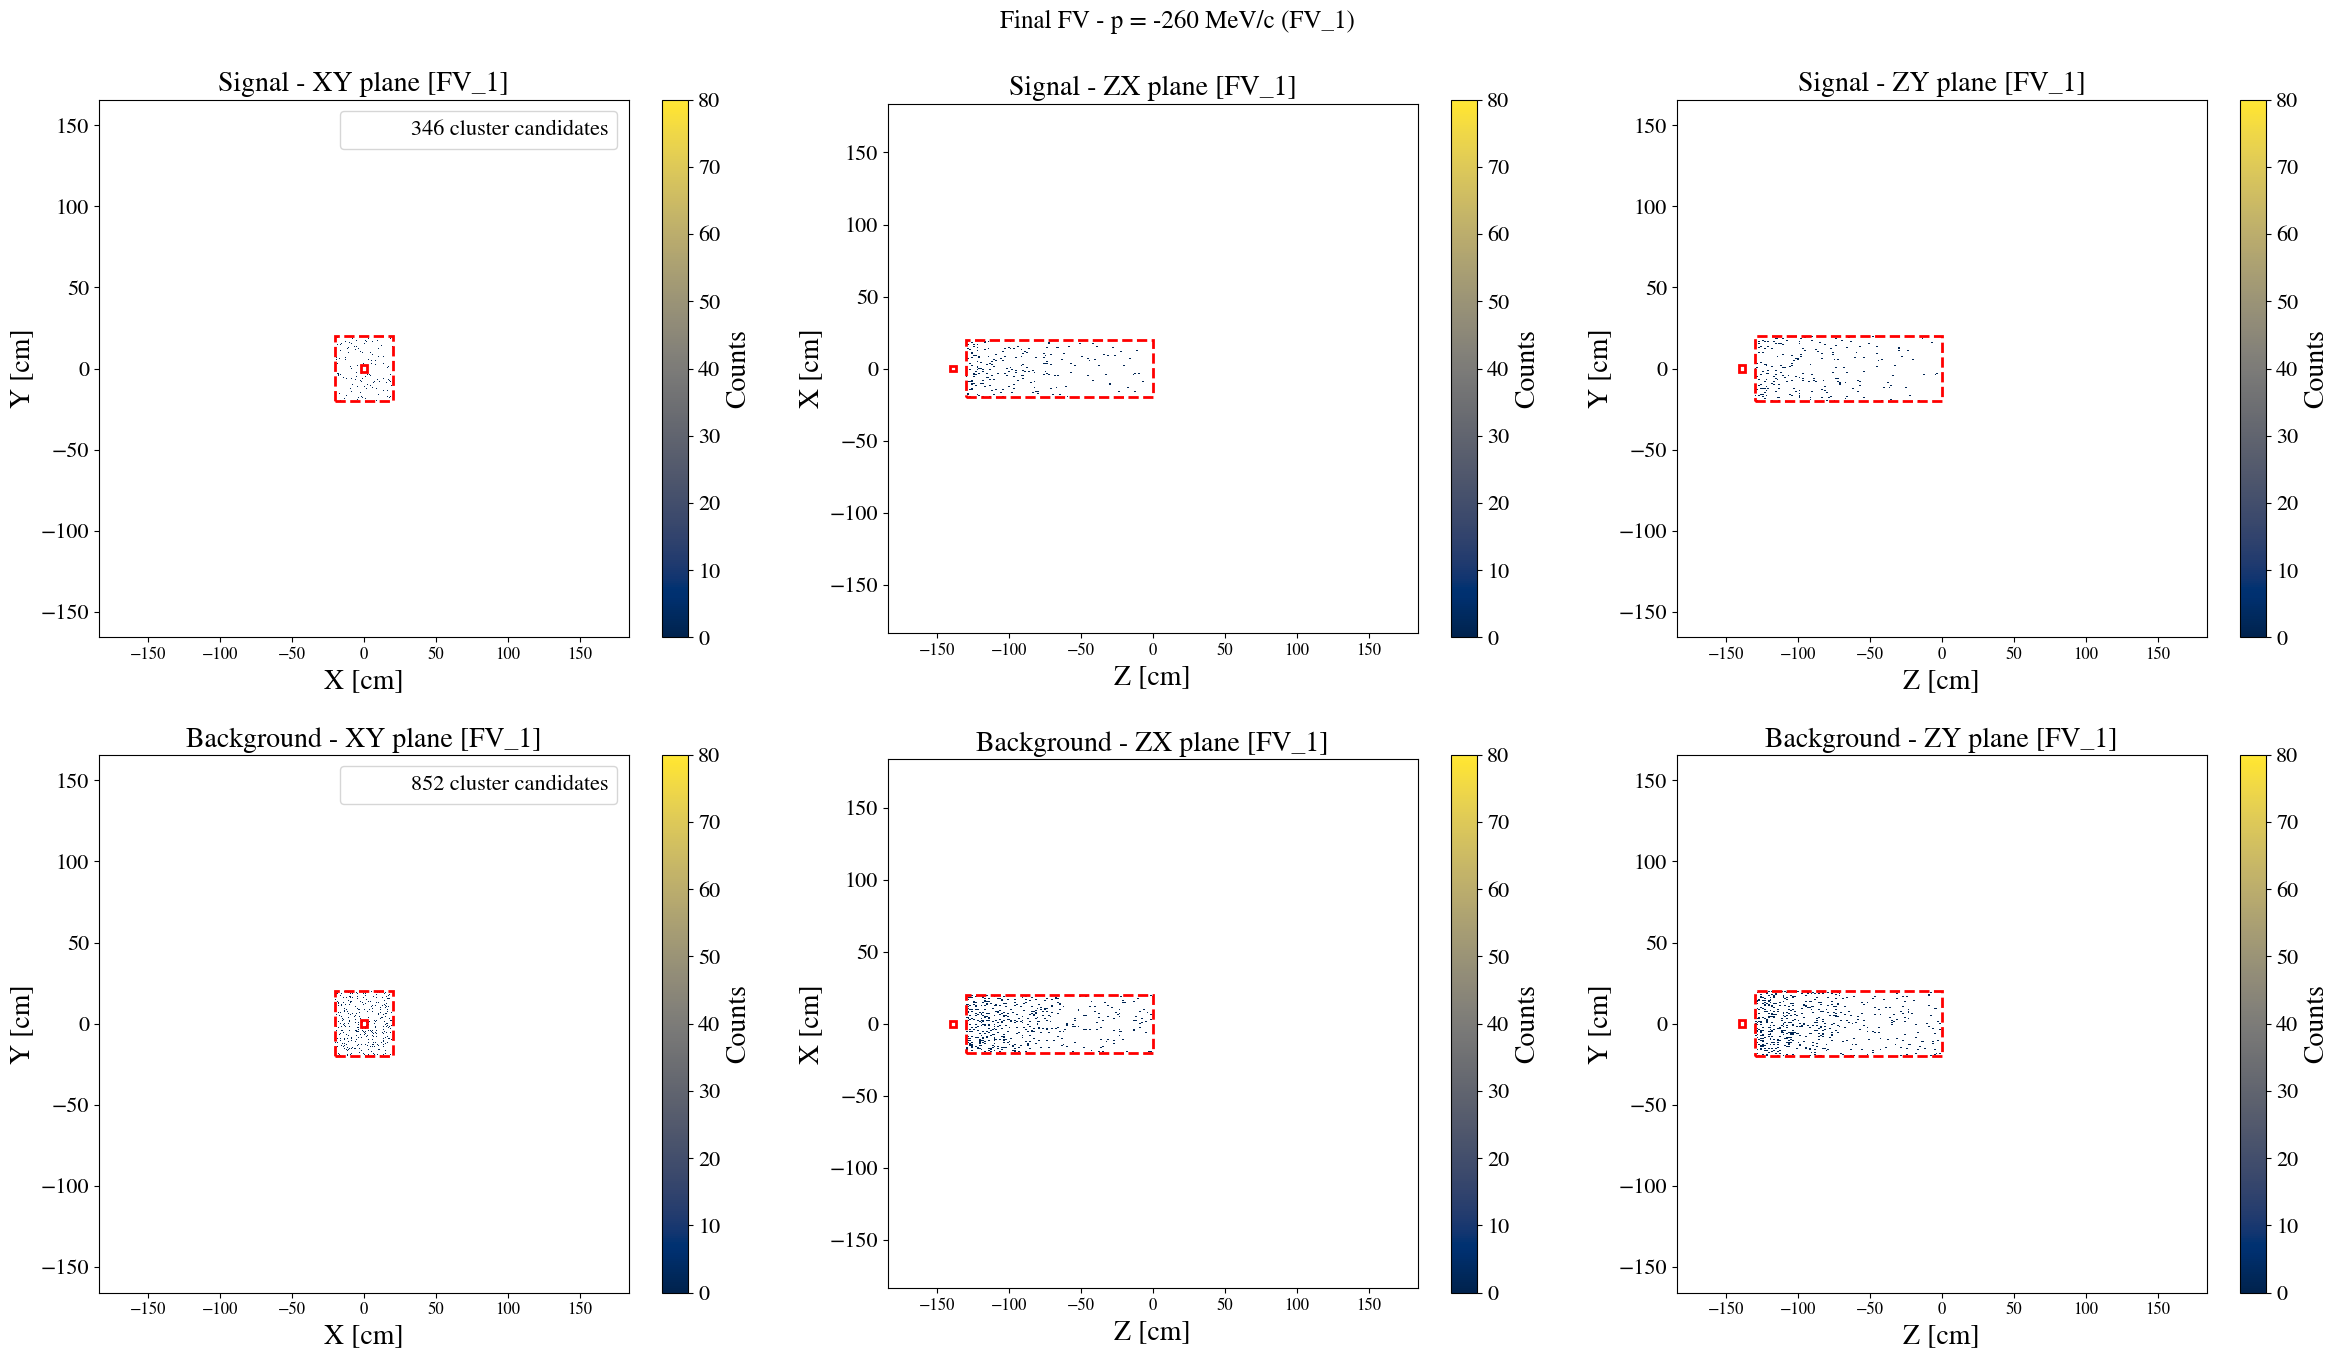

In [32]:
# =====================================================
# Select FV to plot (FV_1 default)
# =====================================================
fv_target = "FV_1"

# =====================================================
# Before FV
# =====================================================

plot_vertex_maps_fv(
    combined[fv_target]["-340 MeV/c"]["signal"]["before"],
    combined[fv_target]["-340 MeV/c"]["background (bkg)"]["before"],
    "Before FV - p = -340 MeV/c",
    fv_target
)

plot_vertex_maps_fv(
    combined[fv_target]["-260 MeV/c"]["signal"]["before"],
    combined[fv_target]["-260 MeV/c"]["background (bkg)"]["before"],
    "Before FV - p = -260 MeV/c",
    fv_target
)

# =====================================================
# After FV (Final FV_1)
# =====================================================

plot_vertex_maps_fv(
    combined[fv_target]["-340 MeV/c"]["signal"]["after"],
    combined[fv_target]["-340 MeV/c"]["background (bkg)"]["after"],
    "Final FV - p = -340 MeV/c",
    fv_target
)

plot_vertex_maps_fv(
    combined[fv_target]["-260 MeV/c"]["signal"]["after"],
    combined[fv_target]["-260 MeV/c"]["background (bkg)"]["after"],
    "Final FV - p = -260 MeV/c",
    fv_target
)

In [33]:
df = pd.read_pickle(
    "/scratch/elena/9Li/results/run1846/processed/FV_4/Final_FV_Li9_clusters_run1846.pkl"
)

print("Total FV:", len(df))

print("fit_success:",
      (df.fit_success).sum())

print("fit_success + chi2<5:",
      (df.fit_success & (df.chi2_ndof < 3)).sum())

Total FV: 259
fit_success: 259
fit_success + chi2<5: 24


Total pion spills (-340 MeV/c): 330.0
Total pion spills (-260 MeV/c): 1196.0


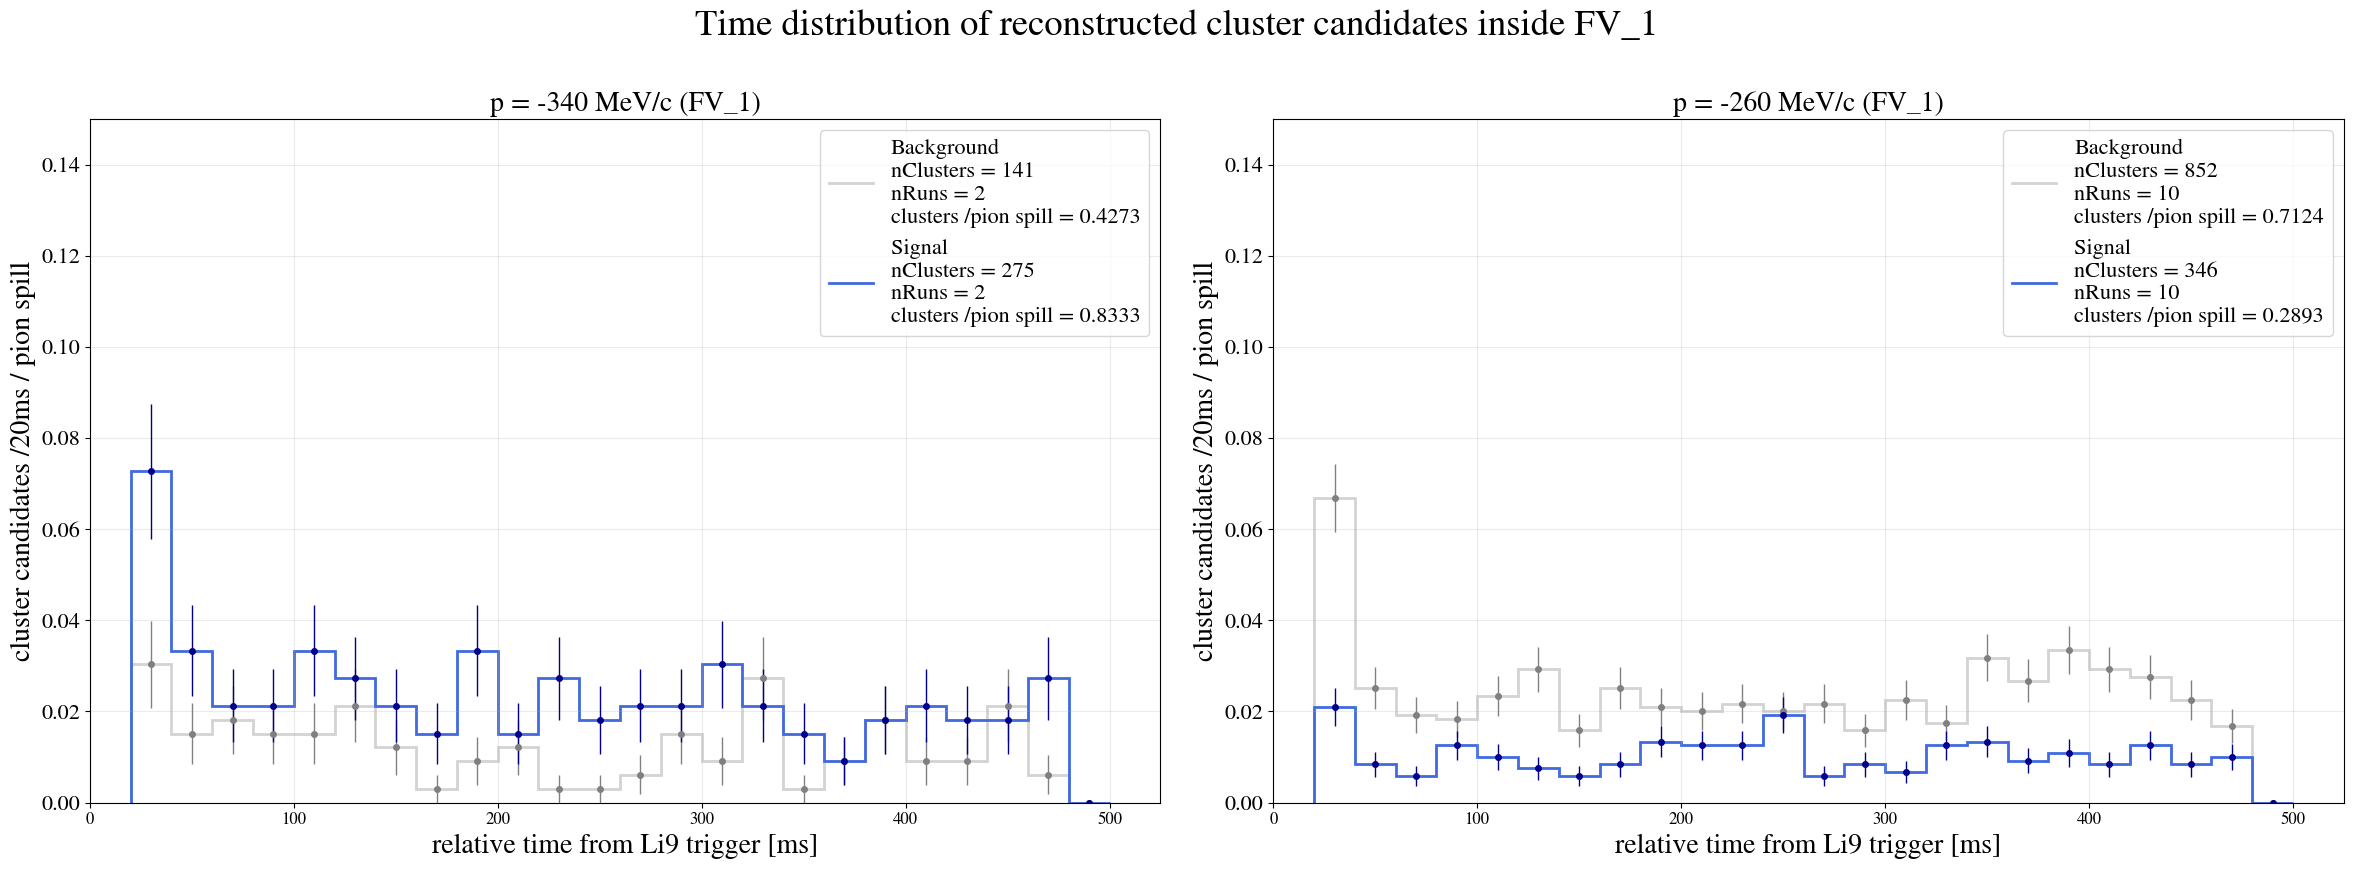

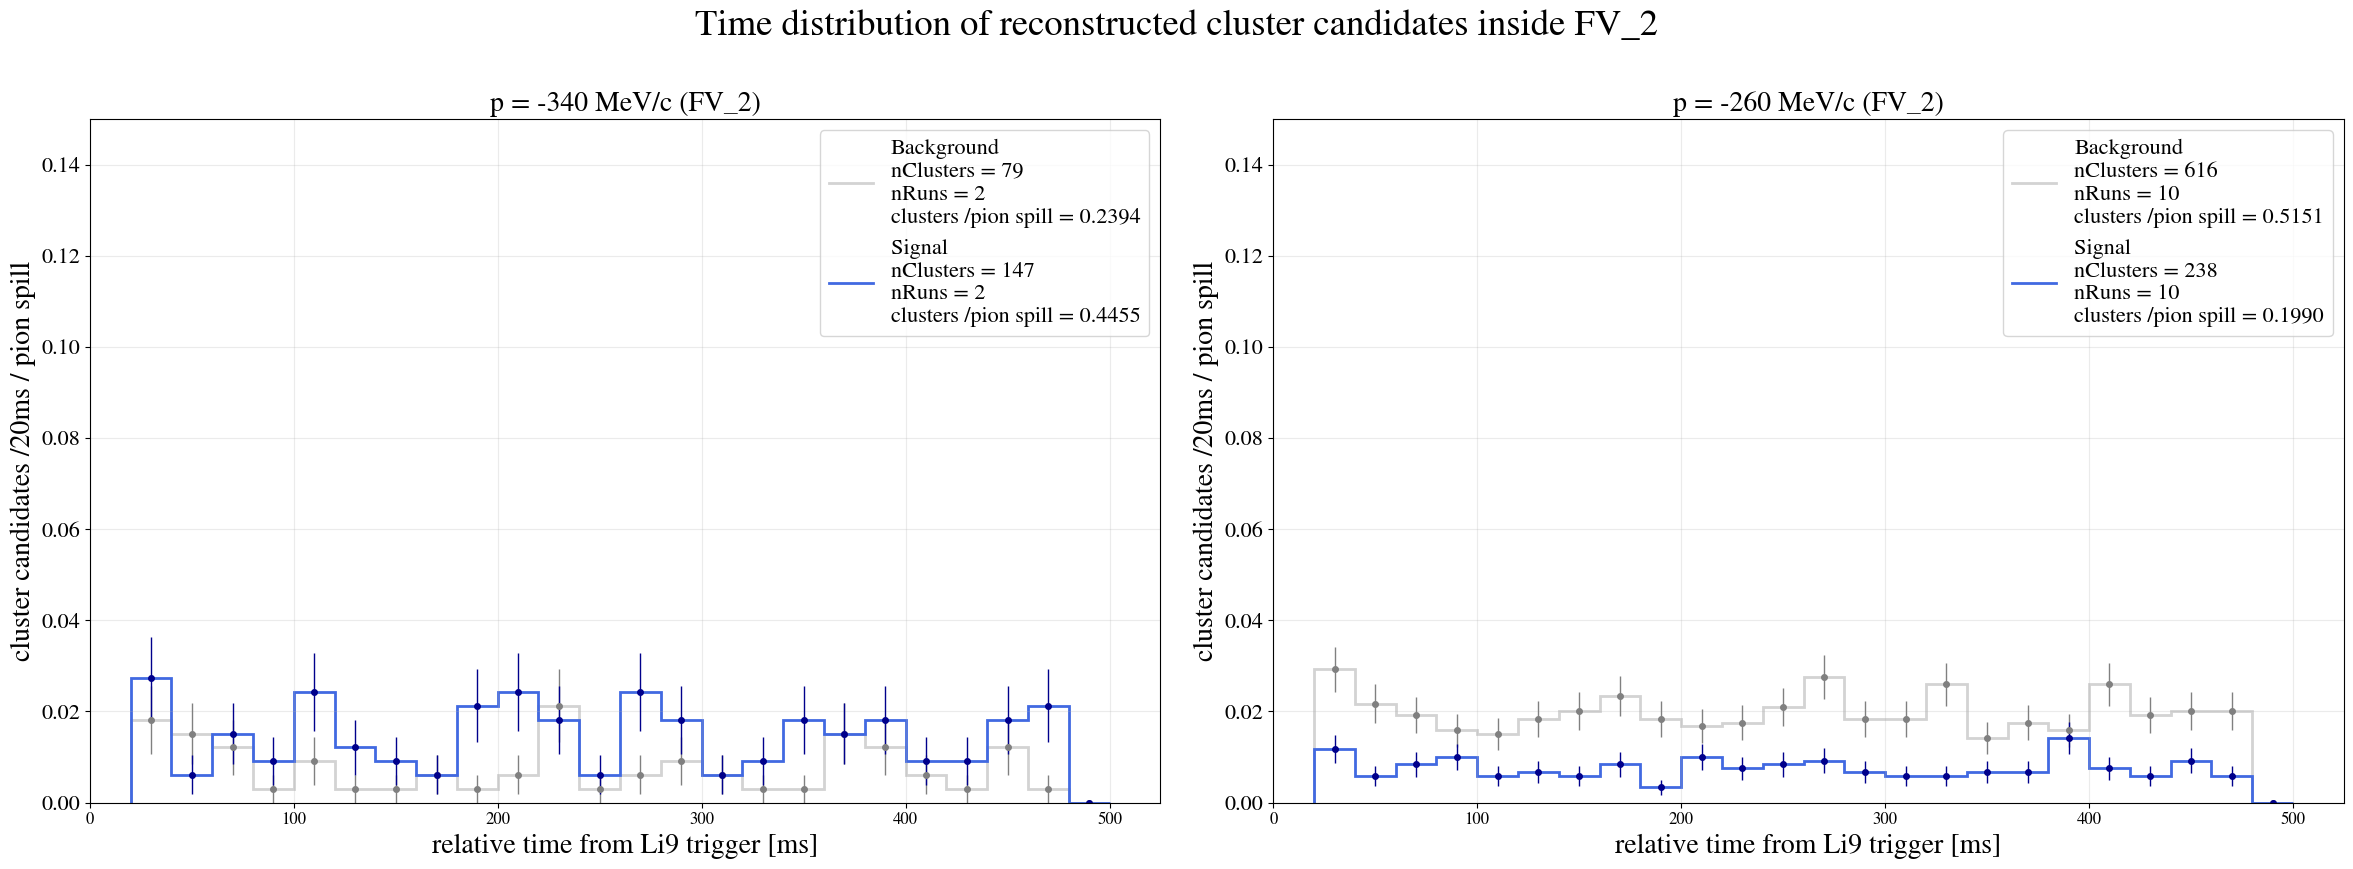

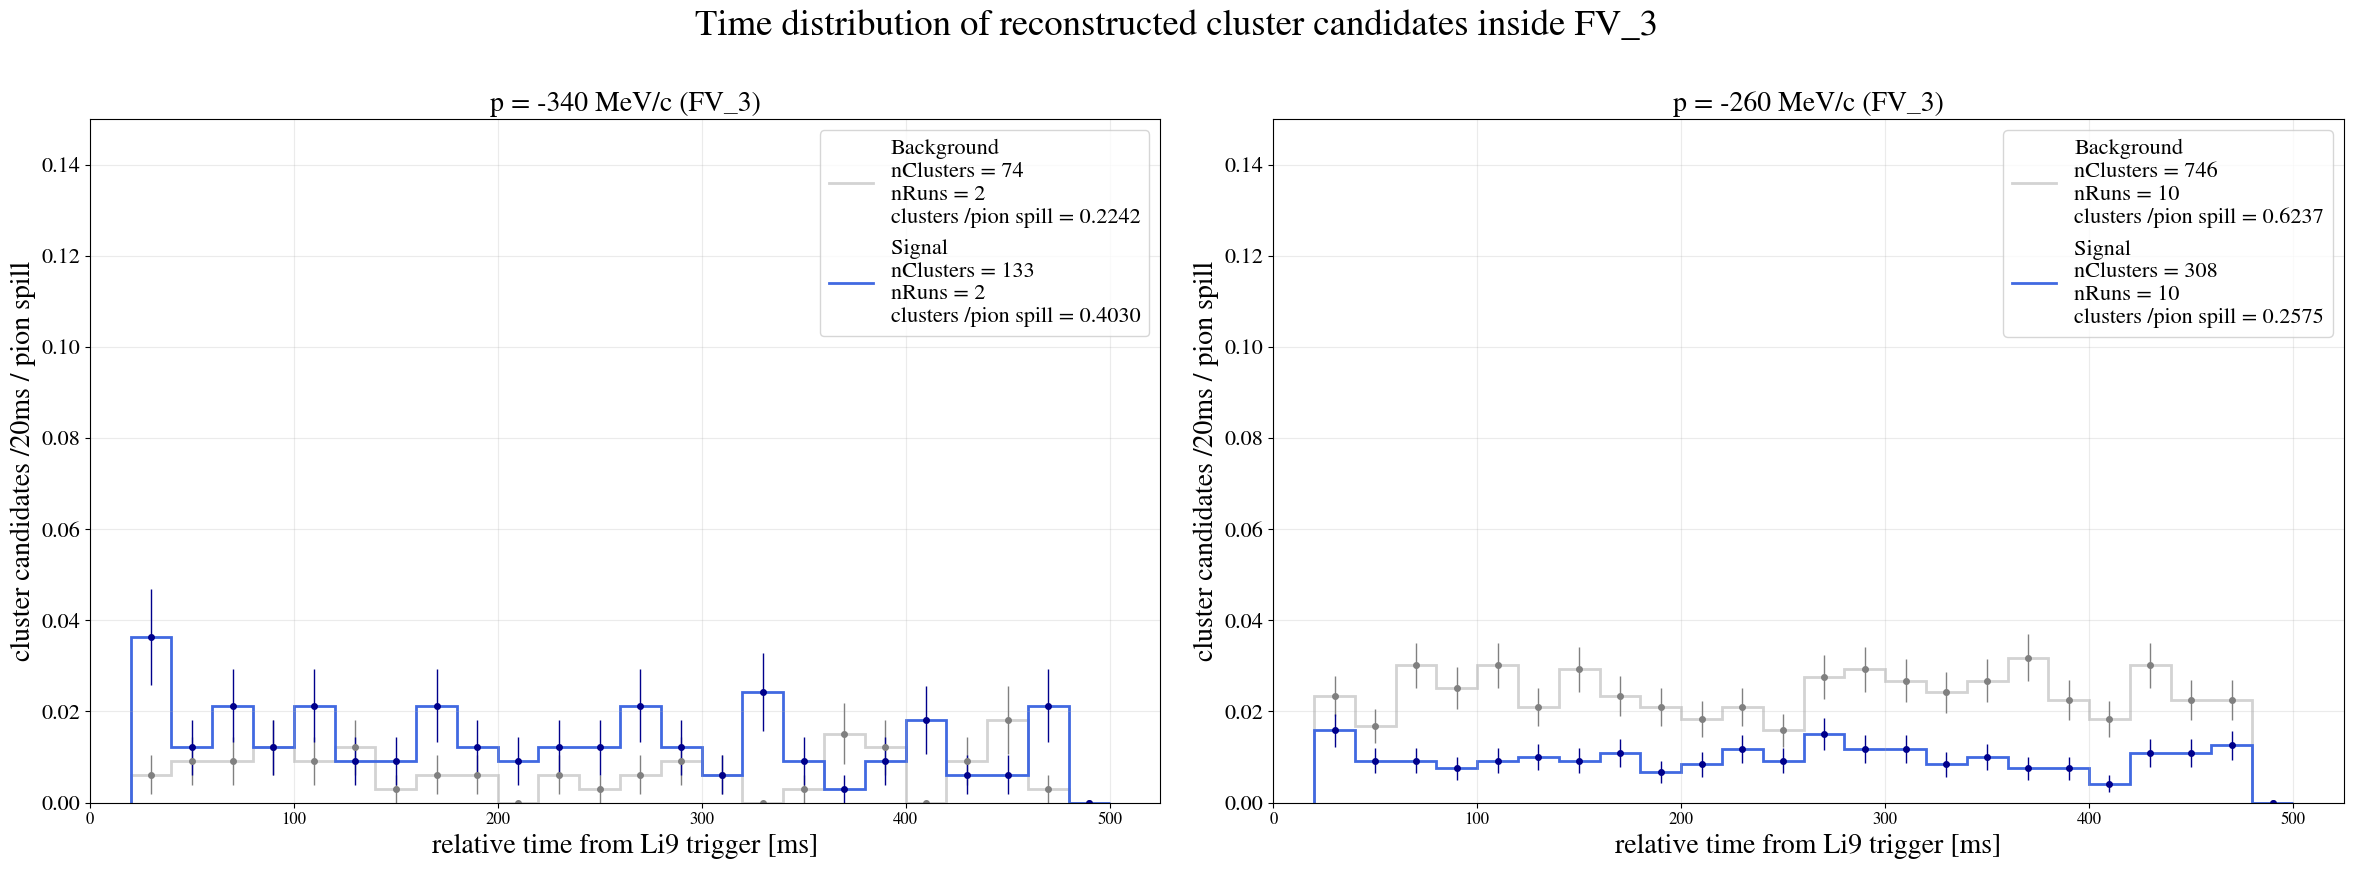

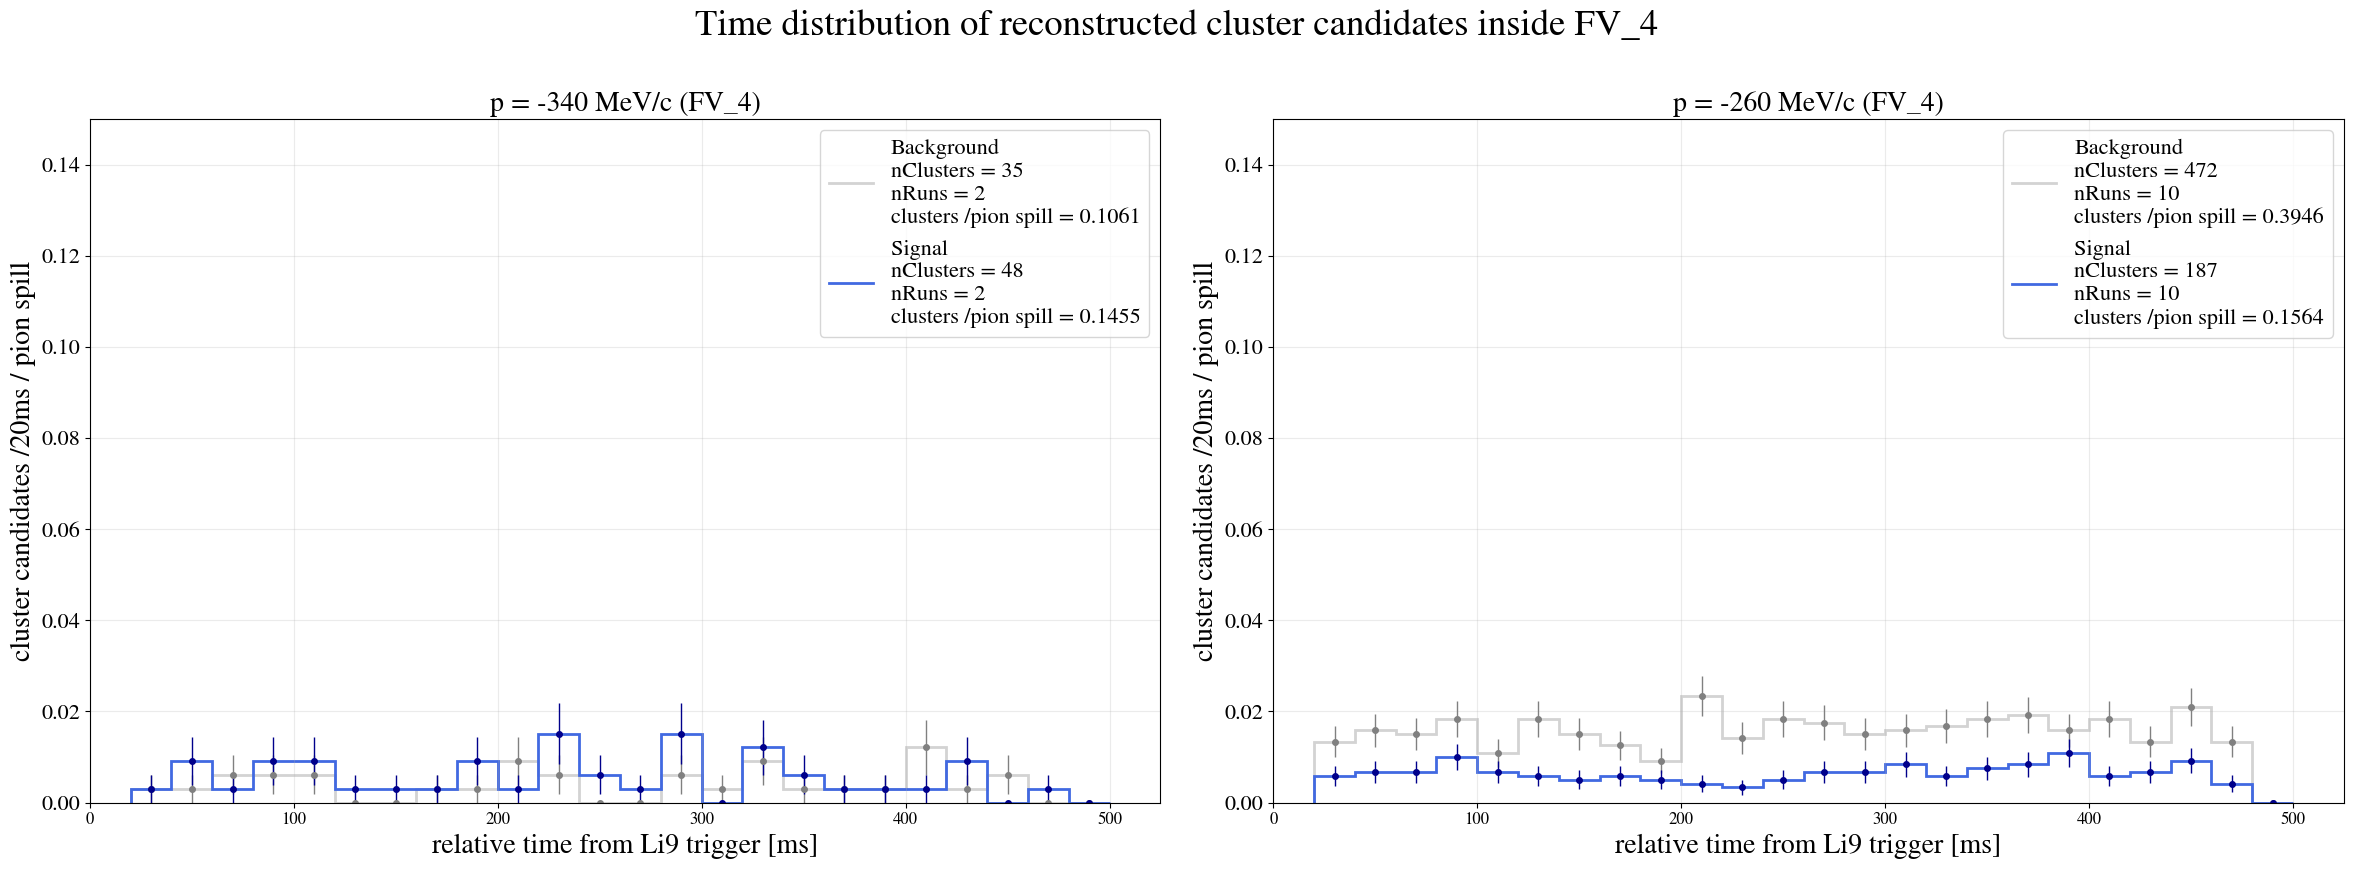

In [34]:
# ==============================================================================
# Time distribution of final FV candidates for ALL 4 Fiducial Volumes
# (all runs combined, normalised by the total number of pion spills)
# ==============================================================================

# --------------------------------------------------------------------------
# Retrieve total number of pion spills from the master table
# --------------------------------------------------------------------------

master_table_path = "/scratch/elena/9Li/results/isotopes_output/master_table_all_runs.csv"

df_master = pd.read_csv(master_table_path)

spills_340_pion = (
    df_master[df_master["Beam p (MeV/c)"] == -340]["N spills with pions"].sum()
)

spills_260_pion = (
    df_master[df_master["Beam p (MeV/c)"] == -260]["N spills with pions"].sum()
)

print(f"Total pion spills (-340 MeV/c): {spills_340_pion}")
print(f"Total pion spills (-260 MeV/c): {spills_260_pion}")


# --------------------------------------------------------------------------
# Number of runs
# --------------------------------------------------------------------------

n_runs_340 = sum(get_beam_momentum(r) == "-340 MeV/c" for r in runs)
n_runs_260 = sum(get_beam_momentum(r) == "-260 MeV/c" for r in runs)


# --------------------------------------------------------------------------
# Plot configuration
# --------------------------------------------------------------------------

rcParams["figure.figsize"] = [24, 9]

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)

time_column = "t_window_start_rel_ns"

fv_tags = ["FV_1", "FV_2", "FV_3", "FV_4"]


# ==============================================================================
# Plot for each Fiducial Volume
# ==============================================================================

for fv_tag in fv_tags:

    df_340_sig_comb = combined[fv_tag]["-340 MeV/c"]["signal"]["after"]
    df_340_bkg_comb = combined[fv_tag]["-340 MeV/c"]["background (bkg)"]["after"]

    df_260_sig_comb = combined[fv_tag]["-260 MeV/c"]["signal"]["after"]
    df_260_bkg_comb = combined[fv_tag]["-260 MeV/c"]["background (bkg)"]["after"]

    fig, axs = plt.subplots(1, 2, sharey=False)

    plot_configs = [

        {
            "df_sig": df_340_sig_comb,
            "df_bkg": df_340_bkg_comb,
            "ax": axs[0],
            "title": f"p = -340 MeV/c ({fv_tag})",
            "num_runs": n_runs_340,
            "n_spills_pion": spills_340_pion,
        },

        {
            "df_sig": df_260_sig_comb,
            "df_bkg": df_260_bkg_comb,
            "ax": axs[1],
            "title": f"p = -260 MeV/c ({fv_tag})",
            "num_runs": n_runs_260,
            "n_spills_pion": spills_260_pion,
        },

    ]

    for config in plot_configs:

        ax = config["ax"]

        ax.set_title(config["title"])

        pion_spills = config["n_spills_pion"]


        def plot_sample(df_plot, sample_label, hist_color, marker_color):

            if df_plot.empty or time_column not in df_plot.columns:
                return False

            time_ms = df_plot[time_column] / 1e6

            counts, edges = np.histogram(time_ms, bins=bins)

            centers = 0.5 * (edges[:-1] + edges[1:])

            counts_scaled = counts / pion_spills
            errors_scaled = np.sqrt(counts) / pion_spills

            label = (
                f"{sample_label}\n"
                f"nClusters = {len(df_plot)}\n"
                f"nRuns = {config['num_runs']}\n"
                f"clusters /pion spill = {len(df_plot)/pion_spills:.4f}"
            )

            ax.stairs(
                counts_scaled,
                edges,
                color=hist_color,
                linewidth=2,
                label=label,
            )

            ax.errorbar(
                centers,
                counts_scaled,
                yerr=errors_scaled,
                fmt="o",
                color=marker_color,
                markersize=4,
                elinewidth=1,
                capsize=0,
                ls="none",
            )

            return True


        has_bkg = plot_sample(
            config["df_bkg"],
            "Background",
            "lightgray",
            "gray",
        )

        has_sig = plot_sample(
            config["df_sig"],
            "Signal",
            "royalblue",
            "darkblue",
        )


        if not has_sig and not has_bkg:

            ax.text(
                0.5,
                0.5,
                f"No candidates inside {fv_tag}",
                transform=ax.transAxes,
                ha="center",
            )

            continue


        ax.set_xlabel("relative time from Li9 trigger [ms]")

        ax.set_ylabel(
            f"cluster candidates /{bin_width}ms / pion spill"
        )

        ax.grid(alpha=0.25)

        ax.set_xlim(0, 525)

        ax.set_ylim(0, 0.15)

        ax.legend(loc="upper right", frameon=True)


    plt.suptitle(
        f"Time distribution of reconstructed cluster candidates inside {fv_tag}"
    )

    plt.tight_layout()

    plt.show()

In [35]:
df = pd.read_pickle(
    "/scratch/elena/9Li/results/run1846/processed/FV_1/Final_FV_Li9_clusters_run1846.pkl"
)

print(len(df))

mask = (
    df.fit_success
    & (df.chi2_ndof < 3)
    & (df.v_x_fine**2 + df.v_z_fine**2 <= 153.7963**2)
    & (np.abs(df.v_y_fine) <= 271.4235/2)
)

print(mask.sum())

585
150


--> [OK] Total pion spills for -340 MeV/c: 330.0
--> [OK] Total pion spills for -260 MeV/c: 1196.0


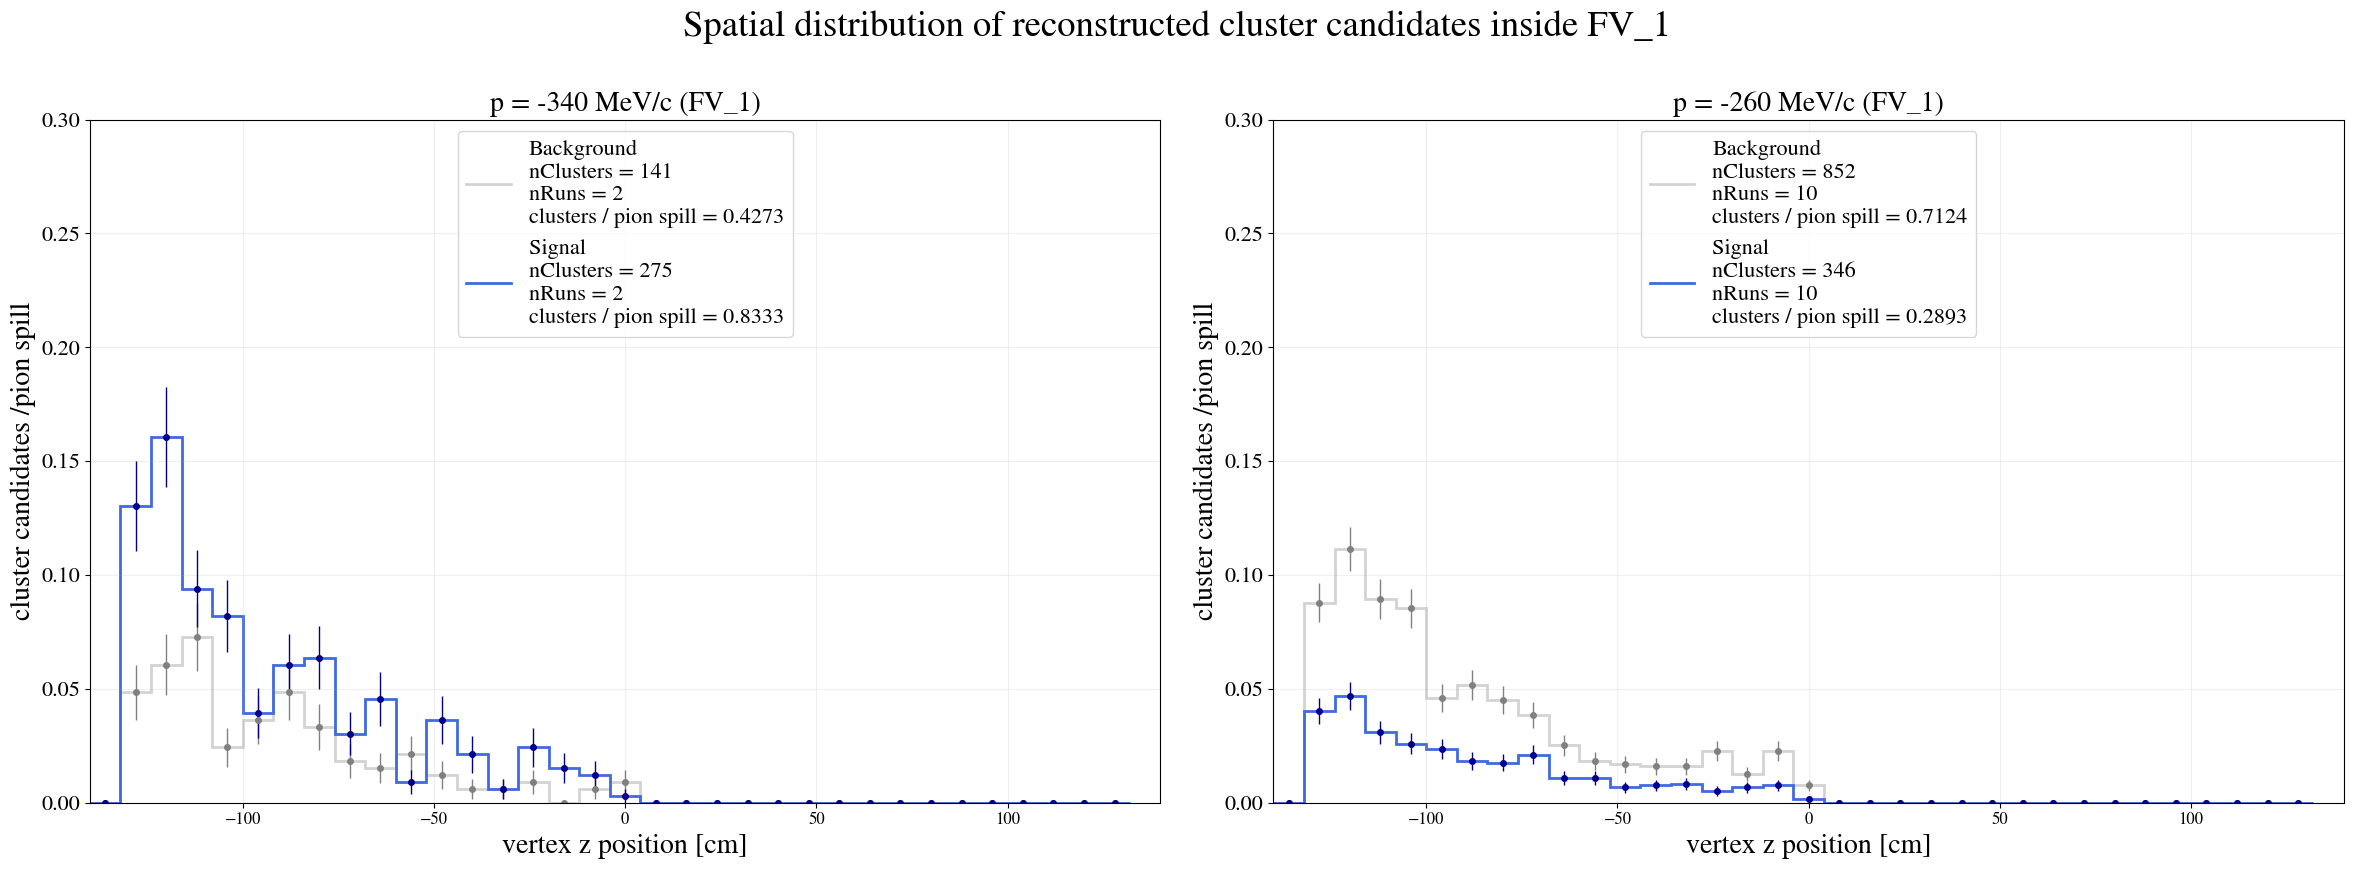

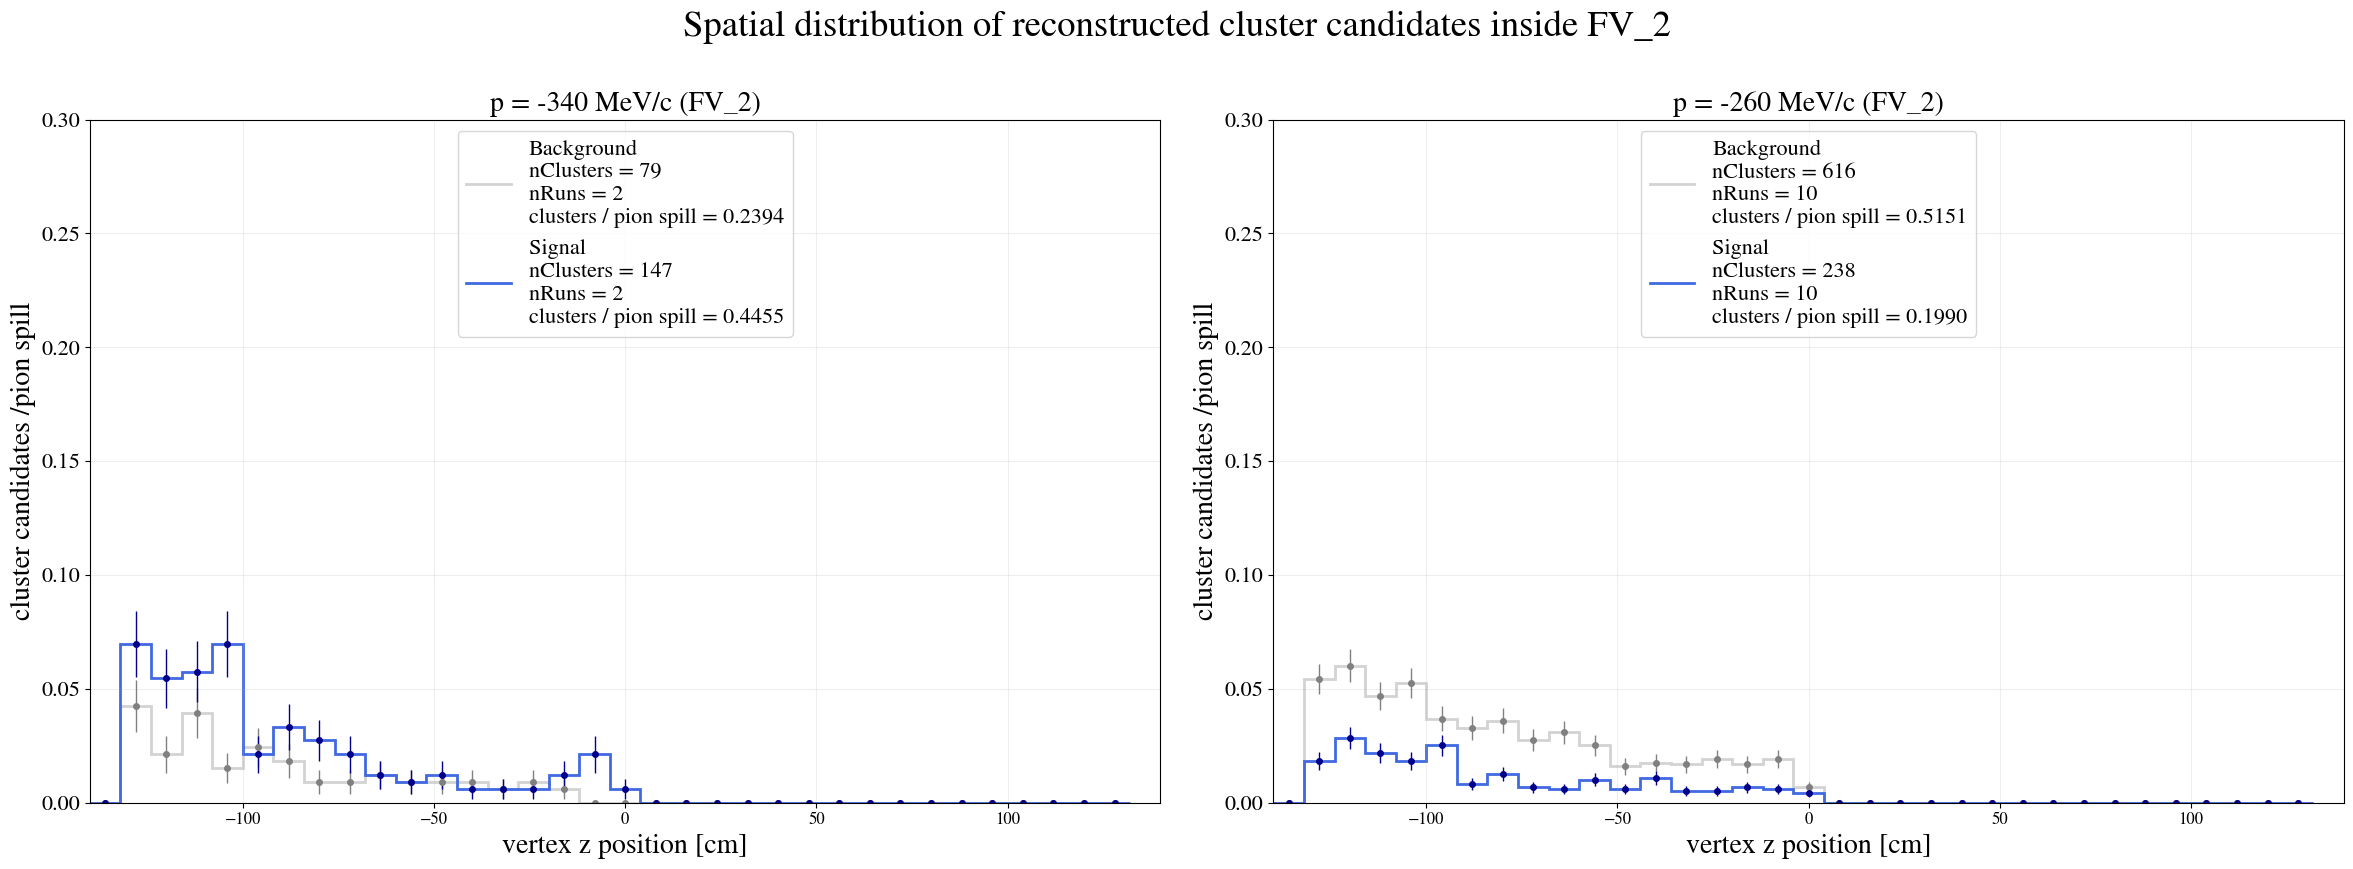

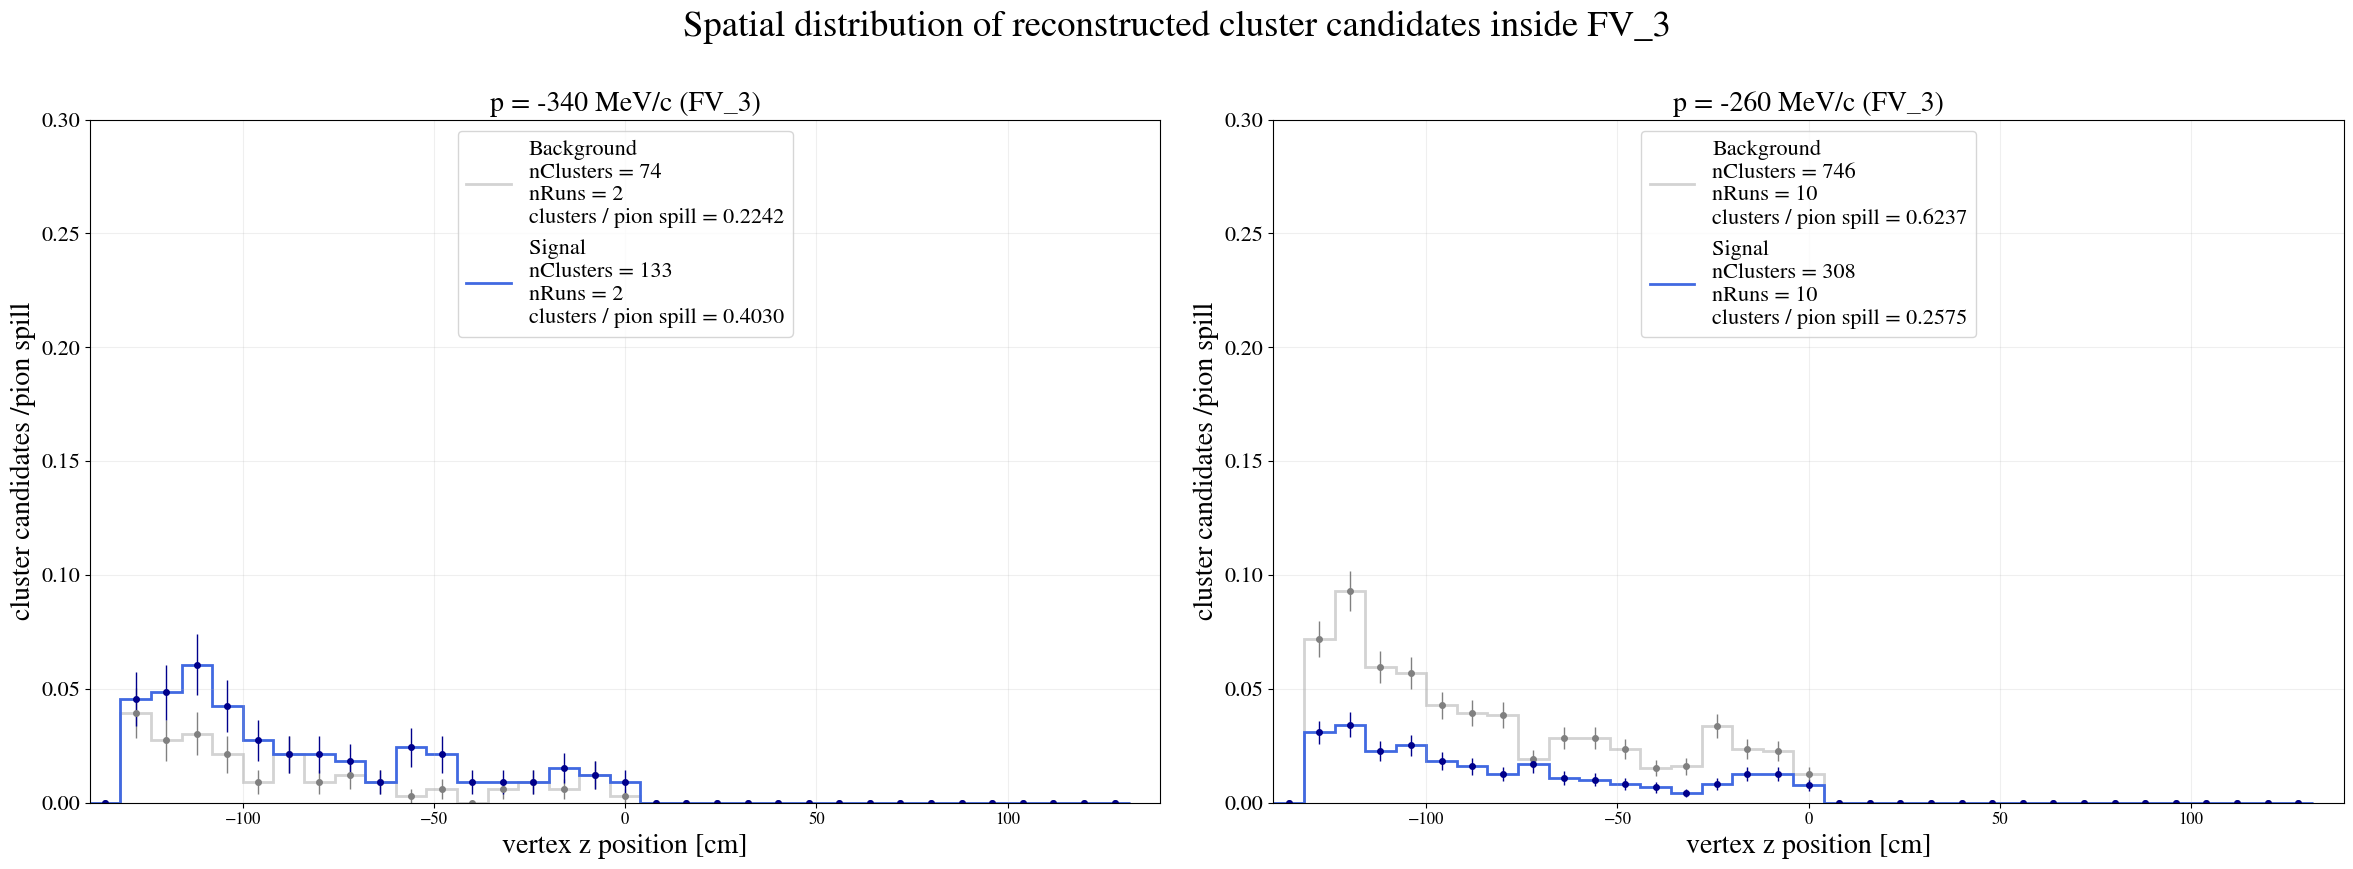

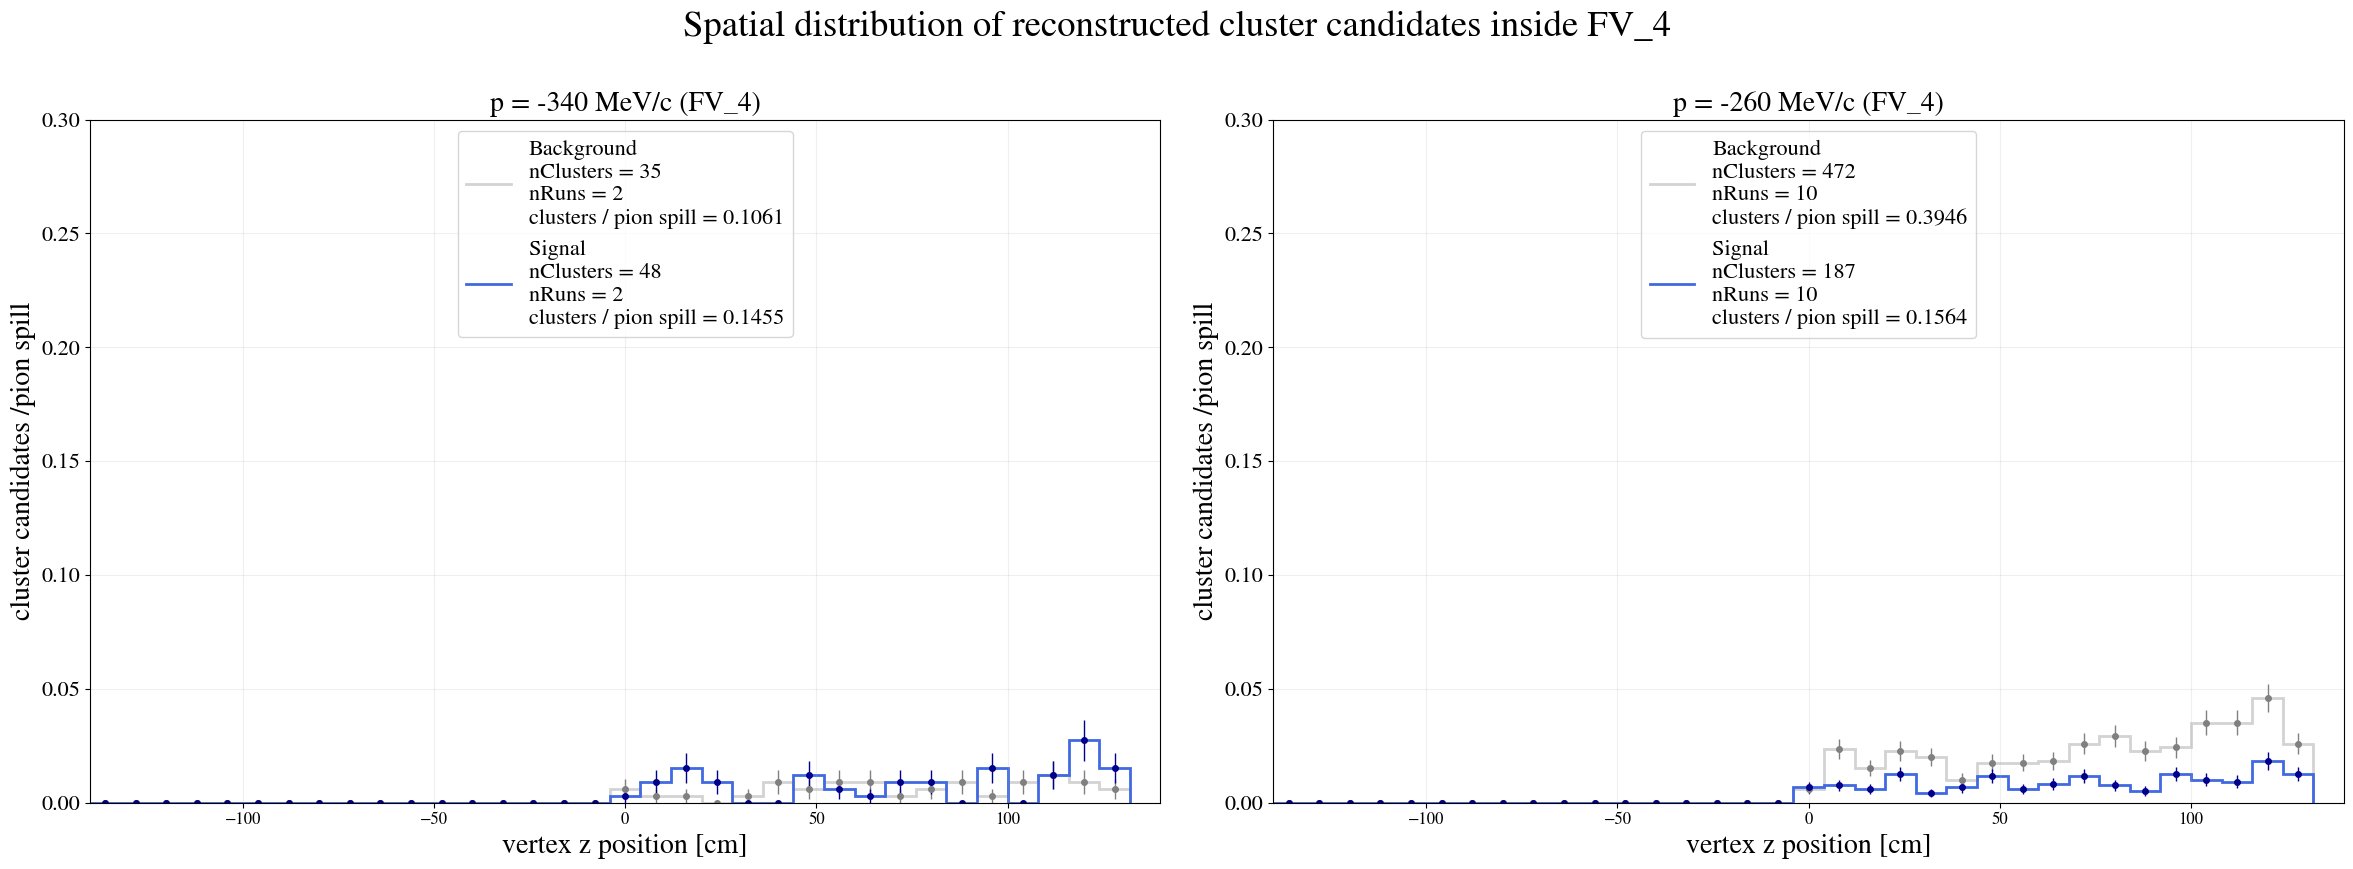

In [36]:
# ==============================================================================
# Spatial distribution of final FV candidates for ALL 4 Fiducial Volumes
# (all runs combined, normalised by the total number of pion spills)
# ==============================================================================

# --------------------------------------------------------------------------
# Retrieve total number of pion spills from the master table
# --------------------------------------------------------------------------

master_table_path = "/scratch/elena/9Li/results/isotopes_output/master_table_all_runs.csv"

if not os.path.exists(master_table_path):
    raise FileNotFoundError(
        f"Master table not found at '{master_table_path}'."
    )

df_master = pd.read_csv(master_table_path)

spills_340_pion = (
    df_master[df_master["Beam p (MeV/c)"] == -340]["N spills with pions"].sum()
)

spills_260_pion = (
    df_master[df_master["Beam p (MeV/c)"] == -260]["N spills with pions"].sum()
)

print(f"--> [OK] Total pion spills for -340 MeV/c: {spills_340_pion}")
print(f"--> [OK] Total pion spills for -260 MeV/c: {spills_260_pion}")


# --------------------------------------------------------------------------
# Number of runs
# --------------------------------------------------------------------------

n_runs_340 = sum(get_beam_momentum(r) == "-340 MeV/c" for r in runs)
n_runs_260 = sum(get_beam_momentum(r) == "-260 MeV/c" for r in runs)


# --------------------------------------------------------------------------
# Plot configuration
# --------------------------------------------------------------------------

rcParams["figure.figsize"] = [24, 9]

bins_z = np.arange(-140, 140, 8)
z_column = "v_z_fine"

fv_tags = ["FV_1", "FV_2", "FV_3", "FV_4"]


# ==============================================================================
# Plot for each Fiducial Volume
# ==============================================================================

for fv_tag in fv_tags:

    df_340_sig_comb = combined[fv_tag]["-340 MeV/c"]["signal"]["after"]
    df_340_bkg_comb = combined[fv_tag]["-340 MeV/c"]["background (bkg)"]["after"]

    df_260_sig_comb = combined[fv_tag]["-260 MeV/c"]["signal"]["after"]
    df_260_bkg_comb = combined[fv_tag]["-260 MeV/c"]["background (bkg)"]["after"]

    fig, axs = plt.subplots(1, 2, sharey=False)

    plot_configs = [

        {
            "df_sig": df_340_sig_comb,
            "df_bkg": df_340_bkg_comb,
            "ax": axs[0],
            "title": f"p = -340 MeV/c ({fv_tag})",
            "num_runs": n_runs_340,
            "n_spills_pion": spills_340_pion,
        },

        {
            "df_sig": df_260_sig_comb,
            "df_bkg": df_260_bkg_comb,
            "ax": axs[1],
            "title": f"p = -260 MeV/c ({fv_tag})",
            "num_runs": n_runs_260,
            "n_spills_pion": spills_260_pion,
        }

    ]

    for config in plot_configs:

        ax = config["ax"]

        ax.set_title(config["title"])

        pion_spills = config["n_spills_pion"]


        def plot_sample(df_plot, sample_label, hist_color, marker_color):

            if df_plot.empty or z_column not in df_plot.columns:
                return False

            counts, bin_edges = np.histogram(
                df_plot[z_column],
                bins=bins_z
            )

            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

            counts_scaled = counts / pion_spills
            errors_scaled = np.sqrt(counts) / pion_spills

            label = (
                f"{sample_label}\n"
                f"nClusters = {len(df_plot)}\n"
                f"nRuns = {config['num_runs']}\n"
                f"clusters / pion spill = {len(df_plot)/pion_spills:.4f}"
            )

            ax.stairs(
                counts_scaled,
                bin_edges,
                color=hist_color,
                linewidth=2,
                label=label,
            )

            ax.errorbar(
                bin_centers,
                counts_scaled,
                yerr=errors_scaled,
                fmt="o",
                color=marker_color,
                markersize=4,
                capsize=0,
                elinewidth=1,
                ls="none",
            )

            return True


        has_bkg = plot_sample(
            config["df_bkg"],
            "Background",
            "lightgray",
            "gray",
        )

        has_sig = plot_sample(
            config["df_sig"],
            "Signal",
            "royalblue",
            "darkblue",
        )


        if not has_sig and not has_bkg:

            ax.text(
                0.5,
                0.5,
                f"No selected candidates inside {fv_tag}",
                transform=ax.transAxes,
                ha="center",
            )

            continue


        ax.set_xlabel("vertex z position [cm]")

        ax.set_ylabel(
            "cluster candidates /pion spill"
        )

        ax.grid(True, alpha=0.2)

        ax.set_xlim(-140, 140)  # Ajustado a [-140, 140] para cubrir adecuadamente el rango de FV_4 (z > 0)

        ax.set_ylim(0, 0.3)

        ax.legend(loc="upper center", frameon=True)


    plt.suptitle(
        f"Spatial distribution of reconstructed cluster candidates inside {fv_tag}"
    )

    plt.tight_layout()

    plt.show()

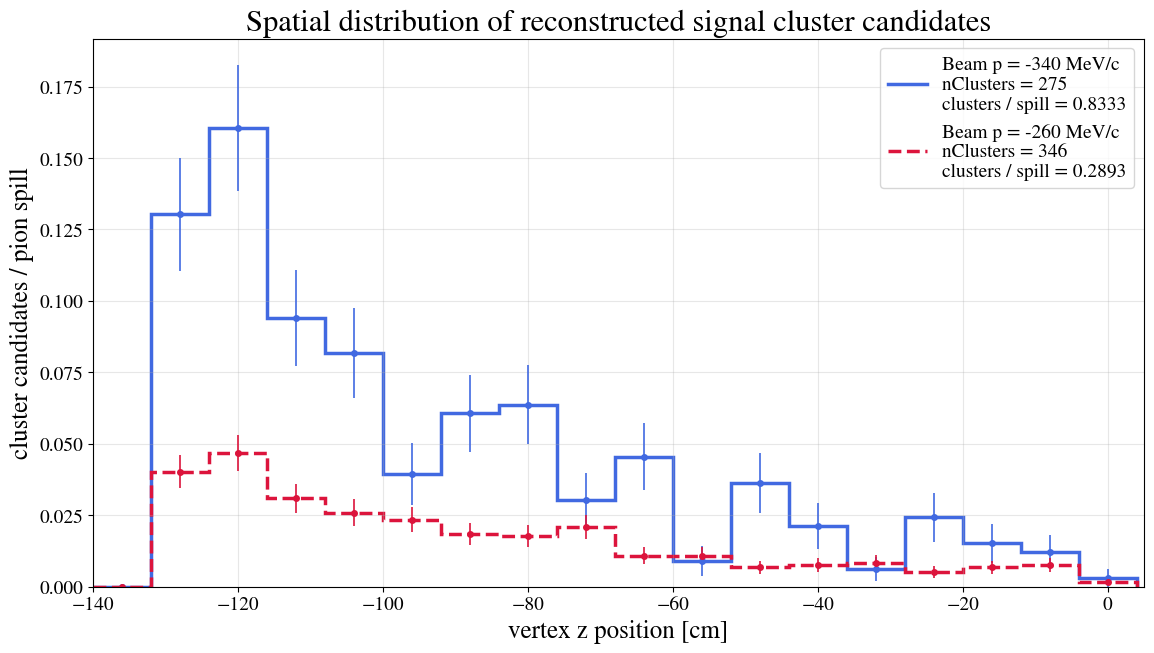

In [37]:
bins_z = np.arange(-140, 10, 8)

plt.figure(figsize=(12, 7))

# Extraer los DataFrames de Signal despues de FV únicamente para FV_1
df_340_sig_comb = combined["FV_1"]["-340 MeV/c"]["signal"]["after"]
df_260_sig_comb = combined["FV_1"]["-260 MeV/c"]["signal"]["after"]


def plot_hist_with_errors(df, spills, color, linestyle, label):

    # Histogram
    counts, edges = np.histogram(df["v_z_fine"], bins=bins_z)

    centers = 0.5 * (edges[:-1] + edges[1:])

    counts_scaled = counts / spills
    errors_scaled = np.sqrt(counts) / spills

    # Histogram outline
    plt.stairs(
        counts_scaled,
        edges,
        color=color,
        linestyle=linestyle,
        linewidth=2.5,
        label=label,
    )

    # Poisson error bars
    plt.errorbar(
        centers,
        counts_scaled,
        yerr=errors_scaled,
        fmt="o",
        color=color,
        markersize=4,
        elinewidth=1.2,
        capsize=0,
        ls="none",
    )


plot_hist_with_errors(
    df_340_sig_comb,
    spills_340_pion,
    color="royalblue",
    linestyle="-",
    label=(
        f"Beam p = -340 MeV/c\n"
        f"nClusters = {len(df_340_sig_comb)}\n"
        f"clusters / spill = {len(df_340_sig_comb)/spills_340_pion:.4f}"
    ),
)

plot_hist_with_errors(
    df_260_sig_comb,
    spills_260_pion,
    color="crimson",
    linestyle="--",
    label=(
        f"Beam p = -260 MeV/c\n"
        f"nClusters = {len(df_260_sig_comb)}\n"
        f"clusters / spill = {len(df_260_sig_comb)/spills_260_pion:.4f}"
    ),
)

plt.xlabel("vertex z position [cm]", fontsize=18)
plt.ylabel("cluster candidates / pion spill", fontsize=18)

plt.title(
    "Spatial distribution of reconstructed signal cluster candidates",
    fontsize=22,
)

plt.xlim(-140, 5)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)

plt.legend(fontsize=14)

plt.tight_layout()

plt.show()

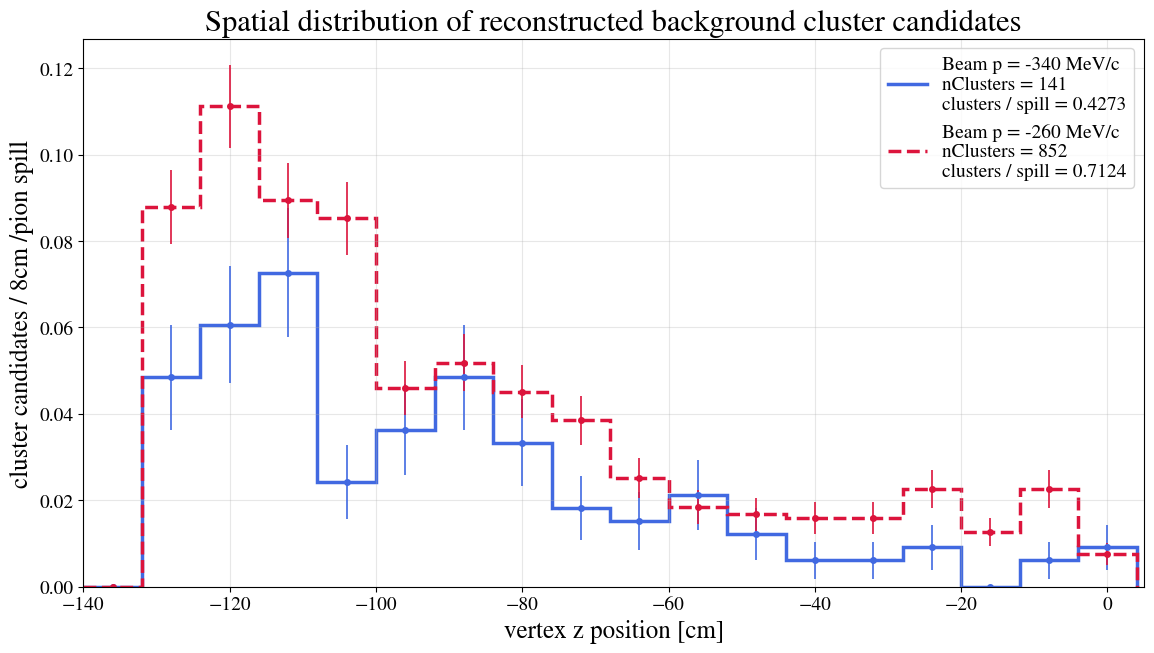

In [38]:
bins_z = np.arange(-140, 10, 8)

plt.figure(figsize=(12, 7))

# Extraer los DataFrames de Background despues de FV únicamente para FV_1
df_340_bkg_comb = combined["FV_1"]["-340 MeV/c"]["background (bkg)"]["after"]
df_260_bkg_comb = combined["FV_1"]["-260 MeV/c"]["background (bkg)"]["after"]


def plot_hist_with_errors(df, spills, color, linestyle, label):

    counts, edges = np.histogram(
        df["v_z_fine"],
        bins=bins_z
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    counts_scaled = counts / spills
    errors_scaled = np.sqrt(counts) / spills

    # Histogram
    plt.stairs(
        counts_scaled,
        edges,
        color=color,
        linestyle=linestyle,
        linewidth=2.5,
        label=label,
    )

    # Poisson uncertainties
    plt.errorbar(
        centers,
        counts_scaled,
        yerr=errors_scaled,
        fmt="o",
        color=color,
        markersize=4,
        elinewidth=1.2,
        capsize=0,
        ls="none",
    )


plot_hist_with_errors(
    df_340_bkg_comb,
    spills_340_pion,
    color="royalblue",
    linestyle="-",
    label=(
        f"Beam p = -340 MeV/c\n"
        f"nClusters = {len(df_340_bkg_comb)}\n"
        f"clusters / spill = "
        f"{len(df_340_bkg_comb)/spills_340_pion:.4f}"
    ),
)

plot_hist_with_errors(
    df_260_bkg_comb,
    spills_260_pion,
    color="crimson",
    linestyle="--",
    label=(
        f"Beam p = -260 MeV/c\n"
        f"nClusters = {len(df_260_bkg_comb)}\n"
        f"clusters / spill = "
        f"{len(df_260_bkg_comb)/spills_260_pion:.4f}"
    ),
)

plt.xlabel("vertex z position [cm]", fontsize=18)

plt.ylabel(
    "cluster candidates / 8cm /pion spill",
    fontsize=18,
)

plt.title(
    "Spatial distribution of reconstructed background cluster candidates",
    fontsize=22,
)

plt.xlim(-140, 5)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)

plt.legend(fontsize=14)

plt.tight_layout()

plt.show()

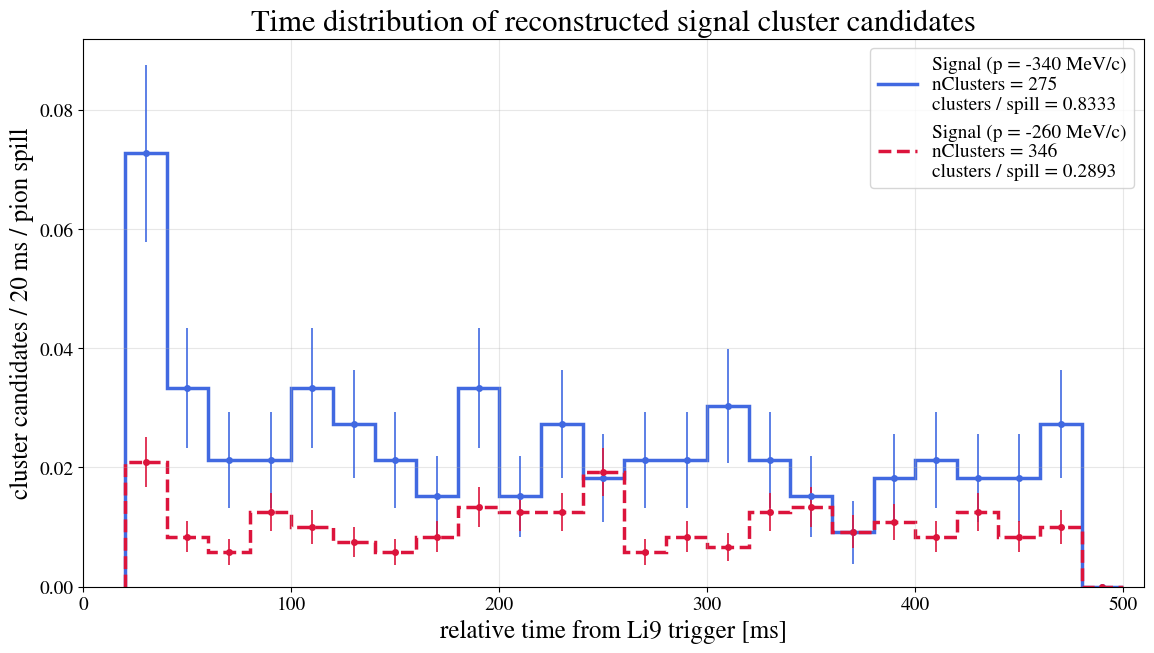

In [39]:
# ------------------------------------------------------------
# Time distribution (Signal) - FV_1
# ------------------------------------------------------------

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)

time_column = "t_window_start_rel_ns"

# Extraer los DataFrames de Signal despues de FV únicamente para FV_1
df_340_sig_comb = combined["FV_1"]["-340 MeV/c"]["signal"]["after"]
df_260_sig_comb = combined["FV_1"]["-260 MeV/c"]["signal"]["after"]

plt.figure(figsize=(12, 7))


def plot_sample(df, pion_spills, color, linestyle, label):

    if df.empty:
        return

    # ns -> ms
    time_ms = df[time_column] / 1e6

    counts, edges = np.histogram(
        time_ms,
        bins=bins
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    counts_scaled = counts / pion_spills
    errors_scaled = np.sqrt(counts) / pion_spills

    plt.stairs(
        counts_scaled,
        edges,
        color=color,
        linestyle=linestyle,
        linewidth=2.5,
        label=(
            f"{label}\n"
            f"nClusters = {len(df)}\n"
            f"clusters / spill = "
            f"{len(df)/pion_spills:.4f}"
        ),
    )

    plt.errorbar(
        centers,
        counts_scaled,
        yerr=errors_scaled,
        fmt="o",
        color=color,
        markersize=4,
        elinewidth=1.2,
        capsize=0,
        ls="none",
    )


plot_sample(
    df_340_sig_comb,
    spills_340_pion,
    color="royalblue",
    linestyle="-",
    label="Signal (p = -340 MeV/c)",
)

plot_sample(
    df_260_sig_comb,
    spills_260_pion,
    color="crimson",
    linestyle="--",
    label="Signal (p = -260 MeV/c)",
)

plt.xlabel("relative time from Li9 trigger [ms]", fontsize=18)

plt.ylabel(
    f"cluster candidates / {bin_width} ms / pion spill",
    fontsize=18,
)

plt.title(
    "Time distribution of reconstructed signal cluster candidates",
    fontsize=22,
)

plt.xlim(0, 510)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)

plt.legend(fontsize=14)

plt.tight_layout()

plt.show()

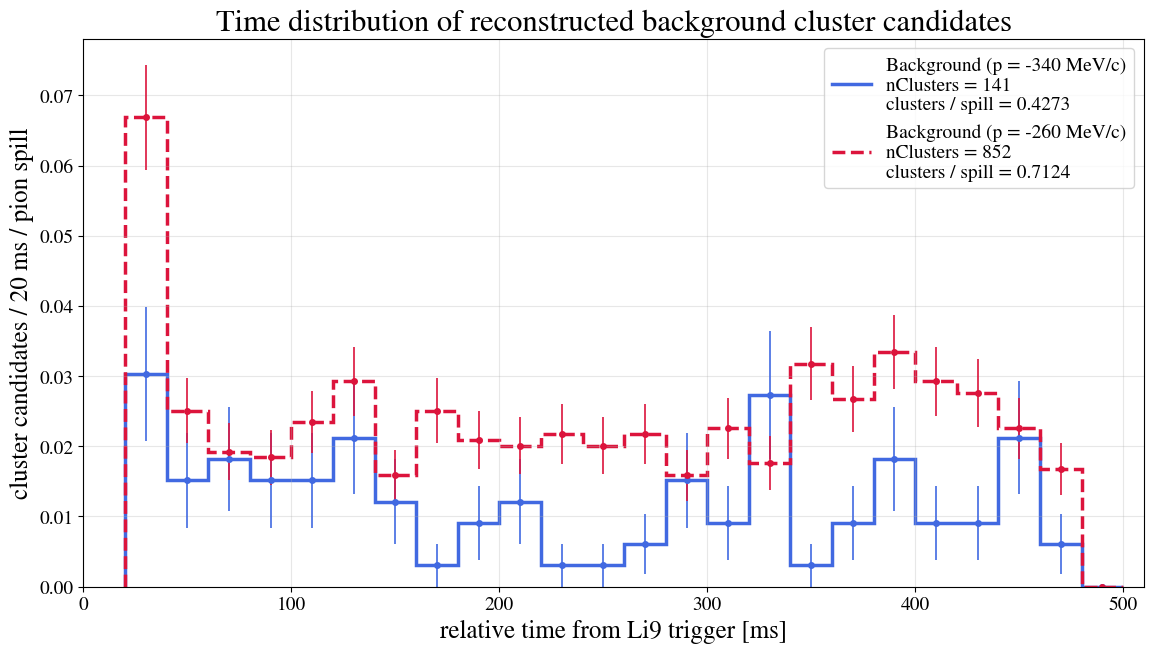

In [40]:
# ------------------------------------------------------------
# Time distribution (Background) - FV_1
# ------------------------------------------------------------

# Extraer los DataFrames de Background después de FV únicamente para FV_1
df_340_bkg_comb = combined["FV_1"]["-340 MeV/c"]["background (bkg)"]["after"]
df_260_bkg_comb = combined["FV_1"]["-260 MeV/c"]["background (bkg)"]["after"]

plt.figure(figsize=(12, 7))

plot_sample(
    df_340_bkg_comb,
    spills_340_pion,
    color="royalblue",
    linestyle="-",
    label="Background (p = -340 MeV/c)",
)

plot_sample(
    df_260_bkg_comb,
    spills_260_pion,
    color="crimson",
    linestyle="--",
    label="Background (p = -260 MeV/c)",
)

plt.xlabel(
    "relative time from Li9 trigger [ms]",
    fontsize=18,
)

plt.ylabel(
    f"cluster candidates / {bin_width} ms / pion spill",
    fontsize=18,
)

plt.title(
    "Time distribution of reconstructed background cluster candidates",
    fontsize=22,
)

plt.xlim(0, 510)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)

plt.legend(fontsize=14)

plt.tight_layout()

plt.show()

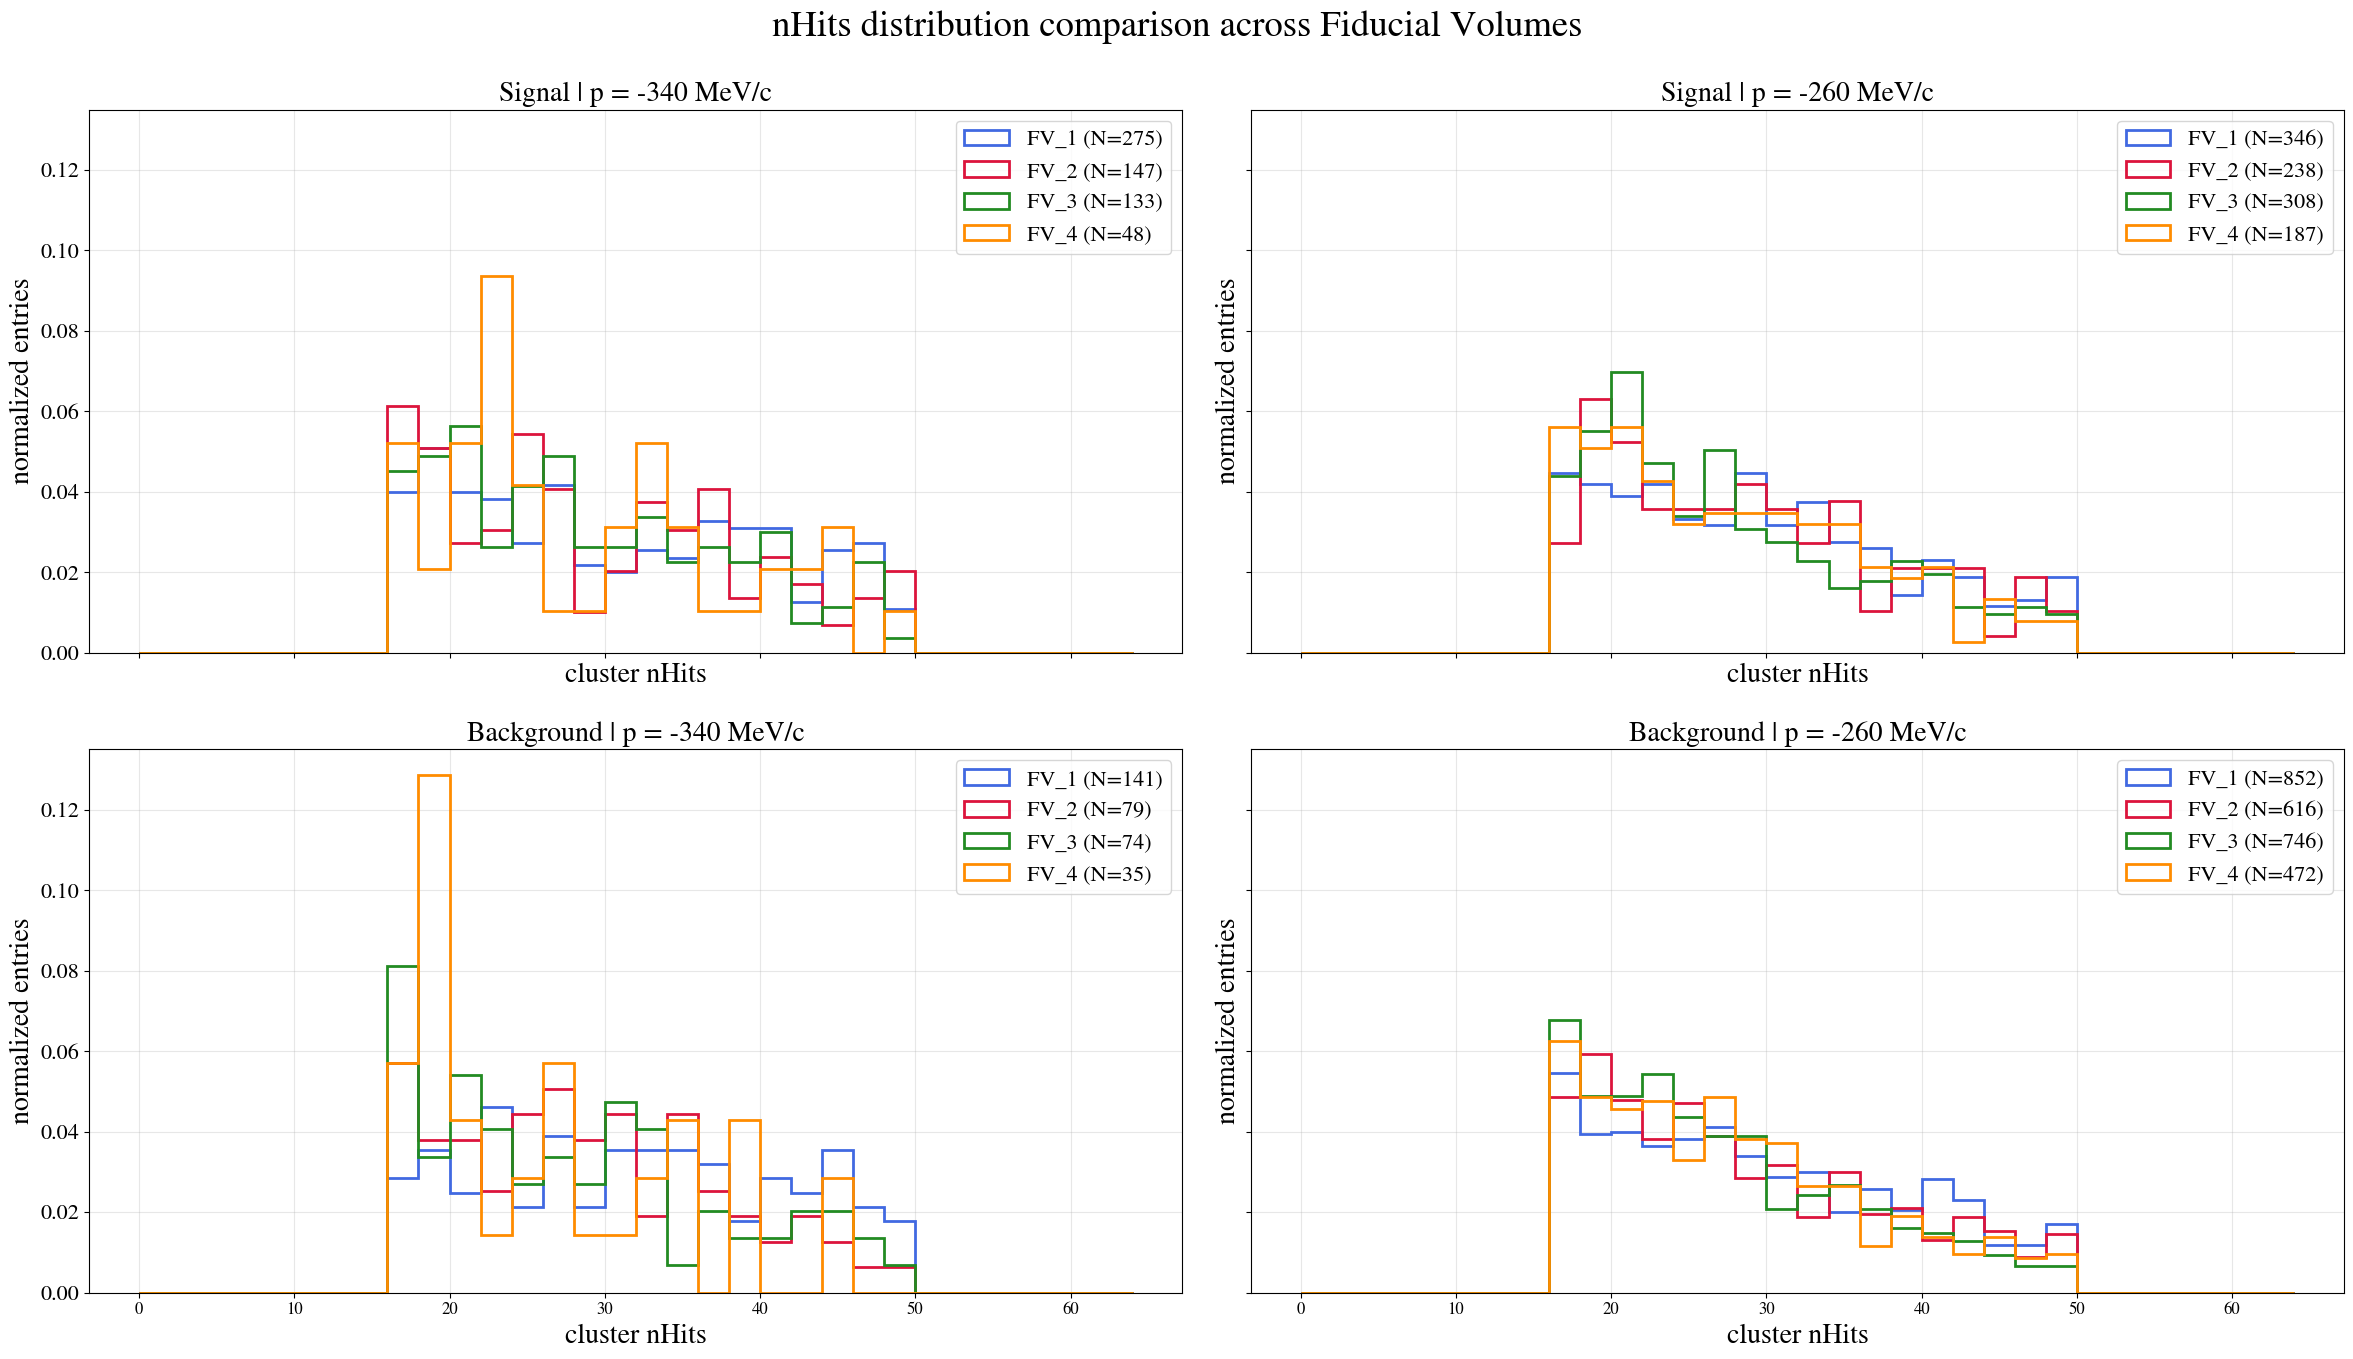

In [41]:
# ==============================================================================
# nHits distribution across all 4 Fiducial Volumes (Signal & Background)
# ==============================================================================

fig, axs = plt.subplots(2, 2, figsize=(24, 14), sharex=True, sharey=True)

bins_hits = np.arange(0, 65, 2)
fv_tags = ["FV_1", "FV_2", "FV_3", "FV_4"]

# Colores y estilos para diferenciar cada FV claramente en la superposición
colors_fv = {
    "FV_1": "royalblue",
    "FV_2": "crimson",
    "FV_3": "forestgreen",
    "FV_4": "darkorange",
}

plot_matrix = [
    {
        "ax": axs[0, 0],
        "title": "Signal | p = -340 MeV/c",
        "beam": "-340 MeV/c",
        "mode": "signal",
    },
    {
        "ax": axs[0, 1],
        "title": "Signal | p = -260 MeV/c",
        "beam": "-260 MeV/c",
        "mode": "signal",
    },
    {
        "ax": axs[1, 0],
        "title": "Background | p = -340 MeV/c",
        "beam": "-340 MeV/c",
        "mode": "background (bkg)",
    },
    {
        "ax": axs[1, 1],
        "title": "Background | p = -260 MeV/c",
        "beam": "-260 MeV/c",
        "mode": "background (bkg)",
    },
]

for cfg in plot_matrix:

    ax = cfg["ax"]
    ax.set_title(cfg["title"])

    for fv in fv_tags:

        df_after = combined[fv][cfg["beam"]][cfg["mode"]]["after"]

        if not df_after.empty and "nHits" in df_after.columns:

            ax.hist(
                df_after["nHits"],
                bins=bins_hits,
                density=True,
                histtype="step",
                linewidth=2,
                color=colors_fv[fv],
                label=f"{fv} (N={len(df_after)})",
            )

    ax.set_xlabel("cluster nHits")
    ax.set_ylabel("normalized entries")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", frameon=True)

plt.suptitle("nHits distribution comparison across Fiducial Volumes")
plt.tight_layout()
plt.show()

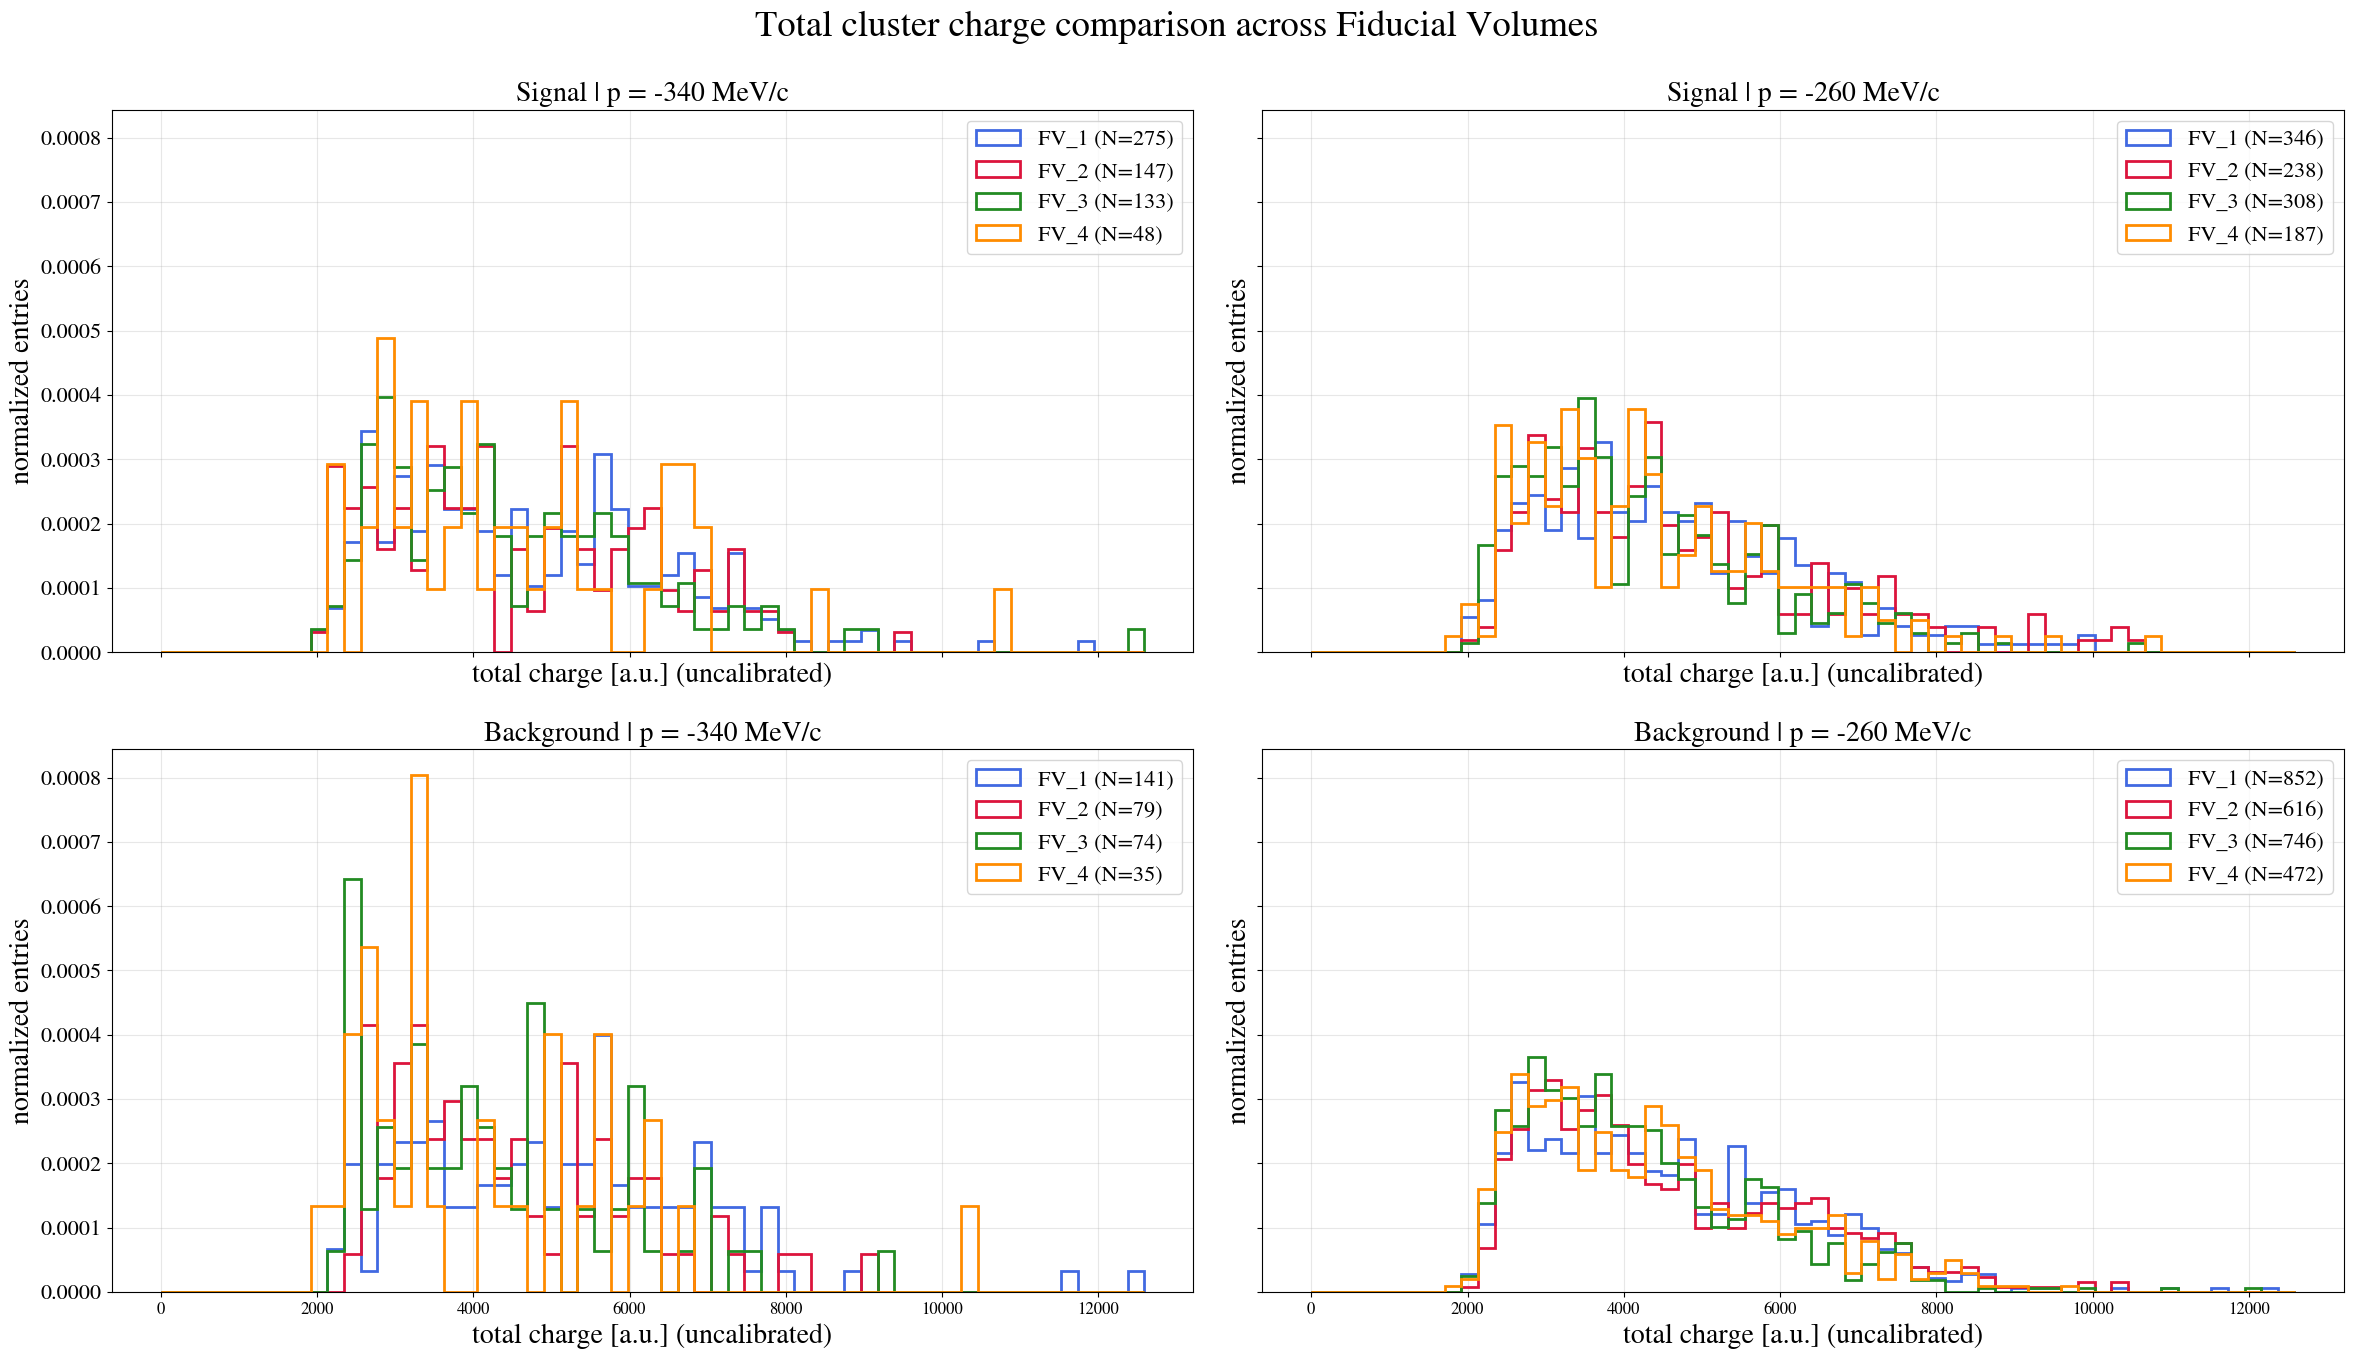

In [42]:
# ==============================================================================
# Total Charge distribution across all 4 Fiducial Volumes (Signal & Background)
# ==============================================================================

# --------------------------------------------------------------------------
# Cálculo preliminar de carga total e intervalo máximo global de bins
# --------------------------------------------------------------------------
all_charges = []

for fv in fv_tags:
    for beam in ["-340 MeV/c", "-260 MeV/c"]:
        for mode in ["signal", "background (bkg)"]:
            df = combined[fv][beam][mode]["after"]
            if not df.empty and "hit_charges" in df.columns:
                df["total_charge_adc"] = df["hit_charges"].apply(
                    lambda x: np.sum(x) if len(x) > 0 else 0
                )
                all_charges.extend(df["total_charge_adc"].dropna().tolist())

qmax = np.percentile(all_charges, 99.5) if len(all_charges) > 0 else 1000
bins_charge = np.linspace(0, qmax, 60)

# --------------------------------------------------------------------------
# Plot 2x2
# --------------------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(24, 14), sharex=True, sharey=True)

plot_matrix_q = [
    {
        "ax": axs[0, 0],
        "title": "Signal | p = -340 MeV/c",
        "beam": "-340 MeV/c",
        "mode": "signal",
    },
    {
        "ax": axs[0, 1],
        "title": "Signal | p = -260 MeV/c",
        "beam": "-260 MeV/c",
        "mode": "signal",
    },
    {
        "ax": axs[1, 0],
        "title": "Background | p = -340 MeV/c",
        "beam": "-340 MeV/c",
        "mode": "background (bkg)",
    },
    {
        "ax": axs[1, 1],
        "title": "Background | p = -260 MeV/c",
        "beam": "-260 MeV/c",
        "mode": "background (bkg)",
    },
]

for cfg in plot_matrix_q:

    ax = cfg["ax"]
    ax.set_title(cfg["title"])

    for fv in fv_tags:

        df_after = combined[fv][cfg["beam"]][cfg["mode"]]["after"]

        if not df_after.empty and "total_charge_adc" in df_after.columns:

            ax.hist(
                df_after["total_charge_adc"],
                bins=bins_charge,
                density=True,
                histtype="step",
                linewidth=2,
                color=colors_fv[fv],
                label=f"{fv} (N={len(df_after)})",
            )

    ax.set_xlabel("total charge [a.u.] (uncalibrated)")
    ax.set_ylabel("normalized entries")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", frameon=True)

plt.suptitle("Total cluster charge comparison across Fiducial Volumes")
plt.tight_layout()
plt.show()

## Gadolinium

In [43]:
import os
import numpy as np
import pandas as pd
from glob import glob

# ==========================================================
# Configuration: Gadolinium runs (-270 MeV/c)
# ==========================================================
gd_runs = [2407, 2408, 2409, 2432, 2434, 2438]

base_dir = "/scratch/elena/9Li/results"
beam_gd = "-270 MeV/c (Gd)"

# ==========================================================
# Detector geometry
# ==========================================================
R = 153.7963      # cm
H = 271.4235     # cm


# ==========================================================
# Quality selection (Refine / Final only)
# ==========================================================
def select_good_vertices(df):

    if df.empty:
        return df

    required = {"v_x_fine", "v_y_fine", "v_z_fine"}

    if not required.issubset(df.columns):
        raise ValueError(
            "Missing refined vertex coordinates "
            "(v_x_fine, v_y_fine, v_z_fine)."
        )

    x = df["v_x_fine"]
    y = df["v_y_fine"]
    z = df["v_z_fine"]

    mask = (
        df["fit_success"]
        & (df["chi2_ndof"] < 3)
        & (x**2 + z**2 <= R**2)
        & (np.abs(y) <= H / 2)
    )

    return df.loc[mask].copy()


# ==========================================================
# Containers
# ==========================================================
gd_data_fv1 = {
    "signal": {
        "stage1": [],
        "multilat": [],
        "before": [],
        "after": [],
    },
    "background (bkg)": {
        "stage1": [],
        "multilat": [],
        "before": [],
        "after": [],
    },
}


# ==========================================================
# Read all runs
# ==========================================================
for run in gd_runs:

    processed_dir = os.path.join(base_dir, f"run{run}", "processed")
    fv_dir = os.path.join(processed_dir, "FV_1")

    for mode in ["signal", "background (bkg)"]:

        is_bkg = (mode == "background (bkg)")

        if is_bkg:
            stage1_pattern   = "Li9_clusters_chunk_*_BKG.pkl"
            multilat_pattern = "Li9_clusters_chunk_*_BKG_multilat.pkl"
            refine_pattern   = "Refine_Li9_clusters_chunk_*_BKG.pkl"
            final_name       = f"Final_FV_Li9_clusters_run{run}_BKG.pkl"
        else:
            stage1_pattern   = "Li9_clusters_chunk_*.pkl"
            multilat_pattern = "Li9_clusters_chunk_*_multilat.pkl"
            refine_pattern   = "Refine_Li9_clusters_chunk_*.pkl"
            final_name       = f"Final_FV_Li9_clusters_run{run}.pkl"

        # =====================================================
        # Stage 1 : Initial Li9 candidates
        # =====================================================
        stage1_files = sorted(
            glob(os.path.join(processed_dir, stage1_pattern))
        )

        if stage1_files:

            df_stage1 = pd.concat(
                [pd.read_pickle(f) for f in stage1_files],
                ignore_index=True,
            )

            gd_data_fv1[mode]["stage1"].append(df_stage1)

        # =====================================================
        # Stage 2 : Multilateration
        # =====================================================
        multilat_files = sorted(
            glob(os.path.join(processed_dir, multilat_pattern))
        )

        if multilat_files:

            df_multilat = pd.concat(
                [pd.read_pickle(f) for f in multilat_files],
                ignore_index=True,
            )

            gd_data_fv1[mode]["multilat"].append(df_multilat)

        # =====================================================
        # Stage 3 : Refined vertices (Before FV)
        # =====================================================
        refine_files = sorted(
            glob(os.path.join(processed_dir, refine_pattern))
        )

        if refine_files:

            df_before = pd.concat(
                [pd.read_pickle(f) for f in refine_files],
                ignore_index=True,
            )

            df_before = select_good_vertices(df_before)

            gd_data_fv1[mode]["before"].append(df_before)

        # =====================================================
        # Stage 4 : Final FV selection (After FV)
        # =====================================================
        final_file = os.path.join(fv_dir, final_name)

        if os.path.exists(final_file):

            df_after = pd.read_pickle(final_file)

            df_after = select_good_vertices(df_after)

            gd_data_fv1[mode]["after"].append(df_after)

        else:

            print(f"WARNING: Missing {final_file}")


# ==========================================================
# Concatenate all runs
# ==========================================================
gd_combined_fv1 = {}

for mode in ["signal", "background (bkg)"]:

    gd_combined_fv1[mode] = {}

    for stage in ["stage1", "multilat", "before", "after"]:

        stage_list = gd_data_fv1[mode][stage]

        gd_combined_fv1[mode][stage] = (
            pd.concat(stage_list, ignore_index=True)
            if stage_list
            else pd.DataFrame()
        )


# ==========================================================
# Print summary
# ==========================================================
print("=" * 90)
print(f"GADOLINIUM DATASET ({beam_gd})")
print("=" * 90)

for mode in ["signal", "background (bkg)"]:

    print(f"\n{mode.upper()}")

    print(f"Stage 1    : {len(gd_combined_fv1[mode]['stage1']):8,d}")
    print(f"Multilat   : {len(gd_combined_fv1[mode]['multilat']):8,d}")
    print(f"Before FV  : {len(gd_combined_fv1[mode]['before']):8,d}")
    print(f"After FV_1 : {len(gd_combined_fv1[mode]['after']):8,d}")

    n_before = len(gd_combined_fv1[mode]["before"])
    n_after  = len(gd_combined_fv1[mode]["after"])

    efficiency = 100 * n_after / n_before if n_before else 0.0

    print(f"FV_1 efficiency: {efficiency:.2f}%")

GADOLINIUM DATASET (-270 MeV/c (Gd))

SIGNAL
Stage 1    : 3,636,309
Multilat   : 1,781,100
Before FV  :  104,082
After FV_1 :      180
FV_1 efficiency: 0.17%

BACKGROUND (BKG)
Stage 1    : 1,616,252
Multilat   : 1,616,252
Before FV  :   94,328
After FV_1 :    2,002
FV_1 efficiency: 2.12%


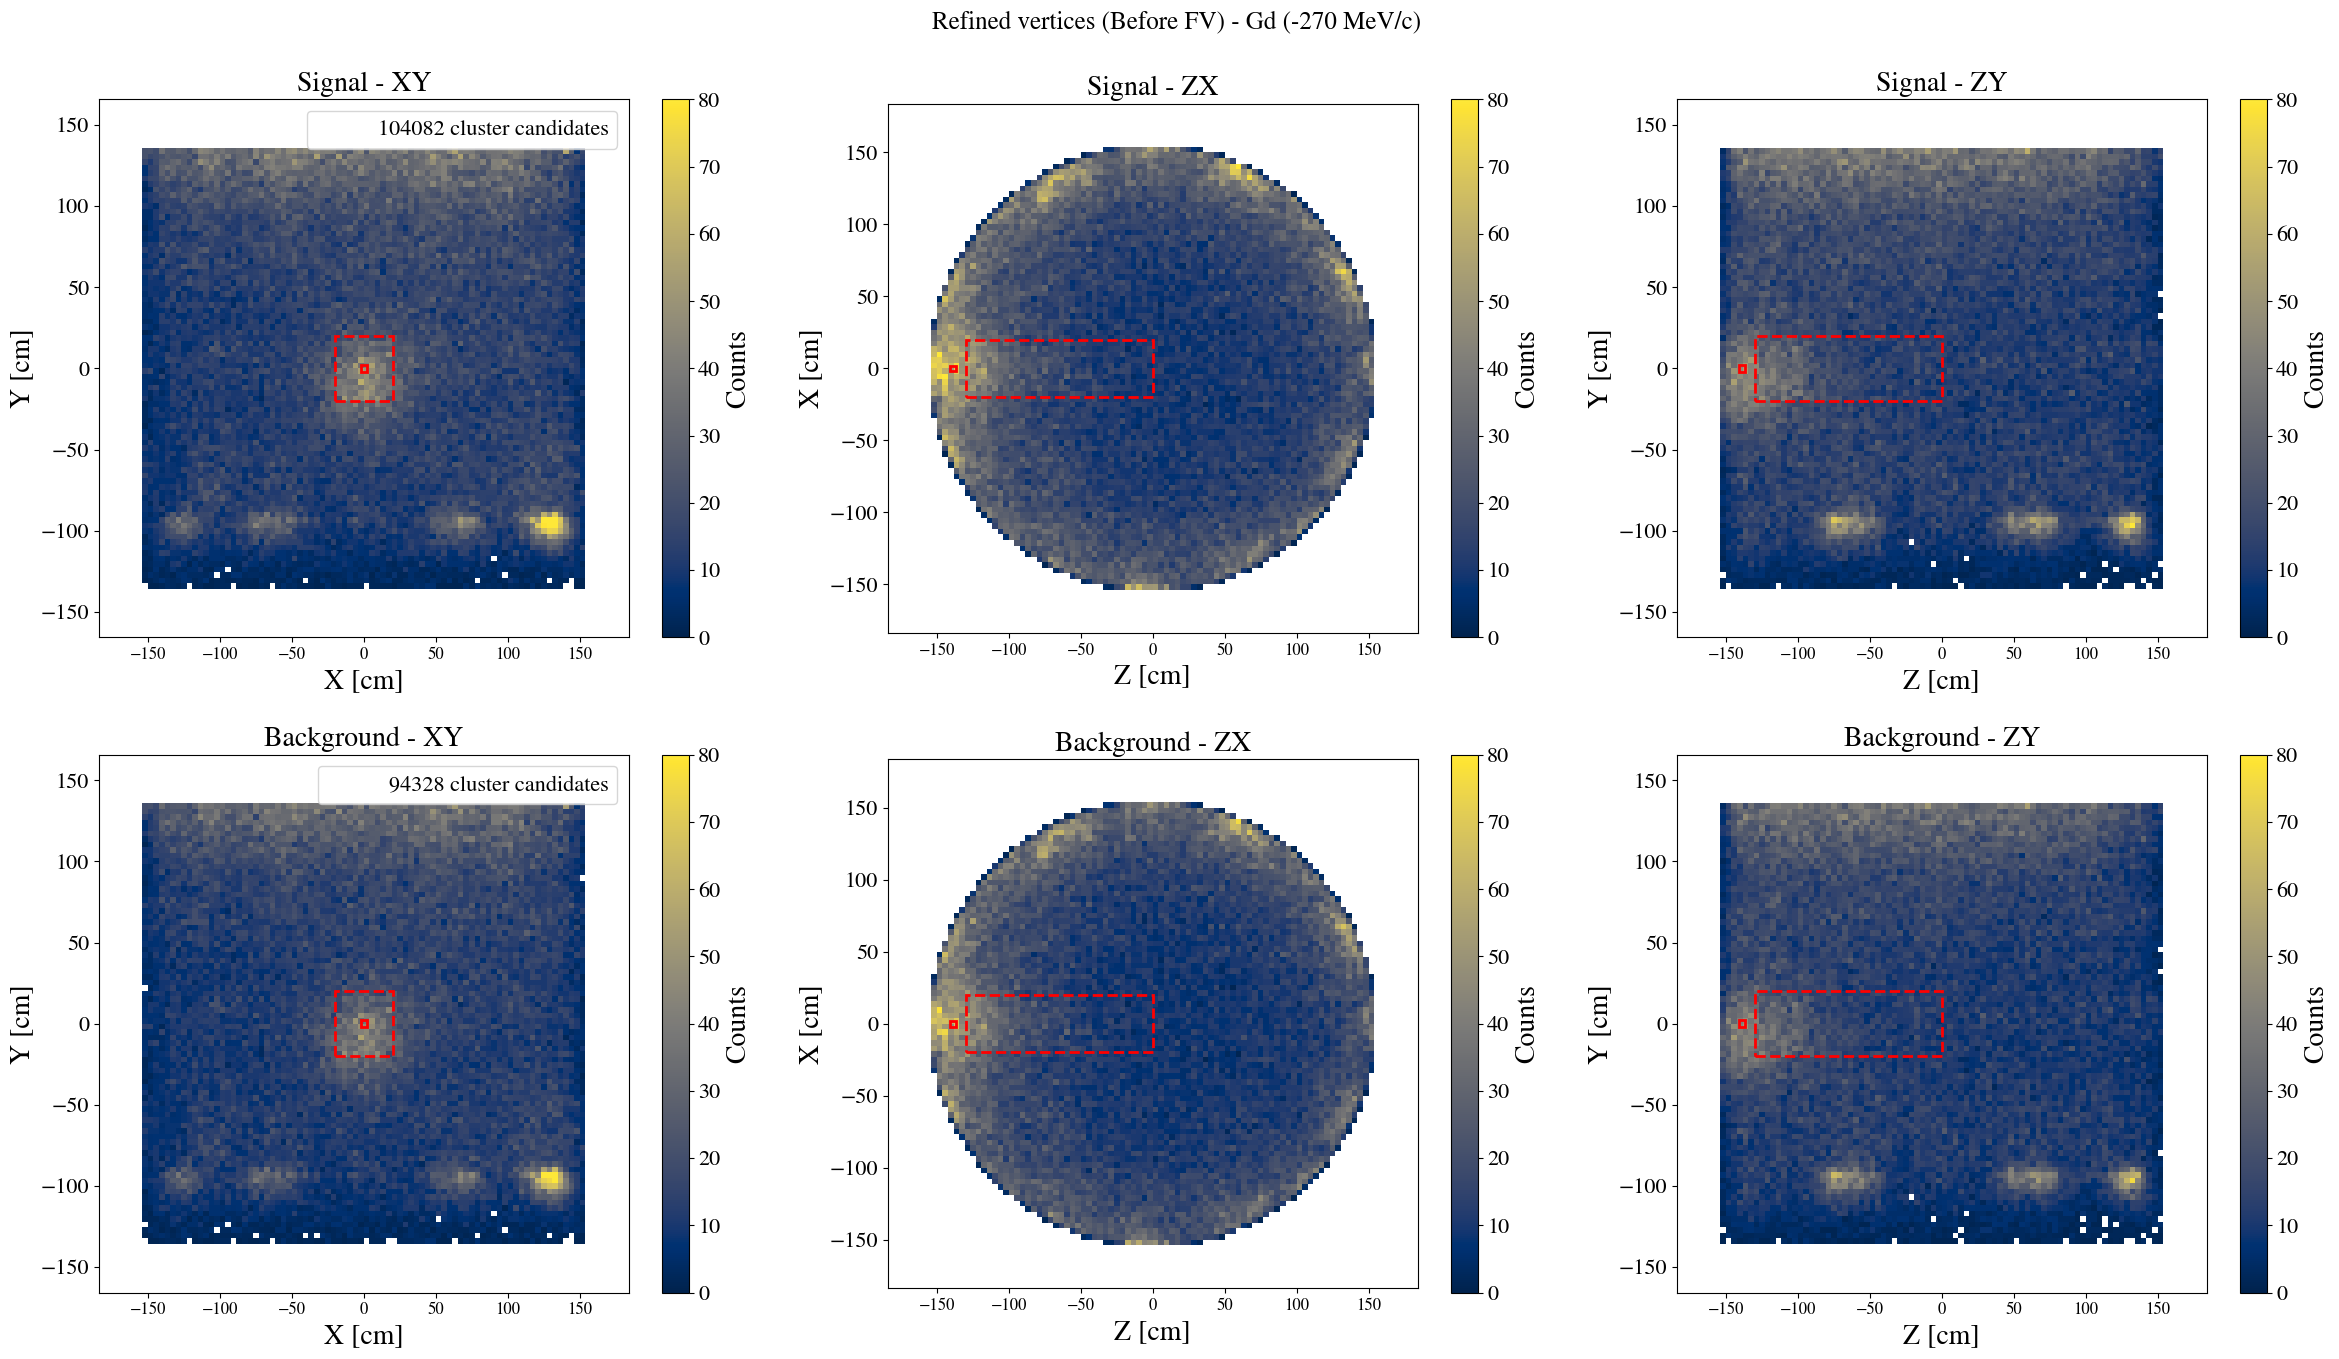

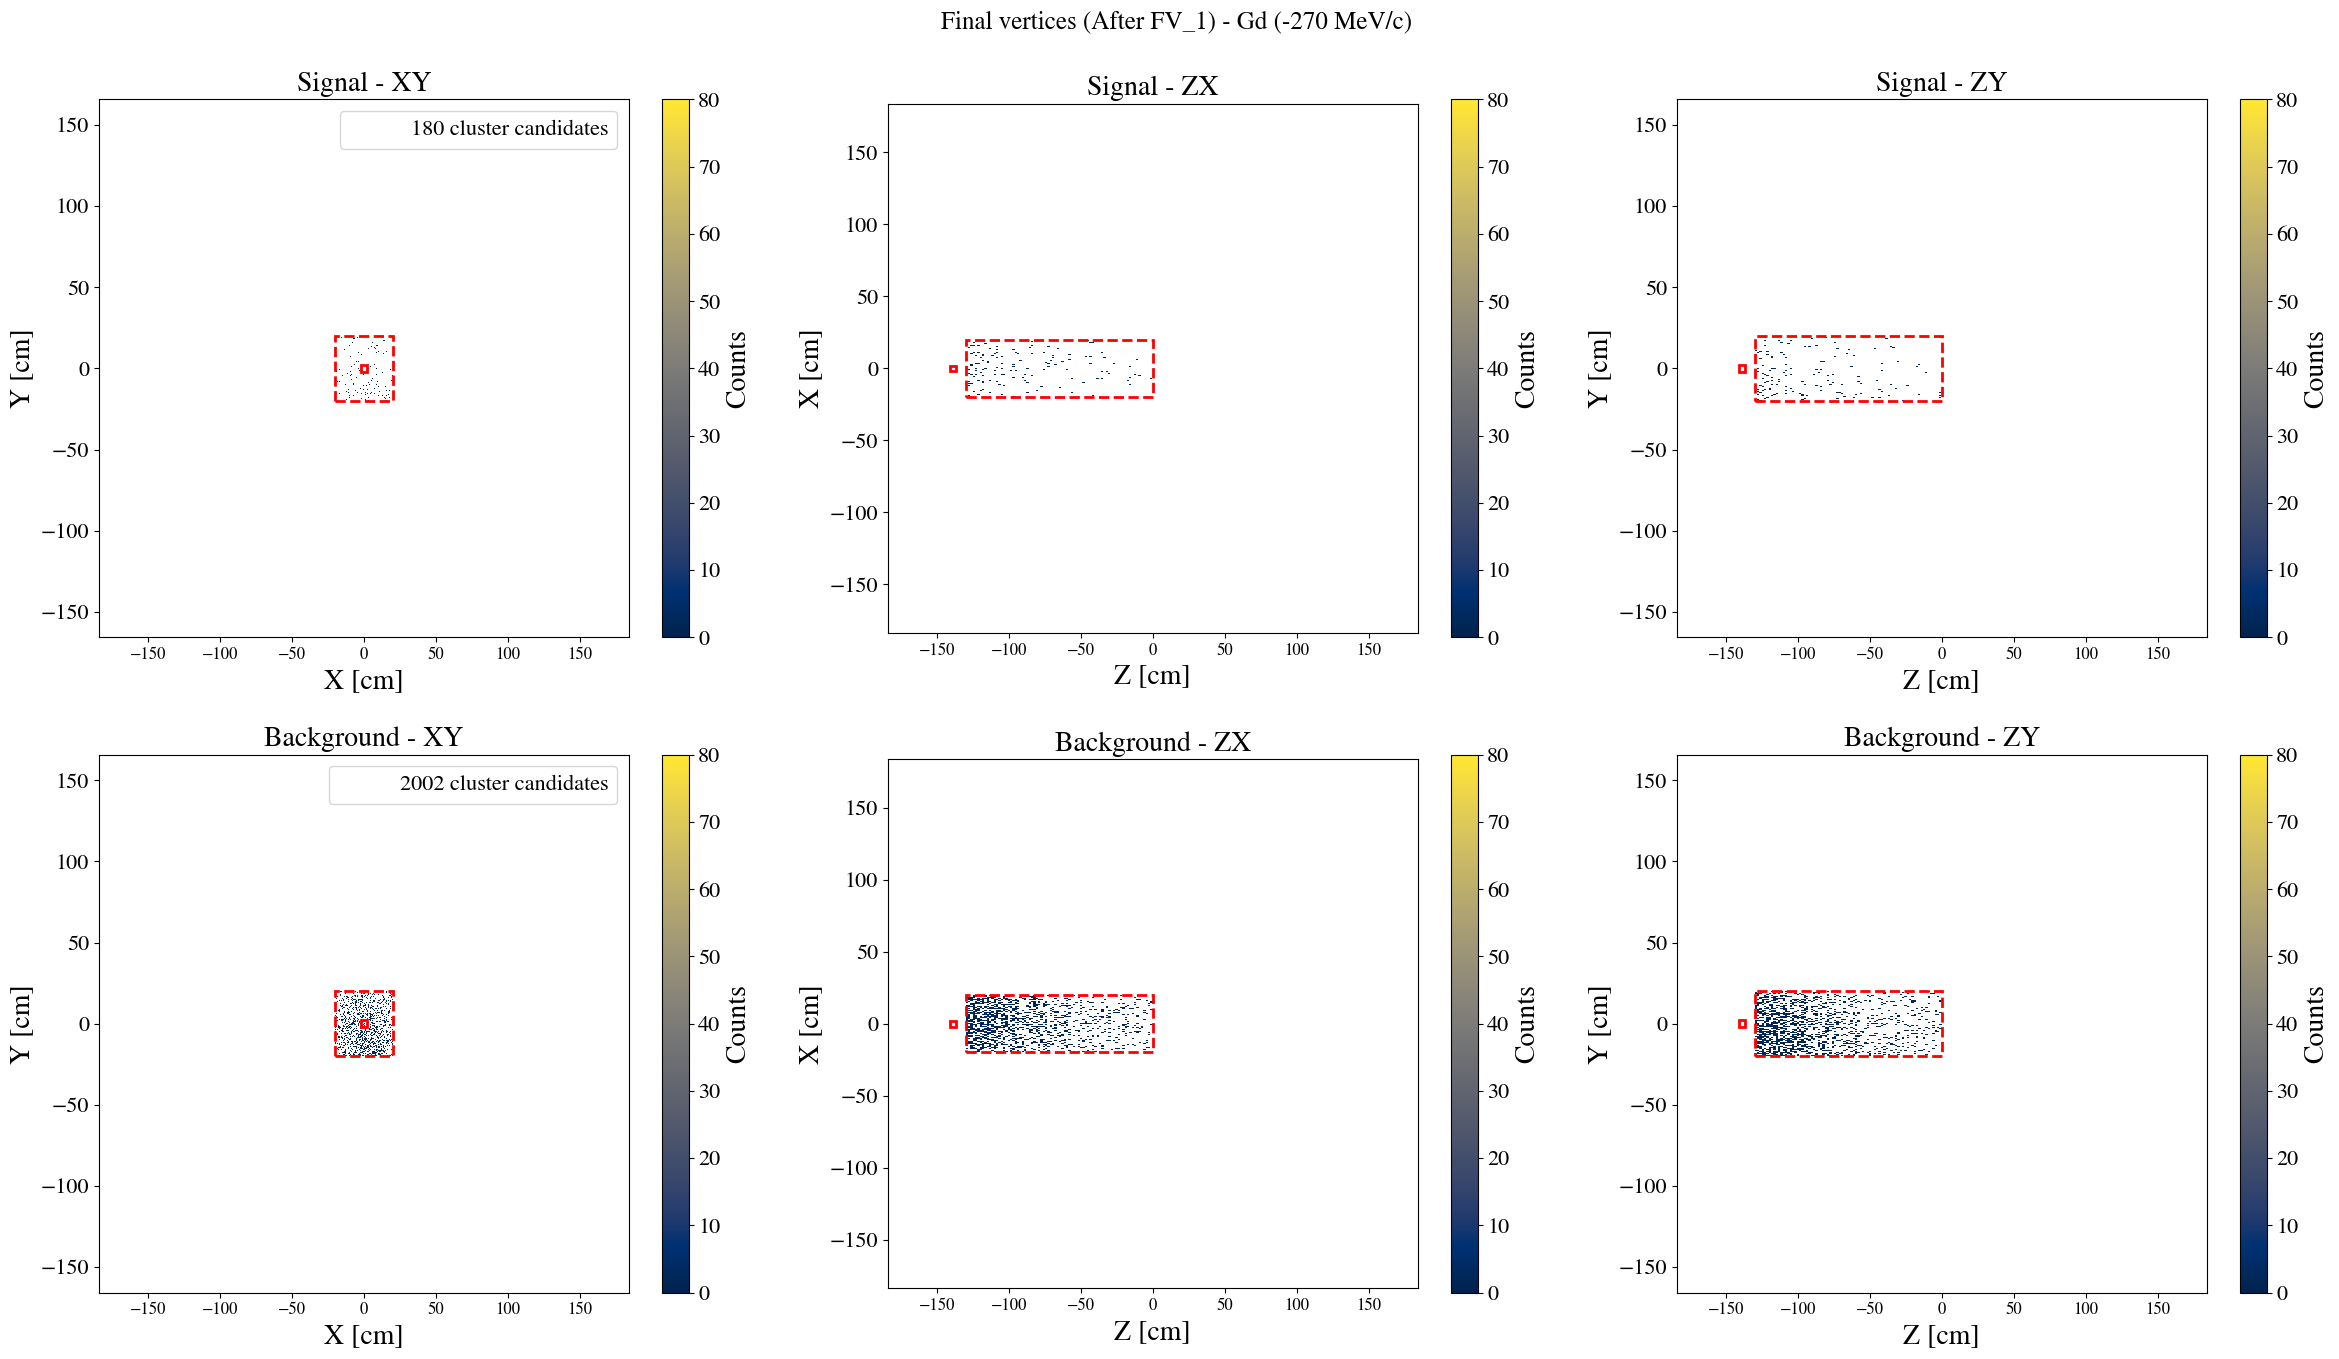

In [44]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import numpy as np

# =====================================================
# Fiducial Volume limits
# =====================================================
FV_LIMITS = {
    "FV_1": {
        "x": (-20.0, 20.0),
        "y": (-20.0, 20.0),
        "z": (-130.0, 0.0),
    }
}

# =====================================================
# Plot Refine / Final vertex maps
# (uses ONLY v_x_fine, v_y_fine, v_z_fine)
# =====================================================
def plot_vertex_maps_fv_gd(df_sig, df_bkg, stage_name, fv_tag="FV_1"):

    required = {"v_x_fine", "v_y_fine", "v_z_fine"}

    for name, df in [("Signal", df_sig), ("Background", df_bkg)]:
        if not df.empty and not required.issubset(df.columns):
            raise ValueError(
                f"{name} dataframe does not contain "
                "v_x_fine, v_y_fine and v_z_fine."
            )

    xcol = "v_x_fine"
    ycol = "v_y_fine"
    zcol = "v_z_fine"

    x_lims = FV_LIMITS[fv_tag]["x"]
    y_lims = FV_LIMITS[fv_tag]["y"]
    z_lims = FV_LIMITS[fv_tag]["z"]

    beam_pipe = [0.0, 0.0, -138.7963]
    beam_halfwidth = 2.0

    bins = 80
    vmax = 80

    R = 153.7963
    H = 271.4235

    fig, axs = plt.subplots(2, 3, figsize=(24, 14))

    datasets = [
        ("Signal", df_sig),
        ("Background", df_bkg),
    ]

    for row, (label, df) in enumerate(datasets):

        if df.empty:
            axs[row,0].set_visible(False)
            axs[row,1].set_visible(False)
            axs[row,2].set_visible(False)
            continue

        n_clusters = len(df)

        # -------------------------
        # XY
        # -------------------------
        im = axs[row,0].hist2d(
            df[xcol],
            df[ycol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row,0].set_xlim(-R-30, R+30)
        axs[row,0].set_ylim(-H/2-30, H/2+30)

        axs[row,0].add_patch(
            Rectangle(
                (beam_pipe[0]-beam_halfwidth,
                 beam_pipe[1]-beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        axs[row,0].add_patch(
            Rectangle(
                (x_lims[0], y_lims[0]),
                x_lims[1]-x_lims[0],
                y_lims[1]-y_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row,0].set_title(f"{label} - XY")
        axs[row,0].set_xlabel("X [cm]")
        axs[row,0].set_ylabel("Y [cm]")

        dummy = Line2D(
            [],
            [],
            linestyle="",
            label=f"{n_clusters:} cluster candidates",
        )

        axs[row,0].legend(handles=[dummy], loc="upper right")

        plt.colorbar(im[3], ax=axs[row,0], label="Counts")

        # -------------------------
        # ZX
        # -------------------------
        im = axs[row,1].hist2d(
            df[zcol],
            df[xcol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row,1].set_xlim(-R-30, R+30)
        axs[row,1].set_ylim(-R-30, R+30)
        axs[row,1].set_aspect("equal")

        axs[row,1].add_patch(
            Rectangle(
                (beam_pipe[2]-beam_halfwidth,
                 beam_pipe[0]-beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        axs[row,1].add_patch(
            Rectangle(
                (z_lims[0], x_lims[0]),
                z_lims[1]-z_lims[0],
                x_lims[1]-x_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row,1].set_title(f"{label} - ZX")
        axs[row,1].set_xlabel("Z [cm]")
        axs[row,1].set_ylabel("X [cm]")

        plt.colorbar(im[3], ax=axs[row,1], label="Counts")

        # -------------------------
        # ZY
        # -------------------------
        im = axs[row,2].hist2d(
            df[zcol],
            df[ycol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row,2].set_xlim(-R-30, R+30)
        axs[row,2].set_ylim(-H/2-30, H/2+30)

        axs[row,2].add_patch(
            Rectangle(
                (beam_pipe[2]-beam_halfwidth,
                 beam_pipe[1]-beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        axs[row,2].add_patch(
            Rectangle(
                (z_lims[0], y_lims[0]),
                z_lims[1]-z_lims[0],
                y_lims[1]-y_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row,2].set_title(f"{label} - ZY")
        axs[row,2].set_xlabel("Z [cm]")
        axs[row,2].set_ylabel("Y [cm]")

        plt.colorbar(im[3], ax=axs[row,2], label="Counts")

    plt.suptitle(stage_name, fontsize=18)
    plt.tight_layout()
    plt.show()


# =====================================================
# Plot Refine (Before FV)
# =====================================================
plot_vertex_maps_fv_gd(
    gd_combined_fv1["signal"]["before"],
    gd_combined_fv1["background (bkg)"]["before"],
    "Refined vertices (Before FV) - Gd (-270 MeV/c)",
)

# =====================================================
# Plot Final (After FV_1)
# =====================================================
plot_vertex_maps_fv_gd(
    gd_combined_fv1["signal"]["after"],
    gd_combined_fv1["background (bkg)"]["after"],
    "Final vertices (After FV_1) - Gd (-270 MeV/c)",
)

--> [OK] Total pion spills for Gadolinio (-270 MeV/c): 10000


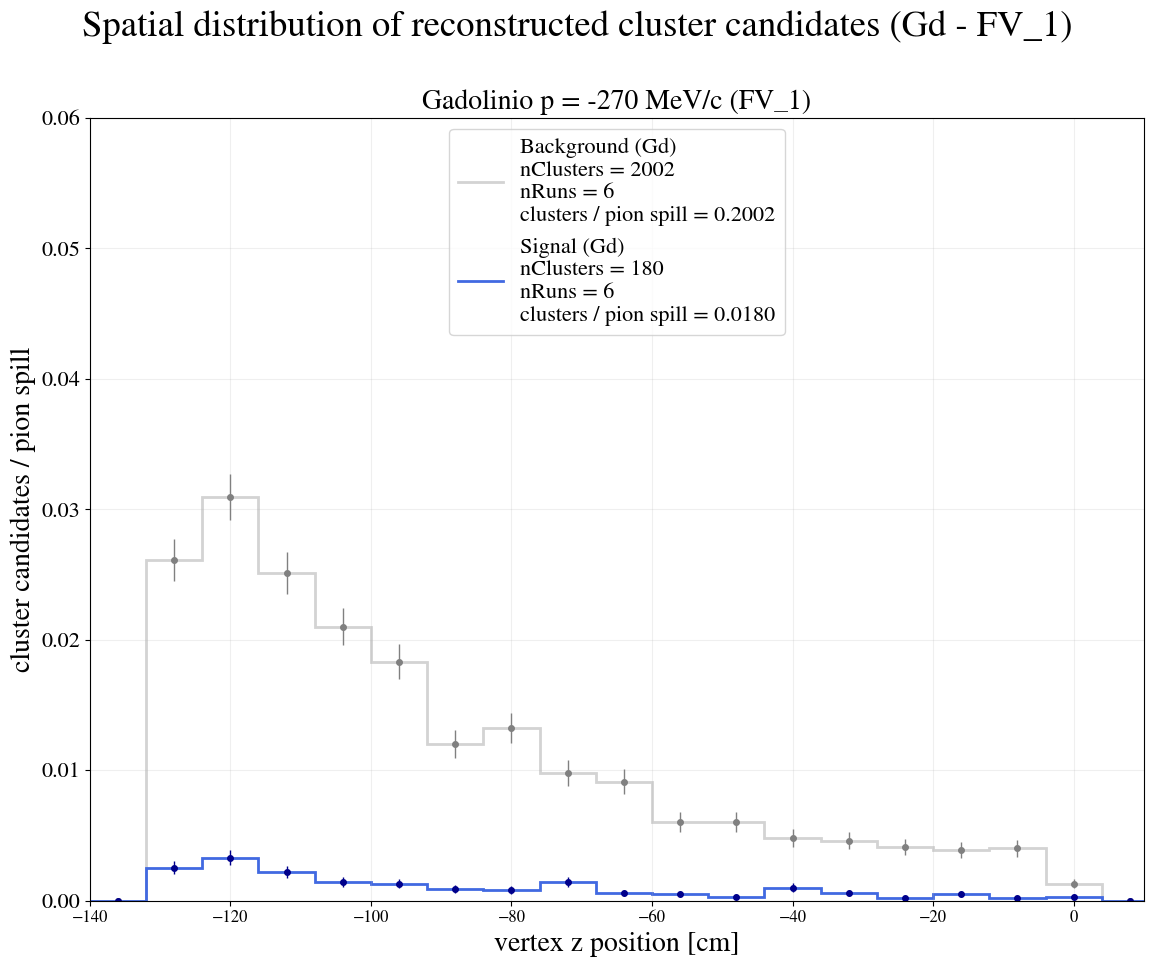

In [45]:
# ==============================================================================
# Spatial distribution of final FV candidates for Gd (FV_1)
# ==============================================================================

gd_runs = [2407, 2408, 2409, 2432, 2434, 2438]

# Si tienes un número específico de spills para Gd en tu master table, puedes extraerlo aquí. 
# De forma predeterminada, intentamos sumarlos del master table si existen, o usamos un valor de respaldo.
master_table_path = "/scratch/elena/9Li/results/isotopes_output/master_table_all_runs.csv"

spills_gd_pion = 10000  # Valor por defecto por seguridad; ajústalo si lo lees de la tabla o de tus logs.
if os.path.exists(master_table_path):
    df_master = pd.read_csv(master_table_path)
    # Filtramos si los runs de Gd están en la master table
    matched_spills = df_master[df_master["Run"].isin(gd_runs)]["N spills with pions"].sum()
    if matched_spills > 0:
        spills_gd_pion = matched_spills

print(f"--> [OK] Total pion spills for Gadolinio (-270 MeV/c): {spills_gd_pion}")

# --------------------------------------------------------------------------
# Plot configuration
# --------------------------------------------------------------------------
plt.rcParams["figure.figsize"] = [12, 10]

bins_z = np.arange(-140, 140, 8)
z_column = "v_z_fine"
fv_tag = "FV_1"

df_gd_sig_comb = gd_combined_fv1["signal"]["after"]
df_gd_bkg_comb = gd_combined_fv1["background (bkg)"]["after"]

fig, ax = plt.subplots(1, 1, sharey=False)

title_str = f"Gadolinio p = -270 MeV/c ({fv_tag})"
ax.set_title(title_str)

def plot_sample(df_plot, sample_label, hist_color, marker_color):
    if df_plot.empty or z_column not in df_plot.columns:
        return False

    counts, bin_edges = np.histogram(
        df_plot[z_column],
        bins=bins_z
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    counts_scaled = counts / spills_gd_pion
    errors_scaled = np.sqrt(counts) / spills_gd_pion

    label = (
        f"{sample_label}\n"
        f"nClusters = {len(df_plot)}\n"
        f"nRuns = {len(gd_runs)}\n"
        f"clusters / pion spill = {len(df_plot)/spills_gd_pion:.4f}"
    )

    ax.stairs(
        counts_scaled,
        bin_edges,
        color=hist_color,
        linewidth=2,
        label=label,
    )

    ax.errorbar(
        bin_centers,
        counts_scaled,
        yerr=errors_scaled,
        fmt="o",
        color=marker_color,
        markersize=4,
        capsize=0,
        elinewidth=1,
        ls="none",
    )

    return True

has_bkg = plot_sample(
    df_gd_bkg_comb,
    "Background (Gd)",
    "lightgray",
    "gray",
)

has_sig = plot_sample(
    df_gd_sig_comb,
    "Signal (Gd)",
    "royalblue",
    "darkblue",
)

if not has_sig and not has_bkg:
    ax.text(
        0.5,
        0.5,
        f"No selected candidates inside {fv_tag}",
        transform=ax.transAxes,
        ha="center",
    )

ax.set_xlabel("vertex z position [cm]")
ax.set_ylabel("cluster candidates / pion spill")
ax.grid(True, alpha=0.2)
ax.set_xlim(-140, 10)
ax.set_ylim(0, 0.06)
ax.legend(loc="upper center", frameon=True)

plt.suptitle(f"Spatial distribution of reconstructed cluster candidates (Gd - {fv_tag})")
plt.tight_layout()
plt.show()